# Evaluating Machine Learning Models

### A Complete Teaching Notebook — From Beginner to Expert

**Audience:** Data Science & AI students (undergraduate, postgraduate, and self-study)

**Libraries used:** NumPy · Pandas · Matplotlib · scikit-learn

**How to use this notebook**

1. Read the markdown explanations *before* running the code.
2. Run the code cells **top to bottom** — every code cell is self-contained where practical.
3. After every code cell, read the *"What did we learn?"* note and answer the *"What would this mean in a real-world application?"* question for yourself.

> ### ⭐ The one idea that matters above all others
>
> **Model evaluation is not about finding the model with the highest score.**
> It is about finding the model — and the decision threshold — that best satisfies
> the objectives and constraints of the real-world problem.

[Next: Table of Contents ➡](#toc)

In [1]:
# --- Setup: imports and reproducibility ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.datasets import make_classification, make_regression
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score,
                             mean_absolute_error, mean_squared_error, r2_score)

%matplotlib inline
import sklearn

np.random.seed(42)   # reproducibility: the same notebook run twice gives the same output

print("Imports OK")
print("NumPy:", np.__version__, "| Pandas:", pd.__version__, "| scikit-learn:", sklearn.__version__)

Imports OK
NumPy: 2.5.2 | Pandas: 3.0.5 | scikit-learn: 1.9.0


<a id="toc"></a>
## Table of Contents

**Foundations**

- [How the Two Notebooks Fit Together](#roadmap)
- [Learning Objectives](#objectives)
- [The Core Teaching Principle: Business Impact](#core)
- [1. Introduction to Model Evaluation](#sec1)
- [2. Classification vs Regression](#sec2)
- [3. Confusion Matrix](#sec3)
- [4. Accuracy](#sec4)
- [5. Precision](#sec5)
- [6. Recall / Sensitivity](#sec6)
- [7. Specificity](#sec7)

**Classification Metrics in Depth**

- [8. F1 Score](#sec8)
- [9. Precision–Recall Trade-off](#sec9)
- [10. ROC Curve](#sec10)
- [11. AUC](#sec11)
- [12. ROC-AUC vs Precision–Recall](#sec12)
- [13. Probability Calibration](#sec13)
- [14. Classification Report](#sec14)
- [15. Imbalanced Datasets](#sec15)
- [16. Multiclass Evaluation](#sec16)

**Model Selection & Regression**

- [17. Cross-Validation](#sec17)
- [18. Data Leakage](#sec18)
- [19. Time-Series Evaluation](#sec19)
- [20. Regression Metrics](#sec20)

**Putting It All Together**

- [21. End-to-End Case Study: Loan Default Prediction](#sec21)
- [22. Business Decision Case Study](#sec22)
- [23. Cost-Sensitive Evaluation: From Cost Matrix to Decision Rule](#sec23)
- [24. Choosing the Right Metric](#sec24)
- [25. Common Mistakes](#sec25)
- [26. Beginner vs Expert Summary](#sec26)
- [27. Final Cheat Sheet](#sec27)

**Practice & Assessment**

- [28. Practice Exercises](#sec28)
- [Exercise Solutions](#exercise-solutions)
- [29. Final Quiz](#sec29)
- [Quiz Answers](#quiz-answers)
- [Final Decision-Making Framework](#framework)

---
*Navigation: every section ends with [⬅ Previous] / [🏠 Table of Contents] / [Next ➡] links.*

<a id="roadmap"></a>
## How This Notebook Fits with the Simple Edition

This is the **full course** — 29 sections, from beginner to expert. A **Simple edition**
also exists: `ML_Model_Evaluation_Simple.ipynb` covers the same core curriculum in plain
language — 17 short sections, about 1–2 hours, no advanced topics and no widgets.

### Recommended reading paths

| Path | What you do | Best for |
|---|---|---|
| **Beginner** | Simple 1 → 2 → … → 17 straight through | First contact, quick revision, non-experts |
| **Hybrid** | Start in Simple; jump here via the “go deeper” cards at the end of every section | Learning the essentials while exploring depth |
| **Deep** | This notebook, 1 → 2 → … → 29 in order | The complete treatment |

### Deep-only topics — you meet these only here

| Section | Topic |
|---|---|
| 2 | Classification vs Regression |
| 12 | ROC-AUC vs Precision–Recall |
| 13 | Probability Calibration |
| 16 | Multiclass Evaluation |
| 18 | Data Leakage — When Your Model Cheats |
| 19 | Time-Series Evaluation — Never Shuffle the Clock |
| 25 | Common Mistakes When Evaluating Machine Learning Models |
| 26 | Beginner vs Expert Summary |

Every Simple section has a counterpart in this notebook: the 📖 / 📗 cards at the end of
each section link the two notebooks in both directions.

[⬅ Previous](#toc) · [🏠 Table of Contents](#toc) · [Next ➡](#objectives)


<a id="objectives"></a>
## Learning Objectives

By the end of this notebook you should be able to **explain**, **calculate**, and — most importantly — **justify** the following:

**Concepts**

- Why machine learning models need evaluation
- Training vs validation vs test data
- What a prediction means
- Classification vs regression evaluation
- The Confusion Matrix: TP, TN, FP, FN
- Accuracy, Precision, Recall / Sensitivity, Specificity, F1 Score
- ROC Curve, AUC, Precision–Recall Curve, PR-AUC
- Probability calibration and reliability diagrams
- Classification threshold and probability predictions
- The precision–recall trade-off
- Classification reports and macro / micro / weighted averaging
- Imbalanced datasets and why accuracy can be misleading
- Cross-validation and model stability
- Regression metrics: MAE, MSE, RMSE, R²
- Data leakage and model generalization
- Time-series evaluation: why shuffling leaks, and temporal (forward-chaining) validation
- The business cost of FP and FN
- Cost-sensitive evaluation: deriving the optimal threshold from a cost matrix
- How to choose an appropriate metric and threshold for a given problem

**The most important objective**

> *Model evaluation is not simply about calculating numbers. It is about determining
> whether a model is useful for the problem it is intended to solve.*

**Skills you will practice**

- Computing every metric by hand **and** with scikit-learn
- Interpreting results in a business context
- Choosing metrics, thresholds, and models based on error costs

[⬅ Previous](#roadmap) · [🏠 Table of Contents](#toc) · [Next ➡](#core)

<a id="core"></a>
## The Core Teaching Principle: Business Impact

Throughout this notebook we will repeat one pattern until it becomes automatic.

### The decision chain

```
    Business Problem
          ↓
     Cost of Errors
          ↓
    Important Error Type
          ↓
    Appropriate Metric
          ↓
    Model Evaluation
          ↓
    Threshold Selection
          ↓
    Business Decision
```

Every model makes mistakes. The question is never *"does the model make mistakes?"* —
it always does. The question is **which mistakes are expensive, and how expensive?**

### The three questions of a professional Data Scientist

| Question | Example |
|---|---|
| **Technical:** Which model has the highest metric? | "Model A has accuracy 0.97, Model B has 0.94." |
| **Data Science:** Which metric matters for this problem? | "A missed cancer is worse than a false alarm, so recall matters more than precision here." |
| **Real-World:** What are the consequences if the model is wrong? | "Each missed fraud costs €5,000; each false alert costs €50 in review time." |

A beginner asks the first question. A professional asks all three — and answers them in order.

### The chain that connects everything

```
Model → Prediction → Error → Cost → Metric → Threshold → Decision → Business Impact
```

Whenever you see a metric in this notebook, ask yourself:
**Which link of this chain does this metric represent, and which link does it hide?**

[⬅ Previous](#objectives) · [🏠 Table of Contents](#toc) · [Next ➡](#sec1)

<a id="sec1"></a>
## 1. Introduction to Model Evaluation

### What is model evaluation?

Model evaluation is the process of **measuring how well a model's predictions match reality**
on data the model has **never seen during training**.

Think of an exam. A student who memorizes the textbook word-for-word may score 100% on
homework (data they have already seen) but fail the real exam (new questions). A student
who *understands* the subject may score slightly lower on homework but pass the exam.
We evaluate the second student more highly, because the goal is to perform well on
**new** problems, not to repeat old ones.

Machine learning models work the same way. A model that memorized the training data looks
brilliant during training but collapses in production.

### Why is evaluation necessary?

1. **To choose between models** — which of several candidate models should we deploy?
2. **To detect problems** — is the model overfitting? Underfitting? Leaking information?
3. **To justify deployment** — will this model actually help the business?
4. **To set expectations** — how often will the model be wrong, and what does that cost?
5. **To monitor over time** — does performance stay acceptable after deployment?

### Training, Validation, and Test data

| Dataset | Purpose |
|---|---|
| **Training** | The model *learns* from this data (adjusts its parameters). |
| **Validation** | Used *during development* to compare models and tune hyperparameters. |
| **Test** | Used **once, at the very end**, to estimate how the model performs on truly new data. |

The test set is like the final exam: you may not peek at it while studying, or the grade
becomes meaningless.

### Overfitting, Underfitting, and Generalization

- **Overfitting:** the model memorizes the training data (including its noise) and performs
  poorly on new data. *Symptoms: very high training score, lower test score.*
- **Underfitting:** the model is too simple to capture the pattern at all.
  *Symptoms: low training score AND low test score.*
- **Generalization:** the model performs well on **new** data. This is the actual goal.

### Data leakage

Data leakage happens when information from the test set (or from the future) "leaks" into
the training process. Common causes: scaling or imputing missing values **before** splitting
the data, using features that are only known after the event you are predicting, or
duplicated rows that appear in both training and test sets. Leakage produces unrealistically
good evaluation results that collapse in production. We build two concrete leakage
demonstrations in [Section 18](#sec18) — one with a target-derived feature and one with
preprocessing fitted before the split — and show how a proper pipeline fixes both.

### Why testing on the training data is wrong

A model's training accuracy measures **memorization**, not **learning**. The whole point of
evaluation is to answer: *"will this model work on data it has never seen?"* — and you can
only answer that with data the model has never seen.

> **High accuracy ≠ a good model.** A model can achieve 100% training accuracy by
> memorizing, or 99% accuracy by predicting the majority class for everything. Neither is
> useful. Evaluation must always measure **usefulness**, not just numbers.

Let's demonstrate the difference between memorization and generalization with real code.


In [2]:
# --- Demo: memorization vs generalization ---
# Build a synthetic binary classification dataset with some label noise.
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, flip_y=0.05, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# A DEEP tree: no depth limit -> it is free to memorize the training data
deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train, y_train)

# A SHALLOW tree: limited depth -> it must learn a simple, general pattern
shallow_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
shallow_tree.fit(X_train, y_train)

for name, model in [("Deep tree (no depth limit)", deep_tree),
                    ("Shallow tree (max_depth=2)", shallow_tree)]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    print(f"{name:28s}  training accuracy = {train_acc:.3f}   test accuracy = {test_acc:.3f}")

Deep tree (no depth limit)    training accuracy = 1.000   test accuracy = 0.907
Shallow tree (max_depth=2)    training accuracy = 0.916   test accuracy = 0.927


**What did we learn from this output?**

The deep tree achieves (near-)perfect **training** accuracy but clearly lower **test**
accuracy: it memorized the training data, including its noise. The shallow tree has a
lower training accuracy but a **higher test accuracy**: it learned a general pattern.

**What would this mean in a real-world application?**

If we selected the model by training accuracy alone (a classic beginner mistake), we would
deploy the deep tree — and discover in production that it performs worse than the model we
rejected. Evaluation on a held-out test set is not an optional extra; it is the only honest
measure of usefulness.

---

#### Beginner Perspective

*Always keep a separate test set that the model never sees during training, and report the
test performance — never just the training performance.*

#### Expert Perspective

*Training/test score gaps diagnose overfitting, but a single split is noisy. Experts use
cross-validation (Section 17), watch for data leakage at every preprocessing step, and ask
whether the evaluation data matches the deployment distribution (a model evaluated on
clean data can fail on messy production data).*

---

[🏠 Table of Contents](#toc) · [Next ➡](#sec2)

📗 **Back to basics:** see **Section 1: Introduction to Model
Evaluation** in `ML_Model_Evaluation_Simple.ipynb` — the same ideas in plainer language:
what evaluation is, why it matters, and the training/test split.


<a id="sec2"></a>
## 2. Classification vs Regression

Before we can evaluate a model, we must know **what kind of prediction it makes**,
because the meaning of "wrong" depends on the type of problem.

### Classification: predicting a *category*

The target is a discrete label.

- **Binary classification** — two classes. *Example: will this customer churn? (yes / no)*
- **Multiclass classification** — more than two unordered classes.
  *Example: which digit is in this image? (0–9)*
- **Multilabel classification** — each item can belong to several classes at once.
  *Example: which tags apply to this photo? (sunset, beach, people)*

In classification, a wrong prediction is **either right or wrong** — there is no
"almost right". (There are *degrees of wrongness* in the business sense — confusing a
benign tumor with a malignant one is worse than confusing two benign subtypes — but the
prediction itself is categorical.)

### Regression: predicting a *number*

The target is a continuous quantity.

*Example: what will this house sell for? What will this customer spend next month?*

In regression, an error has a **magnitude**: predicting 300,000 when the true price is
250,000 is an error of 50,000 — and predicting 150,000 is a *larger* error.

### Why do we need different metrics?

- In classification, errors are **counts** (TP, FP, FN, TN) — every prediction falls into
  one of four boxes, and metrics are built from those counts.
- In regression, errors are **differences between numbers** — metrics are built from the
  size and distribution of those differences.

A metric designed for one problem is meaningless for the other: "precision" makes no sense
for a house-price prediction, and "R²" makes no sense for a spam filter. Choosing the
right metric family is the first evaluation decision you make.

The plot below shows the two problem types side by side: classification produces discrete
groups, regression produces a continuous relationship.


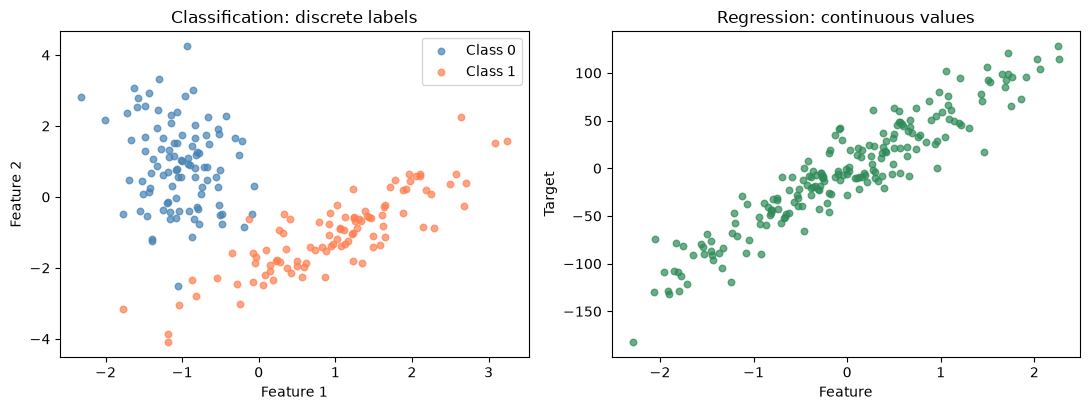

In [3]:
# --- Classification vs Regression: two different kinds of prediction ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Left: binary classification (discrete labels)
Xc, yc = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0,
                             n_clusters_per_class=1, random_state=7)
axes[0].scatter(Xc[yc == 0, 0], Xc[yc == 0, 1], c="steelblue", s=22, alpha=0.7, label="Class 0")
axes[0].scatter(Xc[yc == 1, 0], Xc[yc == 1, 1], c="coral",    s=22, alpha=0.7, label="Class 1")
axes[0].set_title("Classification: discrete labels")
axes[0].set_xlabel("Feature 1"); axes[0].set_ylabel("Feature 2"); axes[0].legend()

# Right: regression (continuous values)
Xr, yr = make_regression(n_samples=200, n_features=1, noise=20, random_state=7)
axes[1].scatter(Xr, yr, c="seagreen", s=22, alpha=0.7)
axes[1].set_title("Regression: continuous values")
axes[1].set_xlabel("Feature"); axes[1].set_ylabel("Target")

plt.tight_layout()
plt.show()

**What did we learn from this output?**

The left plot shows a classification problem: each point belongs to a discrete class, and
a prediction is right or wrong. The right plot shows a regression problem: there is a
continuous relationship, and predictions can be *close* or *far* from the true value.

**What would this mean in a real-world application?**

If you evaluate a regression model with classification metrics (or vice versa), the numbers
will be meaningless — you would be measuring the wrong thing. The choice of the metric
family must always follow the type of problem.

---

#### Beginner Perspective

*Classification = categories, regression = numbers. Use count-based metrics for one and
distance-based metrics for the other.*

#### Expert Perspective

*Even within one problem type, the "right" metric depends on the cost structure: in
regression, a huge error on one house may matter far more than many small errors (that is
what MSE captures and MAE does not) — the metric encodes the business's tolerance for
large errors.*

---

[⬅ Previous](#sec1) · [🏠 Table of Contents](#toc) · [Next ➡](#sec3)

📗 **Back to basics:** this topic has no separate section in the Simple
notebook — the essential version lives in **Section 1: Introduction to Model
Evaluation** (`ML_Model_Evaluation_Simple.ipynb`), which covers evaluating a model on
unseen data.


<a id="sec3"></a>
## 3. The Confusion Matrix

The confusion matrix is the **foundation** of classification evaluation. Every important
classification metric is built from its four numbers, so it is worth understanding deeply.

For a **binary** classifier there are exactly four outcomes, depending on whether the
*actual* class was positive and whether the *prediction* was positive:

|  | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | ✅ **TP** — True Positive | ❌ **FN** — False Negative |
| **Actual Negative** | ❌ **FP** — False Positive | ✅ **TN** — True Negative |

### Simple definitions

| Symbol | Name | Meaning in words |
|---|---|---|
| **TP** | True Positive | Correctly predicted positive ("caught it, and it was real") |
| **TN** | True Negative | Correctly predicted negative ("correctly left it alone") |
| **FP** | False Positive | Predicted positive, but it was actually negative ("false alarm") |
| **FN** | False Negative | Predicted negative, but it was actually positive ("missed it") |

### A real-life example: disease detection

Imagine a test that screens 200 patients for a disease. 80 patients are actually sick
(positive) and 120 are healthy (negative).

- The test correctly identifies **70** sick patients → **TP = 70**
- The test misses **10** sick patients (tells them they are healthy) → **FN = 10**
- The test wrongly alarms **15** healthy patients → **FP = 15**
- The test correctly clears **105** healthy patients → **TN = 105**

### Business meaning of errors — the crucial part

| Error | In this scenario | Consequence |
|---|---|---|
| **FP** | Healthy person incorrectly told they are sick | Unnecessary worry, extra tests, possibly unnecessary treatment |
| **FN** | Sick person incorrectly told they are healthy | Disease goes untreated; the patient may get worse — and may even spread it |

**Which error is potentially more dangerous?**

Most medical experts would say **FN is more dangerous here**: a missed disease can
progress, cause serious harm, and in the worst case lead to death. An FP causes distress
and wasted resources, but the patient is still healthy and can recover from a wrong scare.

**Which metric should therefore receive greater attention?**

Because FN is the dangerous error, we should pay attention to **recall / sensitivity**
(the ability to find actual sick patients). This is a *judgment*, not a formula — and the
judgment is driven by the business (here: medical) consequences, not by the numbers
themselves. (For a *screening* test where follow-up is cheap, we may even accept many FP
to catch almost every sick person — the threshold can be tuned to make FN very unlikely.)

Let's build the confusion matrix in Python.


In [4]:
# --- Confusion Matrix in Python ---
import numpy as np
from sklearn.metrics import confusion_matrix

# 200 patients: first 80 are actually sick (1), next 120 are healthy (0)
y_true = np.array([1] * 80 + [0] * 120)

# Model predictions: 70 sick detected (TP), 10 sick missed (FN),
# 15 healthy alarmed (FP), 105 healthy cleared (TN)
y_pred = np.array([1] * 70 + [0] * 10 + [1] * 15 + [0] * 105)

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix (rows = ACTUAL, columns = PREDICTED):")
print(cm)
print()
print("sklearn layout:  [[TN, FP],")
print("                  [FN, TP]]")
print()

# Extract the four numbers explicitly
tn, fp, fn, tp = cm.ravel()
print(f"TP = {tp}   (sick patients correctly detected)")
print(f"TN = {tn}   (healthy patients correctly cleared)")
print(f"FP = {fp}   (healthy patients wrongly alarmed)")
print(f"FN = {fn}   (sick patients wrongly told they are healthy)")

Confusion matrix (rows = ACTUAL, columns = PREDICTED):
[[105  15]
 [ 10  70]]

sklearn layout:  [[TN, FP],
                  [FN, TP]]

TP = 70   (sick patients correctly detected)
TN = 105   (healthy patients correctly cleared)
FP = 15   (healthy patients wrongly alarmed)
FN = 10   (sick patients wrongly told they are healthy)


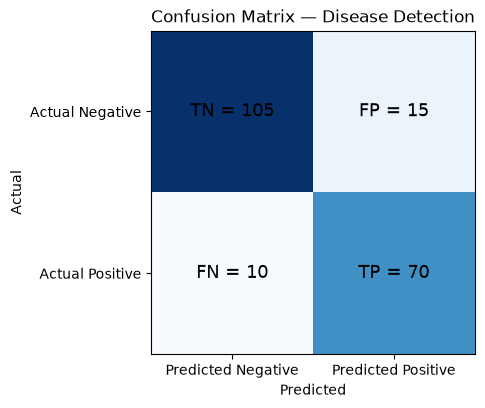

In [5]:
# --- Confusion Matrix as a heatmap ---
fig, ax = plt.subplots(figsize=(5.2, 4.2))
cell_labels = [["TN = " + str(tn), "FP = " + str(fp)],
               ["FN = " + str(fn), "TP = " + str(tp)]]
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Predicted Negative", "Predicted Positive"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual Negative", "Actual Positive"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cell_labels[i][j], ha="center", va="center", fontsize=13)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Disease Detection")
plt.show()

**What did we learn from this output?**

The matrix shows the *whole story* in four numbers: 70 sick patients caught, 10 missed,
15 false alarms, 105 correctly cleared. No single percentage can replace this picture —
this is why experts always look at the confusion matrix before judging a model.

**What would this mean in a real-world application?**

If you were a hospital administrator, the FN = 10 row alone would tell you that 10 sick
people are going home untreated. Depending on the disease, you might decide this is
unacceptable — even if the model "looks good" in other respects — and push for a lower
threshold that catches more sick people, accepting more false alarms in exchange.

---

#### Beginner Perspective

*Memorize the four boxes: TP and TN are correct; FP is a false alarm; FN is a miss. Read
the matrix with actual classes on rows and predicted classes on columns (scikit-learn's
default).*

#### Expert Perspective

*Experts attach costs to each cell: cost(FP) × FP + cost(FN) × FN + ... becomes an
objective function, and the confusion matrix becomes the input to a **business
optimization**, not just a report. They also check whether FN and FP are evenly spread
across subgroups — a model can be excellent overall and systematically wrong for a
particular group of customers.*

---

[⬅ Previous](#sec2) · [🏠 Table of Contents](#toc) · [Next ➡](#sec4)

📗 **Back to basics:** see **Section 2: The Confusion Matrix** in
`ML_Model_Evaluation_Simple.ipynb` — TP/TN/FP/FN in plain words, with the
disease-detection example.


<a id="sec4"></a>
## 4. Accuracy

### A. Simple Definition

Accuracy answers one question:

> **"How often is the model right overall?"**

It is the fraction of all predictions that are correct.

### B. Intuition

Imagine a teacher marking 200 exam answers. Accuracy is the fraction of answers the model
got right out of everything it was asked. Intuitive, simple, and the first metric everyone
learns — which is exactly why its limitations (below) are so easy to miss.

### C. Formula

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} = \frac{\text{correct predictions}}{\text{all predictions}}$$

### D. Meaning of Each Component

| Component | Meaning |
|---|---|
| TP + TN | All predictions that were correct |
| TP + TN + FP + FN | All predictions (the whole dataset) |

### E. Small Numerical Example

Using our earlier confusion matrix: TP = 80, TN = 90, FP = 10, FN = 20.

$$\text{Accuracy} = \frac{80 + 90}{80 + 90 + 10 + 20} = \frac{170}{200} = 0.85$$

The model is correct 85% of the time.


In [6]:
# --- Accuracy: by hand and with scikit-learn ---
from sklearn.metrics import accuracy_score

# Example values: TP=80, TN=90, FP=10, FN=20
TP, TN, FP, FN = 80, 90, 10, 20
acc_manual = (TP + TN) / (TP + TN + FP + FN)
print(f"By hand: Accuracy = ({TP} + {TN}) / ({TP} + {TN} + {FP} + {FN}) = {acc_manual:.3f}")

# The same numbers as label/prediction arrays
# 100 actual positives (80 TP + 20 FN) and 100 actual negatives (90 TN + 10 FP)
y_true = np.array([1] * 100 + [0] * 100)
y_pred = np.array([1] * 80 + [0] * 20 + [1] * 10 + [0] * 90)

print(f"With sklearn: Accuracy = {accuracy_score(y_true, y_pred):.3f}")

By hand: Accuracy = (80 + 90) / (80 + 90 + 10 + 20) = 0.850
With sklearn: Accuracy = 0.850


### F. Real-Life Beginner Scenario — Student pass/fail

A model predicts whether students pass (1) or fail (0) a course. TP = student predicted
to pass and passed; TN = student predicted to fail and failed; FP = predicted to pass but
failed; FN = predicted to fail but passed. Accuracy tells you the fraction of students the
model judged correctly — but it does **not** tell you whether the model's *mistakes* are
the expensive kind (e.g., wrongly failing a student who would have passed).

### G. Real-Life Expert Scenario — Rare disease screening

A hospital screens for a disease that only **1%** of patients have. Consider a "model"
that simply predicts **"not diseased" for every single patient** — it never looks at the
data. What is its accuracy?

- Of 10,000 patients, 9,900 are healthy → all correctly predicted "not diseased" → TN = 9,900
- 100 are sick → all wrongly predicted "not diseased" → FN = 100, TP = 0, FP = 0

$$\text{Accuracy} = \frac{0 + 9900}{10000} = 0.99$$

**A useless model scores 99% accuracy.** It detected zero sick patients. This is the
classic trap of imbalanced data: when one class dominates, accuracy is easily gamed by
always predicting the majority class.

### H. FP/FN Business Impact

| Error | In this scenario | Consequence |
|---|---|---|
| FP | Healthy person flagged as sick | Anxiety, unnecessary tests, wasted money |
| FN | Sick person cleared as healthy | **Disease progresses untreated** — potentially fatal |

Here FN is dramatically more expensive, yet accuracy treats FP and FN **identically**:
both are simply "wrong". Accuracy has no concept of *which* error matters more.

### I. Metric Selection

Accuracy is appropriate when:

- the classes are reasonably balanced, **and**
- the costs of FP and FN are roughly equal, **and**
- overall correctness is genuinely what the business cares about.

Accuracy is **misleading** when the data is imbalanced or when one error type is much more
expensive than the other — which, in real business problems, is almost always the case.

### J. Threshold Consideration

Accuracy is reported at a fixed threshold (usually 0.5). Moving the threshold changes FP
and FN counts and therefore changes accuracy. A threshold that maximizes accuracy may not
minimize business cost — cost depends on the *types* of errors, not just their total.

### K. When to Use It

Balanced datasets, similar error costs, and problems where "is the prediction correct?"
is a fair question (e.g., image classification with roughly equal class sizes).

### L. When NOT to Use It

- Imbalanced datasets (fraud, disease, intrusion, rare events)
- When FP and FN have very different costs
- When you care about finding a specific class (accuracy hides misses)

### M. Advantages and Limitations

| ✅ Advantages | ❌ Limitations |
|---|---|
| Simple, intuitive, easy to explain to non-technical stakeholders | Treats all errors as equally bad |
| Single number that summarizes overall correctness | Misleading on imbalanced data |
| Easy to compute | Hides how errors are distributed between classes |

Now let's see the trap with real numbers.


In [7]:
# --- Why accuracy can be completely misleading ---
# 10,000 credit-card transactions: 100 fraudulent (1%), 9,900 legitimate (0%)
y_true = np.array([1] * 100 + [0] * 9900)

# A "model" that ALWAYS predicts "not fraudulent"
y_pred = np.zeros_like(y_true)

from sklearn.metrics import recall_score

acc = accuracy_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
print(f"Accuracy = {acc:.4f}   <-- looks amazing!")
print(f"Recall   = {rec:.4f}   <-- we found ZERO of the 100 frauds")
print()
print("Is this model actually useful?  NO.")
print("It would let every single fraudulent transaction through.")

Accuracy = 0.9900   <-- looks amazing!
Recall   = 0.0000   <-- we found ZERO of the 100 frauds

Is this model actually useful?  NO.
It would let every single fraudulent transaction through.


**What did we learn from this output?**

99% accuracy, zero fraud detected. The model is technically "accurate" and commercially
worthless — worse than worthless, because it creates a false sense of security.

**What would this mean in a real-world application?**

The same trap applies to **fraud detection**, **disease detection**, and **intrusion
detection**: these are all rare-event problems. In all of them, the minority class is the
one that matters, and accuracy actively hides how badly the model handles it.

> **Never evaluate an imbalanced classification problem using accuracy alone.**

(We will see the tools for these problems — precision, recall, F1, PR-AUC — in the next
sections.)

---

#### Beginner Perspective

*Accuracy = "how often is the model right overall". If one class is rare, accuracy can
look great while the model is useless. Always check the confusion matrix too.*

#### Expert Perspective

*Experts replace accuracy with a **cost-weighted objective** whenever FP and FN have
different costs, and they choose evaluation metrics from the business loss function —
not from habit. On imbalanced data, accuracy is rarely even reported.*

---

[⬅ Previous](#sec3) · [🏠 Table of Contents](#toc) · [Next ➡](#sec5)

📗 **Back to basics:** see **Section 3: Accuracy** in
`ML_Model_Evaluation_Simple.ipynb` — the accuracy trap and why accuracy alone is never
enough.


<a id="sec5"></a>
## 5. Precision

### A. Simple Definition

Precision answers:

> **"When the model says 'positive', how often should I trust it?"**

### B. Intuition

Precision looks only at the **positive predictions the model made** and asks how many of
them were right. High precision means **few false alarms**: when the model raises its hand
and says "positive!", it is almost always correct.

### C. Formula

$$\text{Precision} = \frac{TP}{TP + FP}$$

### D. Meaning of Each Component

| Component | Meaning |
|---|---|
| TP | Actual positives correctly predicted as positive |
| FP | Actual negatives wrongly predicted as positive |
| TP + FP | **All predicted positives** — everything the model flagged |

Precision is computed **only over predicted positives**. Missed positives (FN) do not
appear in this formula — precision never tells you what the model *missed*.

### E. Small Numerical Example

A spam filter labels 55 emails as spam. Of these, 50 really are spam and 5 are legitimate
emails that were wrongly filtered:

TP = 50, FP = 5

$$\text{Precision} = \frac{50}{50 + 5} = \frac{50}{55} \approx 0.909$$

**91% of the emails flagged as spam really were spam.**

### F. Real-Life Beginner Scenario — Spam Email

- FP = a legitimate email (e.g., your boss's message) lands in the spam folder.
- FN = a real spam email lands in your inbox.

High precision means the spam folder almost never contains real mail — which matters,
because **you may never see an email that was wrongly filtered**.

### G. Real-Life Expert Scenario — Bank fraud alerts

A bank's fraud-detection system flags transactions for review. Every alert either blocks a
customer's card or is investigated by a human analyst.

- FP = a legitimate customer's transaction is flagged as fraud.
- FN = real fraud is not flagged.

### H. FP/FN Business Impact

| Error | In this scenario | Consequence |
|---|---|---|
| **FP** | Legitimate customer blocked / investigated | Customer frustration, blocked purchases, lost sales, wasted analyst time, reputational damage |
| **FN** | Real fraud not flagged | Direct financial loss from the fraud itself |

**Which error is more expensive?** It depends. If blocking customers causes churn and each
investigation costs analyst hours, FP is very expensive. If fraud losses are large and
investigations are cheap, FN is worse. Precision is the metric that measures **the cost of
FP directly** — every false alarm reduces precision.

### I. Metric Selection

**Use precision when false positives are particularly costly**, because precision is the
direct measure of the false-alarm rate among predictions: *"of all the positives I act on,
how many will be wrong?"* For example, if every fraud alert triggers a manual
investigation, low precision means analysts waste most of their time on innocent customers.

### J. Threshold Consideration

Raising the classification threshold (requiring higher confidence before saying
"positive") usually **raises precision**: the model flags fewer cases, and the ones it
flags tend to be the most confident — hence more likely to be genuinely positive. The
cost: you will also *miss* more true positives (lower recall). Lowering the threshold has
the opposite effect.

### K. When to Use It

When the cost of an FP is high: spam filtering, expensive manual review queues, medical
treatment decisions (don't treat healthy people unnecessarily), automated blocking
systems.

### L. When NOT to Use It

When a missed positive is the dominant risk. A spam filter with 100% precision but 5%
recall would catch almost no spam — the model would be useless. Precision alone can
look great while the model misses almost everything.

### M. Advantages and Limitations

| ✅ Advantages | ❌ Limitations |
|---|---|
| Directly measures the false-alarm burden | Ignores missed positives (FN) completely |
| Meaningful for imbalanced data | Can be inflated by predicting only a few, very confident positives |
| Easy to explain to business stakeholders | Says nothing about how many positives were found |

Now the Python calculation.


In [8]:
# --- Precision in Python ---
from sklearn.metrics import precision_score

# Spam detection: 60 real spam emails, 140 legitimate emails
# Predictions: 50 TP, 10 FN, 5 FP, 135 TN
y_true = np.array([1] * 60 + [0] * 140)
y_pred = np.array([1] * 50 + [0] * 10 + [1] * 5 + [0] * 135)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion matrix:\n", cm)
print(f"\nTP={tp}, FP={fp}, FN={fn}, TN={tn}")

# Manual calculation
precision_manual = tp / (tp + fp)
print(f"\nBy hand:  Precision = {tp} / ({tp} + {fp}) = {precision_manual:.3f}")

# scikit-learn
print(f"sklearn:  Precision = {precision_score(y_true, y_pred):.3f}")

Confusion matrix:
 [[135   5]
 [ 10  50]]

TP=50, FP=5, FN=10, TN=135

By hand:  Precision = 50 / (50 + 5) = 0.909
sklearn:  Precision = 0.909


**What did we learn from this output?**

The spam filter's precision is 0.909: 91% of the emails it puts in the spam folder really
are spam. The remaining ~9% (5 emails) are legitimate messages wrongly filtered.

**What would this mean in a real-world application?**

If those 5 wrongly-filtered emails contain important business mail, 9% of your flagged
messages are real. Depending on how much a lost email costs, you might demand higher
precision (fewer false alarms) — even if that means some spam slips through. The
"acceptable" precision is a business decision, not a mathematical one.

---

#### Beginner Perspective

*Precision = "of everything the model called positive, how much was right?" High precision
= few false alarms.*

#### Expert Perspective

*Precision must be interpreted relative to the operating threshold, the prevalence of the
positive class, the downstream intervention cost, and the false-positive burden. On rare
events, even a "low" precision (e.g., 0.05) can be a great business result if the
intervention is cheap — precision is never judged in the abstract, only against the cost
of acting on a false alarm.*

---

[⬅ Previous](#sec4) · [🏠 Table of Contents](#toc) · [Next ➡](#sec6)

📗 **Back to basics:** see **Section 4: Precision** in
`ML_Model_Evaluation_Simple.ipynb` — the worked example and the false-alarm business
cases.


<a id="sec6"></a>
## 6. Recall / Sensitivity

### A. Simple Definition

Recall (also called **sensitivity** or the **true positive rate**) answers:

> **"Of all the actual positives, how many did the model find?"**

### B. Intuition

Recall looks at the **actual positive cases** and asks how many the model managed to
catch. High recall means the model **rarely misses a positive** — good when missing one is
dangerous.

### C. Formula

$$\text{Recall} = \frac{TP}{TP + FN}$$

### D. Meaning of Each Component

| Component | Meaning |
|---|---|
| TP | Actual positives correctly found |
| FN | Actual positives **missed** |
| TP + FN | All actual positives |

Recall is computed **only over actual positives**. False alarms (FP) do not appear in the
formula — recall never tells you how many false alarms the model raises.

### E. Small Numerical Example

A hospital test screens 40 sick patients and correctly identifies 32 of them:

TP = 32, FN = 8

$$\text{Recall} = \frac{32}{32 + 8} = \frac{32}{40} = 0.80$$

The test finds **80% of the sick patients** — and misses 20%.

### F. Real-Life Beginner Scenario — Disease detection

- FN = a sick patient is told they are healthy.
- FP = a healthy patient is told they are sick.

Recall measures the first kind of failure directly: **how many sick patients are being
sent home untreated?**

### G. Real-Life Expert Scenario — Security intrusion detection

A security system monitors a network for intrusions.

- FN = an actual intrusion is **not** detected — an attacker operates unnoticed.
- FP = normal traffic is flagged as an attack (annoying, but often just an alert).

### H. FP/FN Business Impact

| Error | In this scenario | Consequence |
|---|---|---|
| FP | Normal traffic flagged as attack | Analyst time wasted on false alarms |
| FN | Real intrusion missed | **The attacker may steal data, money, or credentials — potentially for months** |

**Which error is more expensive?** For intrusion detection, FN is usually far more
expensive: the *cost of a missed breach* dwarfs the cost of investigating a few false
alarms. Recall is the metric that directly measures the FN problem: *"of all real
attacks, how many did we catch?"*

### I. Metric Selection

**Use recall when false negatives are particularly costly**, because recall is the direct
measure of missed positives: *"of all the positives that exist, how many did we find?"*
If missing a case can be catastrophic (untreated disease, undetected fraud, missed
breach), recall deserves the most attention.

### J. Threshold Consideration

Lowering the threshold makes the model predict "positive" more easily → it finds more true
positives (higher recall) but also raises more false alarms (lower precision). You can
trade recall against precision by moving the threshold — but you cannot maximize both at
once.

### K. When to Use It

Screening for rare but serious events: disease screening, fraud detection, intrusion
detection, safety systems. Whenever the question "did we miss any?" is the critical one.

### L. When NOT to Use It

When false positives are the expensive error and acting on every positive is costly.
A model with 100% recall can achieve it by labeling *everything* positive — useless if
every positive triggers an expensive action.

### M. Advantages and Limitations

| ✅ Advantages | ❌ Limitations |
|---|---|
| Directly measures the missed-positive problem | Ignores false alarms completely |
| Meaningful for imbalanced data | Can be trivially maxed out by predicting everything positive |
| Easy to explain: "how many did we catch?" | Says nothing about precision of the positive predictions |

Now the Python calculation.


In [9]:
# --- Recall / Sensitivity in Python ---
from sklearn.metrics import recall_score

# Disease detection: 40 sick patients, 160 healthy patients
# Predictions: 32 TP, 8 FN, 4 FP, 156 TN
y_true = np.array([1] * 40 + [0] * 160)
y_pred = np.array([1] * 32 + [0] * 8 + [1] * 4 + [0] * 156)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion matrix:\n", cm)
print(f"\nTP={tp}, FP={fp}, FN={fn}, TN={tn}")

# Manual calculation
recall_manual = tp / (tp + fn)
print(f"\nBy hand:  Recall = {tp} / ({tp} + {fn}) = {recall_manual:.3f}")

# scikit-learn
print(f"sklearn:  Recall = {recall_score(y_true, y_pred):.3f}")

# A model that predicts EVERYTHING as positive has recall = 1.0 but precision near 0
y_pred_all_positive = np.ones_like(y_true)
print(f"\nIf we predicted everything positive: recall = {recall_score(y_true, y_pred_all_positive):.2f}, "
      f"precision = {precision_score(y_true, y_pred_all_positive):.3f}")

Confusion matrix:
 [[156   4]
 [  8  32]]

TP=32, FP=4, FN=8, TN=156

By hand:  Recall = 32 / (32 + 8) = 0.800
sklearn:  Recall = 0.800

If we predicted everything positive: recall = 1.00, precision = 0.200


**What did we learn from this output?**

The test finds 80% of sick patients — 8 out of 40 are missed. And notice the warning at
the bottom: recall can be pushed to 1.0 by simply calling *everything* positive. A model
with recall 1.0 is not automatically good — it may just be shouting "positive!" at
everything, which is why precision and recall must always be examined together.

**What would this mean in a real-world application?**

For the hospital, recall = 0.80 means: *out of every 5 sick patients, 1 goes home
untreated.* If the disease is dangerous, the hospital may refuse to accept that — and
lower the threshold so recall rises, accepting more false alarms (higher FP) as the price
of catching more real cases. The trade-off is a business decision.

---

#### Beginner Perspective

*Recall = "of all the real positives, how many did we catch?" High recall = few misses.
Remember: a model that always says "positive" has perfect recall but is useless.*

#### Expert Perspective

*Experts treat recall as the *cost of missing the positive class*, and they always read it
together with precision and prevalence. For rare events, "high recall" can still mean very
few positives found in absolute terms; experts convert recall into expected
*number of caught cases* and expected *cost of missed cases* to make it concrete for the
business.*

---

[⬅ Previous](#sec5) · [🏠 Table of Contents](#toc) · [Next ➡](#sec7)

📗 **Back to basics:** see **Section 5: Recall (Sensitivity)** in
`ML_Model_Evaluation_Simple.ipynb` — the worked example and the missed-positive
business cases.


<a id="sec7"></a>
## 7. Specificity

### A. Simple Definition

Specificity answers:

> **"Of all the actual negatives, how many did the model correctly identify?"**

### B. Intuition

While recall measures how well the model finds **positives**, specificity measures how well
it **leaves negatives alone**. High specificity means the model rarely raises a false
alarm — actual negatives are rarely wrongly flagged.

### C. Formula

$$\text{Specificity} = \frac{TN}{TN + FP}$$

### D. Meaning of Each Component

| Component | Meaning |
|---|---|
| TN | Actual negatives correctly identified as negative |
| FP | Actual negatives wrongly flagged as positive |
| TN + FP | All actual negatives |

### E. Small Numerical Example

Using the same disease-test numbers as the recall example (TN = 156, FP = 4):

$$\text{Specificity} = \frac{156}{156 + 4} = \frac{156}{160} = 0.975$$

The test correctly clears **97.5% of healthy patients** — only 2.5% of healthy people get
a false alarm.

### F. Real-Life Beginner Scenario

A medical test screening healthy people for a disease. Specificity answers:
*"if you are healthy, how likely is the test to tell you so?"* Low specificity means many
healthy people get frightening false-positive results.

### G. Real-Life Expert Scenario

An automated **quality-control** system in a factory inspects products.

- FP = a good product is rejected (wasted product, lost money).
- FN = a defective product ships to the customer (bad reputation, returns, liability).

### H. FP/FN Business Impact

| Error | In this scenario | Consequence |
|---|---|---|
| FP | Good product rejected | Direct loss of product value + wasted inspection time |
| FN | Defective product shipped | Customer complaints, returns, brand damage |

**Which error is more expensive?** If products are expensive to produce and defects are
cheap to replace, FP is the expensive error — and **specificity** is the metric that
directly measures it (how often good products are wrongly rejected).

### Precision vs Specificity — an important distinction

Both involve FP, but they ask **different questions from different viewpoints**:

| Metric | Question | Conditioned on |
|---|---|---|
| **Precision** | Of all *predicted* positives, how many were right? | The model's positive predictions |
| **Specificity** | Of all *actual* negatives, how many were correctly left alone? | The actual negatives |

Precision asks "are my alarms trustworthy?" Specificity asks "how often do I wrongly
alarm the people who are actually fine?" Both drop when FP rises — precision drops
because FP inflates the denominator of predicted positives; specificity drops because FP
inflates the numerator of wrongly-flagged negatives.

### I. Metric Selection

**Use specificity when reducing false alarms on actual negatives is the priority** —
e.g., when you cannot afford to harass healthy people, reject good products, or trigger
expensive follow-up procedures on innocent cases. In medicine, a screening test with low
specificity floods the system with patients who need unnecessary confirmatory tests.

### J. Threshold Consideration

Raising the threshold makes the model more conservative about predicting "positive", which
usually **increases specificity** (fewer negatives are wrongly flagged) at the cost of
**decreasing recall** (more positives are missed). Specificity and recall trade off
directly against each other through the threshold.

### K. When to Use It

Quality control, medical screening (to size the follow-up burden), fraud alerting (to
measure how many innocent customers get bothered), and any setting where "don't bother the
negatives" is a business requirement.

### L. When NOT to Use It

When the dominant risk is missing positives. A test with 100% specificity could achieve it
by predicting "negative" for everything — and detect zero sick patients. Specificity alone
says nothing about finding the positive class.

### M. Advantages and Limitations

| ✅ Advantages | ❌ Limitations |
|---|---|
| Directly measures the false-alarm burden on actual negatives | Ignores missed positives (FN) completely |
| Easy to explain: "how often do healthy people get left alone?" | Trivially maximized by predicting everything negative |
| Useful for sizing downstream costs (tests, investigations) | Must be paired with recall for a complete picture |

Now the Python calculation.


In [10]:
# --- Specificity in Python ---
# scikit-learn has no specificity_score function; we compute it from the confusion matrix

# Same disease-test example: 32 TP, 8 FN, 4 FP, 156 TN
y_true = np.array([1] * 40 + [0] * 160)
y_pred = np.array([1] * 32 + [0] * 8 + [1] * 4 + [0] * 156)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

specificity = tn / (tn + fp)
print(f"Specificity = TN / (TN + FP) = {tn} / ({tn} + {fp}) = {specificity:.3f}")

# Compare with recall and precision on the same model
recall = tp / (tp + fn)
precision = tp / (tp + fp)
print(f"Recall    = TP / (TP + FN) = {recall:.3f}   (finding sick patients)")
print(f"Precision = TP / (TP + FP) = {precision:.3f}   (trust in positive predictions)")
print(f"Specificity = {specificity:.3f}              (leaving healthy patients alone)")

Specificity = TN / (TN + FP) = 156 / (156 + 4) = 0.975
Recall    = TP / (TP + FN) = 0.800   (finding sick patients)
Precision = TP / (TP + FP) = 0.889   (trust in positive predictions)
Specificity = 0.975              (leaving healthy patients alone)


**What did we learn from this output?**

The same model scores 0.800 recall, 0.889 precision, and 0.975 specificity. These three
numbers answer three different business questions: *do we find the sick?* (recall), *can
we trust our alarms?* (precision), and *do we avoid alarming healthy people?*
(specificity). None of them alone is "the" answer.

**What would this mean in a real-world application?**

If this test were deployed nationwide and 1,000,000 healthy people were screened,
specificity 0.975 means **25,000 healthy people** would receive a false-positive result —
each needing a follow-up test. A hospital administrator evaluating this test would budget
for that follow-up load, or demand a higher-specificity test (accepting lower recall).
The metric that matters is dictated by the operational consequences.

---

#### Beginner Perspective

*Specificity = "how often are actual negatives correctly left alone?" It is recall's
mirror image, measured on the negative class.*

#### Expert Perspective

*Experts pair specificity with recall to fully describe the two error types, and use
specificity to estimate operational load (number of false alarms × cost per alarm). In
multi-class and multi-threshold settings they generalize it via ROC analysis — the false
positive rate (FPR = 1 − specificity) is the x-axis of the ROC curve, next section.*

---

[⬅ Previous](#sec6) · [🏠 Table of Contents](#toc) · [Next ➡](#sec8)

📗 **Back to basics:** see **Section 6: Specificity** in
`ML_Model_Evaluation_Simple.ipynb` — the same formula with a simpler example.


<a id="sec8"></a>
## 8. F1 Score

### A. Simple Definition

The F1 score is the **harmonic mean of precision and recall** — a single number that
summarizes both.

### B. Intuition

Precision alone can be high while the model misses everything; recall alone can be high
while the model cries wolf. F1 punishes models that are extreme in either direction: it is
only high when **both** precision and recall are decent. Think of it as the "balanced
score" for the positive class.

### C. Formula

$$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

### Why the harmonic mean and not the arithmetic mean?

The harmonic mean is much more sensitive to small values. If precision = 0.9 and
recall = 0.1:

- Arithmetic mean = (0.9 + 0.1) / 2 = **0.50**
- Harmonic mean = 2·(0.9·0.1)/(0.9+0.1) = 0.18/1.0 = **0.18**

The harmonic mean correctly tells you: *this model is bad*, because it misses 90% of the
positives — a fact the arithmetic mean would hide. F1 can never exceed the smaller of
precision and recall, which is exactly the property we want.

### D. Meaning of Each Component

| Component | Meaning |
|---|---|
| Precision | Trust in positive predictions (FP control) |
| Recall | Ability to find positives (FN control) |
| F1 | Balance between the two |

### E. Small Numerical Examples — three situations

| Situation | TP | FP | FN | Precision | Recall | F1 |
|---|---|---|---|---|---|---|
| High precision, low recall | 30 | 2 | 60 | 0.938 | 0.333 | **0.49** |
| Low precision, high recall | 85 | 80 | 5 | 0.515 | 0.944 | **0.67** |
| Balanced | 60 | 20 | 20 | 0.750 | 0.750 | **0.75** |

F1 is highest when the two are balanced — but "highest F1" is not automatically the best
model for the business, as we will see below.


In [11]:
# --- F1 Score: the three situations ---
def report(name, tp, tn, fp, fn):
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * precision * recall / (precision + recall)
    print(f"{name:34s} P = {precision:.3f}  R = {recall:.3f}  F1 = {f1:.3f}")

report("High precision, low recall",  tp=30, tn=40, fp=2,  fn=60)
report("Low precision, high recall",  tp=85, tn=10, fp=80, fn=5)
report("Balanced",                    tp=60, tn=40, fp=20, fn=20)

# scikit-learn on the balanced example
from sklearn.metrics import f1_score
y_true = np.array([1] * 80 + [0] * 60)          # 80 actual positives, 60 actual negatives
y_pred = np.array([1] * 60 + [0] * 20 + [1] * 20 + [0] * 40)  # 60 TP, 20 FN, 20 FP, 40 TN
print(f"\nsklearn F1 (balanced example) = {f1_score(y_true, y_pred):.3f}")

High precision, low recall         P = 0.938  R = 0.333  F1 = 0.492
Low precision, high recall         P = 0.515  R = 0.944  F1 = 0.667
Balanced                           P = 0.750  R = 0.750  F1 = 0.750

sklearn F1 (balanced example) = 0.750


### F. Real-Life Beginner Scenario

A teacher's model predicts which students will pass an exam. Precision says "of the
students I predicted would pass, how many really did?" Recall says "of the students who
really passed, how many did I predict?" F1 combines both into one "how good am I at this
prediction task overall?" number.

### G. Real-Life Expert Scenario — Customer churn

A telecom company predicts which customers will churn, so it can send retention offers.

- FP = offer sent to a customer who was not going to churn → wasted offer (cost).
- FN = churning customer gets no offer → **customer lost (revenue loss)**.

### H. FP/FN Business Impact

| Error | In this scenario | Consequence |
|---|---|---|
| FP | Offer to a loyal customer | Wasted money, possible irritation ("why are you begging me to stay?") |
| FN | No offer to a churning customer | Lost recurring revenue — usually far more expensive than the offer |

### I. Metric Selection

**Use F1 when you want a single number that balances precision and recall** — e.g., when
FP and FN costs are *roughly similar* or unknown, or when you are comparing models across
many thresholds and need one summary. It is the default "balanced" score for the positive
class.

### J. Threshold Consideration

F1 is usually reported at one threshold (often 0.5). Because precision and recall move in
opposite directions with the threshold, F1 has a **maximum at some intermediate
threshold** — the "balance point". If the business cares more about one error than the
other, the best threshold is *not* the F1-maximizing one.

### K. When to Use It

Imbalanced classification with roughly symmetric error costs; model selection over many
candidates; summarizing performance in a single number for non-technical audiences.

### L. When NOT to Use It

When FP and FN costs are very different. F1 treats both errors equally, so it cannot
represent a problem where one error costs 100× the other. **Never use F1 as the only
metric when error costs are asymmetric.**

### M. Advantages and Limitations

| ✅ Advantages | ❌ Limitations |
|---|---|
| Single balanced number for precision + recall | Treats FP and FN as equally costly |
| Works well on imbalanced data | Hides the individual precision/recall values |
| Easy to compare across models | Maximizing F1 ≠ minimizing business cost |

### The crucial question: is the model with the highest F1 always the best model?

**No.** Consider a medical screening test:

- Model X: F1 = 0.80 (precision 0.95, recall 0.69)
- Model Y: F1 = 0.78 (precision 0.65, recall 0.97)

Model X has the higher F1, but it *misses 31% of sick patients*. Model Y finds 97% of
them at the price of more false alarms. If the disease is dangerous, **Model Y is the
better business solution despite the lower F1** — because in this problem FN is the
expensive error, and F1 does not know that. This is why we always translate metrics back
into error costs.

---

#### Beginner Perspective

*F1 = harmonic mean of precision and recall. It is high only when both are decent. But
"highest F1" does not automatically mean "best for the business".*

#### Expert Perspective

*Experts generalize F1 with the Fβ score, which weights recall β times more than
precision (F2 favors recall, F0.5 favors precision), and they treat even that as a proxy:
the truly correct objective is the expected cost of errors — cost(FP)·FP + cost(FN)·FN —
which may have its optimum at a completely different threshold than F1's.*

---

[⬅ Previous](#sec7) · [🏠 Table of Contents](#toc) · [Next ➡](#sec9)

📗 **Back to basics:** see **Section 7: F1 Score** in
`ML_Model_Evaluation_Simple.ipynb` — the harmonic-mean intuition with a small table of
examples and the same warning.


<a id="sec9"></a>
## 9. The Precision–Recall Trade-off

### What is a classification threshold?

Most real classifiers do not output a final label directly. They output a **probability**
(a number between 0 and 1) — "how confident am I that this is positive?" — and we convert
that probability into a label by comparing it to a **threshold**:

$$\text{prediction} = \begin{cases} \text{positive}, & \text{if } p \geq \text{threshold} \\ \text{negative}, & \text{otherwise} \end{cases}$$

The default threshold is usually 0.5, but it is **not sacred**. It is a decision knob.

### What happens when we move the threshold?

- **Lower threshold** → the model predicts "positive" more easily → it finds **more true
  positives (higher recall)** but also raises **more false alarms (lower precision)**.
- **Higher threshold** → the model predicts "positive" only when very confident → **fewer
  false alarms (higher precision)** but **more missed positives (lower recall)**.

Precision and recall trade off against each other. You cannot have both at their maximum
simultaneously — the only question is *where* to balance them, and that is a business
decision.

Let's see it with real probabilities.


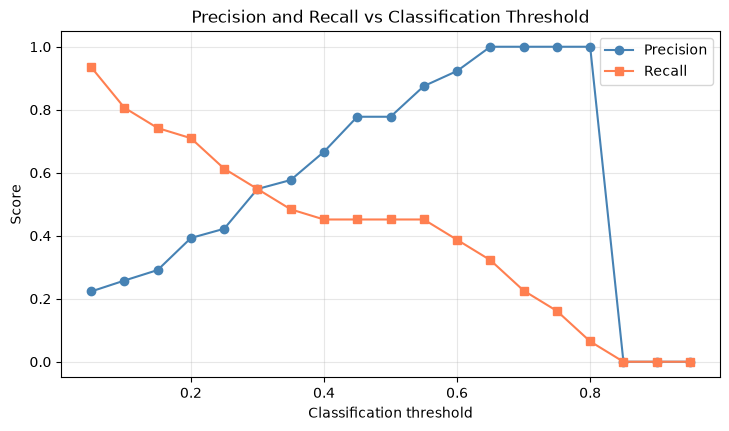

In [12]:
# --- Threshold sweep: precision and recall as functions of the threshold ---
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix

# Synthetic dataset: 20% positive class
X, y = make_classification(n_samples=500, n_features=5, n_informative=4, n_redundant=0,
                           weights=[0.8, 0.2], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]   # predicted probabilities of the positive class

thresholds = np.arange(0.05, 1.00, 0.05)
precisions, recalls = [], []
for t in thresholds:
    preds = (probs >= t).astype(int)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))

plt.figure(figsize=(8.5, 4.5))
plt.plot(thresholds, precisions, "o-", label="Precision", color="steelblue")
plt.plot(thresholds, recalls, "s-", label="Recall", color="coral")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
# --- The same sweep, but looking at the actual errors (FP and FN) ---
print(f"{'Threshold':>9s} {'Precision':>9s} {'Recall':>9s} {'FP':>4s} {'FN':>4s} {'Flagged':>7s}")
for t in [0.15, 0.30, 0.50, 0.70, 0.85]:
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    print(f"{t:>9.2f} {p:>9.3f} {r:>9.3f} {fp:>4d} {fn:>4d} {tp + fp:>7d}")

Threshold Precision    Recall   FP   FN Flagged
     0.15     0.291     0.742   56    8      79
     0.30     0.548     0.548   14   14      31
     0.50     0.778     0.452    4   17      18
     0.70     1.000     0.226    0   24       7
     0.85     0.000     0.000    0   31       0


**What did we learn from this output?**

As the threshold rises, precision climbs and recall falls — the classic trade-off. The
error table shows *why*: at threshold 0.15 the model flags many cases (high recall, many
FP); at 0.85 it flags few (high precision, many FN). The 0.5 default is just one point on
this curve, and often not the best one for the business.

**What would this mean in a real-world application — fraud detection?**

- **Low threshold** → more fraud detected, but more legitimate customers blocked and more
  alerts for analysts to investigate.
- **High threshold** → fewer false alarms, but more fraud slips through undetected.

If blocking a legitimate customer is cheap to undo but a missed fraud is expensive, you
operate at a low threshold and accept the false alarms. If every alert costs an hour of an
analyst's time, you operate at a high threshold and accept the missed frauds. **The
"right" threshold is a business decision, not a technical default.**

---

#### Beginner Perspective

*Threshold down → more positives → higher recall, lower precision. Threshold up → fewer
positives → higher precision, lower recall. You cannot have both at once.*

#### Expert Perspective

*Experts treat the threshold as an *operating point* chosen to optimize an explicit cost
function (Section 21 shows this in practice), and they evaluate the whole trade-off curve
(ROC / PR, Sections 10–12) rather than a single threshold. They also account for
prevalence drift: a threshold tuned on last year's data may be wrong this year if the
positive rate changes.*

---

[⬅ Previous](#sec8) · [🏠 Table of Contents](#toc) · [Next ➡](#sec10)

📗 **Back to basics:** see **Section 8: The Precision–Recall Trade-off** in
`ML_Model_Evaluation_Simple.ipynb` — thresholds and the trade-off on a small fraud
dataset, with the same business framing.


<a id="sec10"></a>
## 10. The ROC Curve

### What is the ROC curve?

The **Receiver Operating Characteristic** curve plots, for **every possible threshold**,
two quantities against each other:

- **True Positive Rate (TPR)** = recall = TP / (TP + FN) — how many positives we catch
- **False Positive Rate (FPR)** = FP / (FP + TN) = 1 − specificity — how many negatives we
  wrongly flag

$$\text{TPR} = \frac{TP}{TP + FN} \qquad \text{FPR} = \frac{FP}{FP + TN}$$

### Reading the curve

- Each point on the curve = one threshold.
- Moving **up-left** along the curve = a more conservative (higher) threshold: fewer false
  alarms, but also fewer positives found.
- Moving **down-right** = a more permissive (lower) threshold: more positives found, but
  more false alarms.
- The **diagonal** line (from bottom-left to top-right) = a completely **random
  classifier**: for any TPR you can achieve, FPR is just as high. A useful model sits
  clearly above the diagonal.

### The business interpretation

Increasing sensitivity (recall) almost always increases the false positive rate. The ROC
curve shows this trade-off explicitly for *all* thresholds at once — which is why ROC
analysis must always be connected back to the actual cost of FP and FN. A point that is
"perfect" on the curve may be the worst point for the business if it floods your
operations with false alarms.

Let's build one.


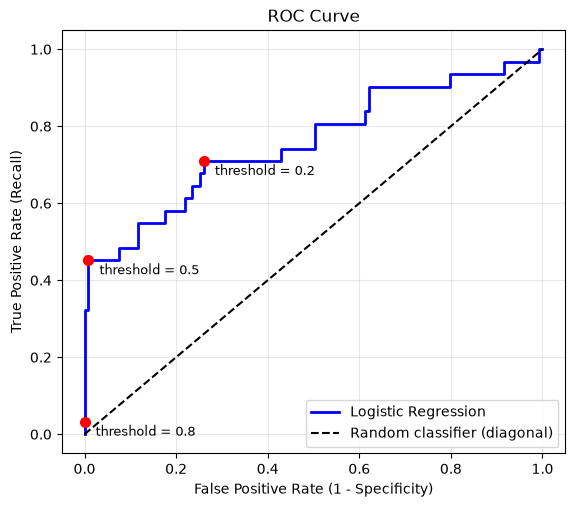

In [14]:
# --- ROC curve ---
from sklearn.metrics import roc_curve

# Fresh model so this cell runs standalone
X, y = make_classification(n_samples=500, n_features=5, n_informative=4, n_redundant=0,
                           weights=[0.8, 0.2], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
model = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(6.5, 5.5))
plt.plot(fpr, tpr, "b-", linewidth=2, label="Logistic Regression")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier (diagonal)")

# Mark a few operating points (thresholds) on the curve
for t in [0.2, 0.5, 0.8]:
    idx = int(np.argmin(np.abs(thresholds - t)))
    plt.plot(fpr[idx], tpr[idx], "ro", markersize=7)
    plt.annotate(f"threshold = {t}", (fpr[idx], tpr[idx]),
                 textcoords="offset points", xytext=(8, -10), fontsize=9)

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**What did we learn from this output?**

The curve starts at (0, 0) — a threshold so high that nothing is flagged (no positives
found, no false alarms) — and ends at (1, 1) — a threshold so low that everything is
flagged (all positives found, all negatives flagged too). The red dots show three
specific operating thresholds: 0.8 is conservative (high up-left), 0.2 is aggressive
(low down-right). The whole curve is the collection of *every* possible trade-off.

**What would this mean in a real-world application?**

A bank choosing where to operate picks a *point on the curve*, not the whole curve. If
they choose the 0.2 point, they catch more fraud but must investigate many more false
alarms. The curve tells you *what trade-offs exist*; only the cost analysis tells you
*which one to pick*.

---

#### Beginner Perspective

*ROC plots recall (TPR) against the false alarm rate (FPR) for every possible threshold.
Above the diagonal = better than random. Farther up-left = better discrimination.*

#### Expert Perspective

*ROC curves are threshold-independent summaries of ranking ability, and are robust to
class imbalance in a specific sense (they do not change when the prevalence changes).
But on heavily imbalanced data they can look optimistic, because the FPR denominator (TN)
is huge — see the ROC vs PR comparison in Section 12.*

---

[⬅ Previous](#sec9) · [🏠 Table of Contents](#toc) · [Next ➡](#sec11)

📗 **Back to basics:** see **Section 9: ROC Curve and AUC** in
`ML_Model_Evaluation_Simple.ipynb` — the ROC curve and AUC on the same fraud dataset,
without the deeper math.


<a id="sec11"></a>
## 11. AUC — Area Under the ROC Curve

### A. Simple Definition

**AUC** (Area Under the ROC Curve) is a single number summarizing the whole ROC curve:
the area beneath it, ranging from 0 to 1.

### B. Intuition — the rank interpretation

AUC answers: *"if I pick one random positive and one random negative, how often does the
model give the positive the higher score?"* It measures how well the model **separates**
positive from negative cases in its ranking — its **discrimination** ability — across all
thresholds at once.

### C. Interpretation of values

| AUC | Meaning |
|---|---|
| **1.0** | Perfect ranking: every positive is scored above every negative |
| **0.5** | Random ranking: no better than a coin flip |
| **< 0.5** | Worse than random — you could flip the predictions and do better |
| **0.7–0.8** | Usually considered "acceptable" discrimination |
| **0.9+** | Usually considered "excellent" discrimination |

### D. Advantages

- A single number, easy to compare models.
- Threshold-independent: describes the model's ranking ability without committing to a
  specific operating point.
- Widely used and understood.

### E. Limitations — the part students often miss

1. **AUC does not tell you which threshold to deploy.** Two models with AUC 0.9 can
   require completely different thresholds to achieve the same recall; the curve does not
   name your operating point.
2. **On imbalanced data, AUC can look optimistically high** (see Section 12).
3. **AUC hides where errors happen** — two very different curves can have the same area
   (one good at low FPR, the other at high FPR), and those are different business
   situations.
4. **AUC is a ranking measure, not a calibration measure.** A model can rank perfectly
   while its probabilities are systematically wrong — which matters when the *probability*
   itself drives a decision (e.g., loan pricing). (We evaluate this in Section 13.)

> **Key message:** AUC summarizes *ranking/discrimination* performance across thresholds,
> but it does NOT automatically tell us which threshold is appropriate for deployment.


In [15]:
# --- Computing AUC in Python ---
from sklearn.metrics import roc_auc_score

# Reuse the model from the ROC section
fpr, tpr, _ = roc_curve(y_test, probs)
auc_value = roc_auc_score(y_test, probs)
print(f"ROC-AUC = {auc_value:.3f}")

# Sanity-check the extremes with synthetic scores
rng = np.random.RandomState(0)
y = np.array([1] * 500 + [0] * 500)

# Perfect separation: every positive scored above every negative -> AUC = 1.0
perfect_scores = np.concatenate([np.ones(500) * 0.99, np.ones(500) * 0.01])

# Random scores: shuffle the perfect scores so there is NO relationship with the
# label -> AUC should come out very close to 0.5
random_scores = rng.permutation(perfect_scores)

# Reversed scores: perfect in the WRONG direction -> AUC = 0.0
reversed_scores = np.concatenate([np.ones(500) * 0.01, np.ones(500) * 0.99])

print(f"AUC with perfect ranking      = {roc_auc_score(y, perfect_scores):.3f}")
print(f"AUC with random scores        = {roc_auc_score(y, random_scores):.3f}")
print(f"AUC with reversed ranking     = {roc_auc_score(y, reversed_scores):.3f}")

ROC-AUC = 0.758
AUC with perfect ranking      = 1.000
AUC with random scores        = 0.514
AUC with reversed ranking     = 0.000


**What did we learn from this output?**

The real model scores an AUC of about 0.9x — meaning a random positive is scored above a
random negative about 90% of the time. The extremes behave as expected: perfect ranking
→ 1.0, random → ~0.5, reversed → 0.0. Note that a "reversed" model (AUC < 0.5) is not
useless — it is a signal that you should invert your predictions or debug your labels.

**What would this mean in a real-world application?**

If a fraud model has AUC 0.9, it ranks frauds above legitimate transactions very
reliably — but the bank still has to pick a threshold to decide *which transactions to
block*. AUC describes the model; the threshold, the costs, and the operational capacity
describe the decision.

---

#### Beginner Perspective

*AUC = "how well does the model separate the two classes across all thresholds?" 0.5 is
random, 1.0 is perfect. Higher is better — but it is not the whole story.*

#### Expert Perspective

*Experts remember AUC is a *relative ranking* measure: it cannot be compared across
datasets with different difficulty or prevalence, it rewards no absolute probability
accuracy, and on rare-event problems PR-AUC (next section) is usually the more honest
summary. They also compare models on the region of the ROC curve where the business will
actually operate, not on the full area.*

---

[⬅ Previous](#sec10) · [🏠 Table of Contents](#toc) · [Next ➡](#sec12)

📗 **Back to basics:** see **Section 9: ROC Curve and AUC** in
`ML_Model_Evaluation_Simple.ipynb` — AUC as “the model ranks positives above
negatives”, in one short paragraph.


<a id="sec12"></a>
## 12. ROC-AUC vs Precision–Recall

### Why can't we just use ROC-AUC for everything?

The ROC curve plots TPR against FPR. FPR = FP / (FP + TN) — its denominator includes all
actual negatives, which on imbalanced data is a **huge** number. A model can therefore
achieve a very low FPR (and a high ROC-AUC) even while producing *many* false positives in
absolute terms, simply because the negative class is enormous. ROC-AUC looks at the
problem from the majority class's perspective.

The **Precision–Recall (PR) curve** plots precision against recall and focuses directly
on the **minority (positive) class**:

- **Precision** = TP / (TP + FP) — how many flagged cases are real
- **Recall** = TP / (TP + FN) — how many real positives are found

On imbalanced data, the PR curve is more informative about *how useful the model is for
finding the rare event*, because it punishes false positives directly.

### The comparison table

| Metric | What it tells us | Strength | Limitation | Useful scenario |
|---|---|---|---|---|
| **ROC-AUC** | Overall ranking quality across all thresholds | Threshold-independent, prevalence-invariant, standard | Optimistic on imbalanced data; hides operating point | Balanced data, model comparison, ranking ability |
| **Precision–Recall curve** | Precision at every recall level | Directly measures usefulness for the rare positive class | Sensitive to prevalence (can't compare across datasets) | Rare-event detection: fraud, disease, intrusion |
| **PR-AUC** | Single summary of the PR curve | Captures the FP burden on the minority-class problem | Harder to explain; needs prevalence context | Comparing models on imbalanced data |

### The business example

A fraud team wants to know: *"if we act on the top 10% of suspicious transactions, how
many will be real frauds?"* — that is a precision question, read off the PR curve. The ROC
curve cannot answer it directly, because its axes are about *rates* within each class, not
about the actual composition of the flagged set.

Let's demonstrate with two synthetic models that have **almost identical ROC-AUC but very
different PR-AUC**.


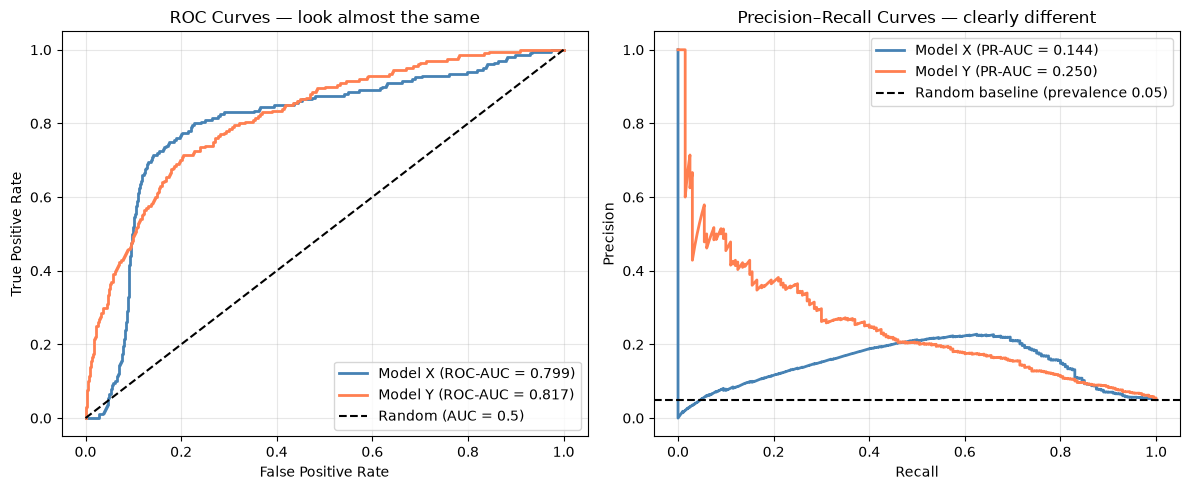

Model X: ROC-AUC = 0.799   PR-AUC = 0.144
Model Y: ROC-AUC = 0.817   PR-AUC = 0.250


In [16]:
# --- ROC-AUC vs PR-AUC on an imbalanced problem ---
from sklearn.metrics import precision_recall_curve, average_precision_score

rng = np.random.RandomState(7)
n_pos, n_neg = 200, 3800                      # 5% positive class (rare event)
y = np.array([1] * n_pos + [0] * n_neg)

# Model X: decent separation, but 10% of negatives form a high-scoring "borderline"
# cluster that produces many false alarms -> good ranking, bad precision
scores_x = np.concatenate([
    rng.normal(1.0, 0.6, n_pos),                     # positives
    rng.normal(0.2, 0.3, int(0.90 * n_neg)),         # most negatives, low scores
    rng.normal(2.0, 0.7, n_neg - int(0.90 * n_neg))  # a cluster of false-alarm-prone negatives
])

# Model Y: same kind of separation, but negatives spread far below the positives
scores_y = np.concatenate([
    rng.normal(1.6, 0.9, n_pos),
    rng.normal(0.3, 0.95, n_neg)
])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for scores, color, name in [(scores_x, "steelblue", "Model X"),
                            (scores_y, "coral", "Model Y")]:
    # ROC curve + AUC
    fpr, tpr, _ = roc_curve(y, scores)
    auc_roc = roc_auc_score(y, scores)
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{name} (ROC-AUC = {auc_roc:.3f})")

    # PR curve + PR-AUC
    precision, recall, _ = precision_recall_curve(y, scores)
    auc_pr = average_precision_score(y, scores)
    axes[1].plot(recall, precision, color=color, linewidth=2,
                 label=f"{name} (PR-AUC = {auc_pr:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — look almost the same")
axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

# A random classifier's PR baseline on imbalanced data is the prevalence (0.05)
axes[1].axhline(0.05, color="k", linestyle="--", label="Random baseline (prevalence 0.05)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall Curves — clearly different")
axes[1].legend(loc="upper right"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

roc_x = roc_auc_score(y, scores_x); roc_y = roc_auc_score(y, scores_y)
ap_x = average_precision_score(y, scores_x); ap_y = average_precision_score(y, scores_y)
print(f"Model X: ROC-AUC = {roc_x:.3f}   PR-AUC = {ap_x:.3f}")
print(f"Model Y: ROC-AUC = {roc_y:.3f}   PR-AUC = {ap_y:.3f}")

**What did we learn from this output?**

The two ROC curves are nearly indistinguishable (ROC-AUC ≈ 0.80 vs ≈ 0.82). Judging by
ROC-AUC alone, you might call the models equivalent. But the PR curves tell a different
story: Model Y's PR-AUC is almost **twice** Model X's (≈ 0.25 vs ≈ 0.14). Model X looks
fine by ROC, yet in practice it would flood the fraud team with false positives.

**What would this mean in a real-world application?**

A fraud detection team that compares these models on ROC-AUC might deploy Model X and then
discover in production that most of its alerts are false alarms. Comparing on PR-AUC (or
on precision at the operating recall) reveals the truth: Model Y is the better tool for
finding the rare frauds. **On imbalanced problems, prefer PR curves for decision-making.**

> Rule of thumb: use **ROC-AUC** for overall ranking quality and balanced data; use
> **PR-AUC / PR curves** when the positive class is rare and false positives are costly.

---


### Interactive explorer: one model, two curves, one operating point 🎛️

The curves above are two views of the *same* model. The widget below fits a fresh
logistic-regression model on a synthetic **fraud-detection dataset (5% fraud)** and lets
you drag the threshold. Watch how **one operating point** moves along *both* curves at
once:

- **Left panel:** precision, recall, and F1 as functions of the threshold.
- **Middle panel:** the ROC curve — the operating point shows the recall (TPR) you get
  at the current false-positive rate.
- **Right panel:** the PR curve — the operating point shows the precision you get at the
  current recall, compared with the random baseline (the fraud rate, 0.05).

Experiments to try:

1. Start at threshold **0.9** (very strict) and drag down to **0.1**. Watch recall climb
   along the ROC curve while precision collapses on the PR curve.
2. Find where **F1 is highest** — is that the point you would actually deploy for fraud
   detection? (Think about the cost of each false alarm!)
3. Notice that the ROC curve stays high even when precision is terrible — the ROC view
   makes this model look better than the PR view does. Which curve do you trust when
   only 5% of transactions are fraud?


In [17]:
# --- Interactive: threshold sweep on the ROC and PR curves (fraud detection) ---
# Self-contained cell: builds a small synthetic fraud dataset + logistic regression here,
# so it works even if run on its own after a kernel restart.
from sklearn.linear_model import LogisticRegression

X_f, y_f = make_classification(n_samples=1500, n_features=6, n_informative=5, n_redundant=0,
                               weights=[0.95, 0.05], flip_y=0.02, random_state=42)
X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(
    X_f, y_f, test_size=0.3, random_state=42, stratify=y_f)

fraud_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_f_train, y_f_train)
fraud_probs = fraud_model.predict_proba(X_f_test)[:, 1]


# One threshold -> (precision, recall, f1, fpr, and the four confusion-matrix counts)
def curve_point(y_true, y_prob, t):
    preds = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn)
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return prec, rec, f1, fpr, tn, fp, fn, tp


# Precompute the three curves on a fine grid of thresholds (0.01 ... 0.99)
grid = np.arange(0.01, 1.00, 0.01)
prec_grid, rec_grid, f1_grid, fpr_grid = [], [], [], []
for t in grid:
    prec, rec, f1, fpr, *_ = curve_point(y_f_test, fraud_probs, t)
    prec_grid.append(prec); rec_grid.append(rec)
    f1_grid.append(f1);   fpr_grid.append(fpr)


try:
    import ipywidgets as widgets
    from IPython.display import display

    def sweep(threshold):
        # Exact values at the current slider position
        prec, rec, f1, fpr, tn, fp, fn, tp = curve_point(y_f_test, fraud_probs, threshold)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

        # Left: precision / recall / F1 vs threshold, with the current point marked
        axes[0].plot(grid, prec_grid, label="Precision", color="steelblue")
        axes[0].plot(grid, rec_grid, label="Recall", color="coral")
        axes[0].plot(grid, f1_grid, label="F1", color="seagreen")
        axes[0].axvline(threshold, color="gray", linestyle="--", alpha=0.8)
        axes[0].plot(threshold, prec, "o", color="steelblue")
        axes[0].plot(threshold, rec, "o", color="coral")
        axes[0].plot(threshold, f1, "o", color="seagreen")
        axes[0].set_xlabel("Classification threshold"); axes[0].set_ylabel("Score")
        axes[0].set_title("Precision, Recall, F1 vs threshold")
        axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

        # Middle: ROC curve with the operating point (FPR, TPR)
        axes[1].plot(fpr_grid, rec_grid, color="steelblue", label="ROC curve")
        axes[1].plot([0, 1], [0, 1], "k--", alpha=0.6, label="Random (AUC = 0.5)")
        axes[1].plot(fpr, rec, "o", color="coral", markersize=10)
        axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate (Recall)")
        axes[1].set_title("ROC curve — operating point")
        axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

        # Right: PR curve with the operating point (Recall, Precision) + random baseline
        axes[2].plot(rec_grid, prec_grid, color="steelblue", label="PR curve")
        axes[2].axhline(0.05, color="k", linestyle="--", alpha=0.6, label="Random (prevalence 0.05)")
        axes[2].plot(rec, prec, "o", color="coral", markersize=10)
        axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
        axes[2].set_title("Precision–Recall curve — operating point")
        axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(f"threshold = {threshold:.2f}  |  TP = {tp}  FP = {fp}  FN = {fn}  TN = {tn}")
        print(f"Precision = {prec:.3f}   Recall = {rec:.3f}   F1 = {f1:.3f}")

    slider = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.01,
                                 description="Threshold:", readout_format=".2f")
    out = widgets.interactive_output(sweep, {"threshold": slider})
    with out:
        sweep(0.5)   # embed a static snapshot of the initial view
    display(widgets.VBox([slider, out]))
    print("✅ Drag the threshold and watch the operating point move along both curves.")

except ImportError:
    print("ipywidgets is not installed, so the interactive slider is unavailable.")
    print("Install it with:  pip install ipywidgets   (then restart the kernel and re-run this cell).")
    print("Until then, use the static curves in Section 9 and this section: pick a threshold and trace it on both curves.")

✅ Drag the threshold and watch the operating point move along both curves.


#### Beginner Perspective

*On imbalanced data, ROC can look great while the model is actually poor at finding the
rare class. PR curves focus on the class you care about — check both, trust PR for
rare-event problems.*

#### Expert Perspective

*Experts treat ROC-AUC and PR-AUC as answers to different questions (ranking vs
usefulness for the minority class) and know PR-AUC is prevalence-dependent, so it cannot
be compared across datasets with different base rates. They often skip the summary
entirely and evaluate precision at the *specific* recall (or business cost) they intend
to operate at.*

---

[⬅ Previous](#sec11) · [🏠 Table of Contents](#toc) · [Next ➡](#sec13)

📗 **Back to basics:** only here in depth — the nearest basic material is
**Section 9: ROC Curve and AUC** in `ML_Model_Evaluation_Simple.ipynb`, whose caveat
explains why a precision–recall curve is more informative for rare events.


<a id="sec13"></a>
## 13. Probability Calibration

### A. Simple Definition

Calibration answers one question:

> **"When the model says '70%', is it right 70% of the time?"**

A predicted probability of 0.70 should mean what it says: if we collect all the cases
where the model predicted 0.70, about 70% of them should actually be positive.

### B. Intuition — the weather forecast

A weather app says "30% chance of rain". If, over a year, it rains on about 3 out of
every 10 days that the app rated 30%, the forecast is **well calibrated**. If it only
rains on 1 of those days, the app is **overconfident** — the number 0.30 did not mean
what it claimed. The same logic applies to fraud, disease, and default probabilities.

### C. Ranking vs calibration — two different things

- **Ranking** (what AUC measures, Section 11): does the model put the positives above
  the negatives? Only the *order* of the scores matters.
- **Calibration** (this section): do the *absolute values* of the scores match reality?

**A model can rank perfectly and still be badly miscalibrated.** Imagine a model whose
scores are all inflated: true probabilities of 0.1, 0.4, 0.6, 0.9 come out as 0.5, 0.8,
0.9, 0.99. The order is preserved — the AUC is identical to a perfectly calibrated
model's — but every number overstates the true risk. If the business *uses the number*
to price a loan, set an insurance premium, or decide how urgently to act, miscalibration
means systematically wrong decisions.

### D. Why do models become miscalibrated?

1. Most training objectives optimize ranking or accuracy, not the truth of the
   probabilities themselves.
2. Different model families have very different natural calibration:
   - **Logistic regression** is usually well calibrated — it is explicitly a
     probabilistic model.
   - **Random forests / decision trees** tend to be **overconfident**: their
     probabilities bunch up near 0 and 1 (leaves become "pure", so the model claims 90%
     or 100% where reality is closer to 70%).
   - **Deep neural networks** are often overconfident too (well known from
     adversarial-example research).
3. Class imbalance, regularization, and class weights distort probabilities further.

### E. How to check: the reliability diagram

A **reliability diagram** (also called a calibration curve) is built like this:

1. Collect all predicted probabilities.
2. Split them into **bins** (e.g., deciles: 0–0.1, 0.1–0.2, ..., 0.9–1.0).
3. For each bin, compute the **mean predicted probability** and the **observed
   frequency** of positives.
4. Plot observed frequency (y-axis) against mean predicted probability (x-axis).

- **On the diagonal** → perfectly calibrated.
- **Below the diagonal** → overconfident: the model says higher than reality.
- **Above the diagonal** → underconfident: the model says lower than reality.

Let's see the difference with real models.


Model                   AUC (ranking)    Brier (probabilities)
Logistic Regression             0.949                    0.091
Random Forest                   0.934                    0.101


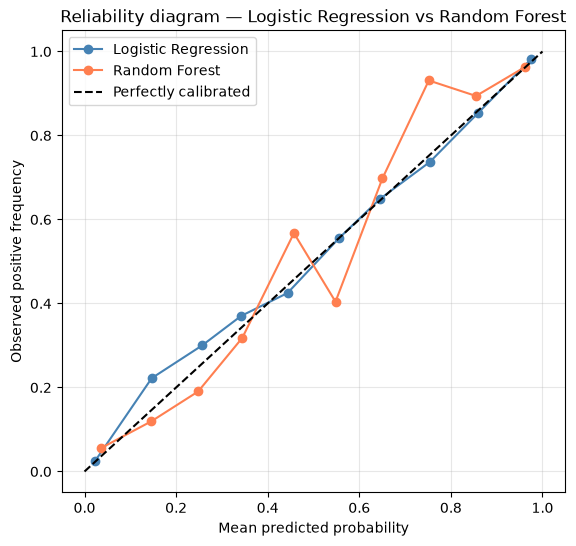

In [18]:
# --- Calibration: two models with similar AUC, very different probabilities ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve

# Synthetic data generated from a KNOWN linear model, so we know the true
# probabilities and can check whether each model's numbers are truthful.
rng = np.random.RandomState(21)
n, d = 3000, 5
X = rng.normal(0, 1, (n, d))
w_true = np.array([3.0, 2.25, 1.5, 0.75, 0.45])
p_true = 1 / (1 + np.exp(-(X @ w_true)))      # the true probabilities (linear logit)
y = (rng.rand(n) < p_true).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=21, stratify=y)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=21),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=21),
}
fitted_cal, probs_cal = {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_cal[name] = model
    probs_cal[name] = model.predict_proba(X_test)[:, 1]

print(f"{'Model':22s} {'AUC (ranking)':>14s} {'Brier (probabilities)':>24s}")
for name in models:
    auc = roc_auc_score(y_test, probs_cal[name])
    brier = np.mean((probs_cal[name] - y_test) ** 2)   # the Brier score, computed by hand
    print(f"{name:22s} {auc:>14.3f} {brier:>24.3f}")

# Reliability diagram: observed frequency vs mean predicted probability, per bin
fig, ax = plt.subplots(figsize=(6.5, 6))
for name, color in [("Logistic Regression", "steelblue"), ("Random Forest", "coral")]:
    frac_pos, mean_pred = calibration_curve(y_test, probs_cal[name], n_bins=10)
    ax.plot(mean_pred, frac_pos, "o-", color=color, label=name)
ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed positive frequency")
ax.set_title("Reliability diagram — Logistic Regression vs Random Forest")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### F. Quantitative measures

**Brier score** — the mean squared error of the probabilities:

$$\text{Brier} = \frac{1}{n} \sum_{i=1}^{n} (p_i - y_i)^2$$

- $p_i$ = predicted probability, $y_i$ = true label (0 or 1).
- Lower is better: 0 = perfect, 0.25 = always predicting 0.5, 1 = always wrong.
- It rewards both good calibration *and* confident, correct predictions.

**Expected Calibration Error (ECE)** — the average gap between predicted and observed
probability, weighted by bin size:

$$\text{ECE} = \sum_{k=1}^{K} \frac{|B_k|}{n} \cdot |\text{observed}_k - \text{predicted}_k|$$

- $K$ = number of bins, $|B_k|$ = number of samples in bin $k$.
- Lower is better; 0 = perfectly calibrated on average.

### G. Business impact

| Situation | What miscalibration does |
|---|---|
| Bank prices a loan from P(default) | Underpriced risk → losses accumulate silently |
| Insurance premium set from P(claim) | Wrong premiums → adverse selection |
| Medical triage from P(disease) | A patient with true 60% risk is treated as if it were 20% |
| Any expected-value calculation | Every downstream number is off by the same systematic amount |

Calibration matters less when the business only uses the **order** of the scores (e.g.,
"investigate the top 10% of transactions") — that is a ranking use. It matters *most*
when the probability value itself drives a decision or a price.

### H. When calibration matters — and when it does not

**It matters when:** the probability is used as a number — pricing, risk and
expected-value calculations, thresholds chosen as "approve if p ≥ 0.5" (with a
miscalibrated model that threshold means nothing, which connects directly to the
threshold discussion in Section 9), medical and safety decisions.

**It matters less when:** the task is pure ranking (recommendations, search, "which 10%
should we review?") and when comparing models with AUC, which deliberately ignores
absolute values.

### I. Can we fix it?

Yes — **recalibration** fits a second model on top of the raw probabilities, using data
the original model never saw: **Platt scaling** (a logistic regression on the
probabilities) or **isotonic regression** (a monotone, non-parametric fit). scikit-learn
provides `CalibratedClassifierCV`. The next cell shows the fix in action — and the
data-leakage trap that comes with it (Section 18).


Expected Calibration Error (by hand, 10 bins):
  Logistic Regression    ECE = 0.013
  Random Forest          ECE = 0.042



Random Forest          raw:  AUC = 0.934  Brier = 0.101  ECE = 0.042
Random Forest  recalibrated:  AUC = 0.937  Brier = 0.098  ECE = 0.030


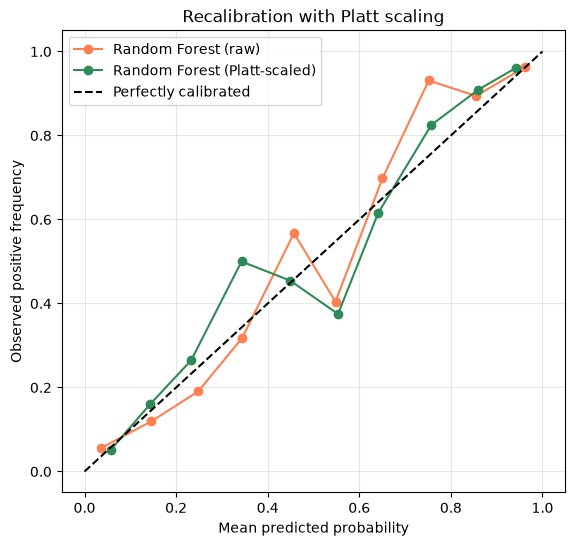

In [19]:
# --- ECE by hand, and fixing calibration with Platt scaling ---
from sklearn.calibration import CalibratedClassifierCV

def ece(y_true, y_prob, n_bins=10):
    # Expected Calibration Error, computed bin by bin
    bins = np.linspace(0, 1, n_bins + 1)
    total, n = 0.0, len(y_true)
    for i in range(n_bins):
        mask = (y_prob > bins[i]) & (y_prob <= bins[i + 1])
        if mask.sum() == 0:
            continue
        pred = y_prob[mask].mean()      # mean predicted probability in the bin
        obs = y_true[mask].mean()       # observed positive frequency in the bin
        total += (mask.sum() / n) * abs(obs - pred)
    return total

print("Expected Calibration Error (by hand, 10 bins):")
for name in models:
    print(f"  {name:22s} ECE = {ece(y_test, probs_cal[name]):.3f}")

# Recalibrate the Random Forest with Platt scaling (sigmoid), fit by cross-validation
# on the TRAINING data only — never on the test set (that would be data leakage).
cal_rf = CalibratedClassifierCV(RandomForestClassifier(n_estimators=200, random_state=21),
                                method="sigmoid", cv=3)
cal_rf.fit(X_train, y_train)
probs_cal_rf = cal_rf.predict_proba(X_test)[:, 1]

p_raw = probs_cal["Random Forest"]
print("\nRandom Forest          raw:  AUC = %.3f  Brier = %.3f  ECE = %.3f"
      % (roc_auc_score(y_test, p_raw), np.mean((p_raw - y_test) ** 2), ece(y_test, p_raw)))
print("Random Forest  recalibrated:  AUC = %.3f  Brier = %.3f  ECE = %.3f"
      % (roc_auc_score(y_test, probs_cal_rf), np.mean((probs_cal_rf - y_test) ** 2),
         ece(y_test, probs_cal_rf)))

# The fix, shown on the reliability diagram
fig, ax = plt.subplots(figsize=(6.5, 6))
frac_pos, mean_pred = calibration_curve(y_test, p_raw, n_bins=10)
ax.plot(mean_pred, frac_pos, "o-", color="coral", label="Random Forest (raw)")
frac_pos, mean_pred = calibration_curve(y_test, probs_cal_rf, n_bins=10)
ax.plot(mean_pred, frac_pos, "o-", color="seagreen", label="Random Forest (Platt-scaled)")
ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed positive frequency")
ax.set_title("Recalibration with Platt scaling")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### Interactive calibration lab: watch overconfidence happen 🎛️

This widget turns the section's ideas into knobs you can drag:

- **Overconfidence slider (k):** distorts the Logistic Regression's well-calibrated
  probabilities. k = 1 leaves them honest; k > 1 pushes them toward 0 and 1
  (overconfident); k < 1 flattens them toward 0.5 (underconfident).
- **Platt scaling toggle:** refits a sigmoid calibration on the distorted
  probabilities (training data only) and shows the curve pulled back toward the
  diagonal.

Watch the three things that matter:

1. **AUC does not move** when you change k — the distortion changes the *values* but
   never the *order*, so ranking (Section 11) is untouched while calibration collapses.
   This is the ranking-vs-calibration distinction made visible.
2. **Brier and ECE climb** as k moves away from 1 — the probabilities become
   systematically wrong, in both directions: over-confidence and under-confidence.
3. **Toggle Platt scaling on** (try k = 3) and watch the curve return toward the
   diagonal while AUC stays the same — you fixed the numbers without touching the
   ranking. (At k = 1 the model is already honest, so there is nothing to fix — and the
   unnecessary correction even hurts slightly.)


In [20]:
# --- Interactive calibration lab: overconfidence slider + Platt scaling toggle ---
# Self-contained: rebuilds the same known-truth dataset and Logistic Regression as the
# rest of this section, so the cell also works after a kernel restart.
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

rng = np.random.RandomState(21)
n, d = 3000, 5
X = rng.normal(0, 1, (n, d))
w_true = np.array([3.0, 2.25, 1.5, 0.75, 0.45])
p_true = 1 / (1 + np.exp(-(X @ w_true)))
y = (rng.rand(n) < p_true).astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=21, stratify=y)

lr = LogisticRegression(max_iter=1000, random_state=21).fit(X_train, y_train)
p_tr = lr.predict_proba(X_train)[:, 1]
p_te = lr.predict_proba(X_test)[:, 1]


def ece(y_true, y_prob, n_bins=10):
    # Expected Calibration Error, computed bin by bin
    bins = np.linspace(0, 1, n_bins + 1)
    total, n = 0.0, len(y_true)
    for i in range(n_bins):
        mask = (y_prob > bins[i]) & (y_prob <= bins[i + 1])
        if mask.sum() == 0:
            continue
        total += (mask.sum() / n) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return total


def distort(p, k):
    # Monotone "overconfidence" transform: k = 1 keeps p unchanged, k > 1 pushes
    # probabilities toward 0 and 1, k < 1 pulls them toward 0.5. The ranking never
    # changes, so AUC is unaffected by construction.
    logit_p = np.log(np.clip(p, 1e-6, 1 - 1e-6) / (1 - np.clip(p, 1e-6, 1 - 1e-6)))
    return 1 / (1 + np.exp(-k * logit_p))


try:
    import ipywidgets as widgets
    from IPython.display import display

    def view(k, platt_on):
        dist_train = distort(p_tr, k)
        dist_test = distort(p_te, k)

        if platt_on:
            # Platt scaling: fit a sigmoid on the (distorted) TRAINING probabilities
            platt = LogisticRegression(max_iter=1000, random_state=0)
            platt.fit(dist_train.reshape(-1, 1), y_train)
            fixed_test = platt.predict_proba(dist_test.reshape(-1, 1))[:, 1]
        else:
            fixed_test = None

        auc_val = roc_auc_score(y_test, dist_test)          # unchanged by k, by construction
        brier = np.mean((dist_test - y_test) ** 2)
        ece_val = ece(y_test, dist_test)

        fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

        # Left: reliability diagram
        if platt_on:
            frac, pred = calibration_curve(y_test, dist_test, n_bins=10)
            axes[0].plot(pred, frac, "o-", color="coral", alpha=0.6,
                         label=f"Distorted (k = {k:.1f})")
            frac, pred = calibration_curve(y_test, fixed_test, n_bins=10)
            axes[0].plot(pred, frac, "o-", color="seagreen", label="After Platt scaling")
        else:
            frac, pred = calibration_curve(y_test, dist_test, n_bins=10)
            axes[0].plot(pred, frac, "o-", color="steelblue", label=f"Distorted (k = {k:.1f})")
        axes[0].plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
        axes[0].set_xlabel("Mean predicted probability")
        axes[0].set_ylabel("Observed positive frequency")
        axes[0].set_title("Reliability diagram")
        axes[0].legend(fontsize=8)
        axes[0].grid(alpha=0.3)

        # Right: Brier and ECE bars (with and without the fix)
        if platt_on:
            brier_fix = np.mean((fixed_test - y_test) ** 2)
            ece_fix = ece(y_test, fixed_test)
            x = np.arange(2)
            w = 0.35
            axes[1].bar(x - w / 2, [brier, ece_val], w, color="coral", label="Distorted")
            axes[1].bar(x + w / 2, [brier_fix, ece_fix], w, color="seagreen", label="Platt-fixed")
            axes[1].set_xticks(x)
            axes[1].set_xticklabels(["Brier", "ECE"])
            axes[1].legend(fontsize=8)
        else:
            axes[1].bar(["Brier", "ECE"], [brier, ece_val], color="steelblue")
        axes[1].set_title("Calibration errors")
        axes[1].grid(axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(f"k = {k:.1f}  |  AUC = {auc_val:.3f} (unchanged by k)  |  Brier = {brier:.3f}  ECE = {ece_val:.3f}")
        if platt_on:
            print(f"After Platt scaling:  Brier = {brier_fix:.3f}  ECE = {ece_fix:.3f}")

    slider_k = widgets.FloatSlider(value=1.0, min=0.3, max=5.0, step=0.1,
                                   description="Overconfidence k:", readout_format=".1f")
    toggle = widgets.ToggleButton(value=False, description="Apply Platt scaling")

    out = widgets.interactive_output(view, {"k": slider_k, "platt_on": toggle})
    with out:
        view(1.0, False)   # embed a static snapshot of the initial view
    display(widgets.VBox([slider_k, toggle, out]))
    print("✅ Move the slider and toggle Platt scaling — AUC stays fixed while Brier and ECE move.")

except ImportError:
    print("ipywidgets is not installed, so the interactive lab is unavailable.")
    print("Install it with:  pip install ipywidgets   (then restart the kernel and re-run this cell).")
    print("Until then, the static experiments in the two code cells above demonstrate the same ideas.")

✅ Move the slider and toggle Platt scaling — AUC stays fixed while Brier and ECE move.


**What did we learn from these outputs — and from playing with the interactive lab above?**

The two models have very similar AUC — they rank almost identically. But their Brier
scores and ECE values are very different, and the reliability diagram shows why: the
Random Forest's curve bulges away from the diagonal (it says "90%" where reality is
closer to "70%"), while the Logistic Regression hugs it. After Platt scaling, the Random
Forest's curve moves back toward the diagonal: ECE drops noticeably and Brier improves
a little, while AUC stays essentially unchanged — calibration improved without losing
discrimination.

**What would this mean in a real-world application?**

A bank that used the raw Random Forest's probabilities to price loans would
systematically underprice risk: it believes defaults are rarer than they are. Its AUC
looked fine — the ranking was good — but the *numbers* were wrong, and the numbers are
exactly what the pricing formula uses. Recalibration fixes the numbers. And note the
critical detail: the recalibration was fit with cross-validation on the *training* data
— fitting it on the test set would have been data leakage (Section 18), and the
improvement would have been an illusion.

---

#### Beginner Perspective

*A high AUC does not mean the probabilities are meaningful. If you will use the
probability number itself (pricing, risk, triage), check calibration with a reliability
diagram and a Brier score.*

#### Expert Perspective

*Experts separate three properties of probabilities: calibration (absolute accuracy),
sharpness (concentration near 0 and 1), and discrimination (ranking). The Brier score
bundles calibration and sharpness; ECE isolates calibration. They also check calibration
per subgroup (customer segment, region, model version) — a model can be well calibrated
overall yet badly calibrated for the very group a decision affects. And they remember
that recalibration must always be fit on held-out data, ideally inside cross-validation.*

---

[⬅ Previous](#sec12) · [🏠 Table of Contents](#toc) · [Next ➡](#sec14)

📗 **Back to basics:** only here in depth — the nearest basic material is
**Section 8: The Precision–Recall Trade-off** in `ML_Model_Evaluation_Simple.ipynb`,
which introduces probabilities and thresholds.


<a id="sec14"></a>
## 14. The Classification Report

The classification report is a compact table that prints precision, recall, F1, and
support **for every class**, plus aggregated averages.

### Reading the report — line by line

For a binary problem, scikit-learn prints one row per class and three extra rows:
**macro avg**, **weighted avg** (and for multiclass, **micro avg** appears in the
`accuracy` line).

| Row | Meaning |
|---|---|
| `precision` | Precision for this class, treating it as "positive" |
| `recall` | Recall for this class, treating it as "positive" |
| `f1-score` | F1 for this class |
| `support` | Number of **actual** samples of this class in the test set |
| `macro avg` | **Unweighted** average of the per-class scores — every class counts equally, regardless of size |
| `weighted avg` | Average of the per-class scores **weighted by support** — bigger classes dominate |
| `micro avg` | Pool all predictions into one big confusion matrix (for multiclass this equals accuracy) |

**Why do the averages matter?** On imbalanced data, the *weighted* average can look great
simply because the majority class is easy, while the *macro* average honestly reflects
that the minority class is handled badly. Always compare the two — a big gap between them
is a red flag.

> **A classification report should not be read mechanically.** Interpret the numbers
> according to the application. If the minority class row shows recall 0.10, no average
> in the world makes that acceptable for a disease-screening problem.


In [21]:
# --- Classification report ---
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

# Small imbalanced binary problem (self-contained cell)
X, y = make_classification(n_samples=800, n_features=8, n_informative=5, n_redundant=0,
                           weights=[0.9, 0.1], random_state=13)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=13, stratify=y)

clf = RandomForestClassifier(n_estimators=100, random_state=13).fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Negative (0)", "Positive (1)"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

Negative (0)       0.90      1.00      0.95       215
Positive (1)       1.00      0.04      0.08        25

    accuracy                           0.90       240
   macro avg       0.95      0.52      0.51       240
weighted avg       0.91      0.90      0.86       240

Confusion matrix:
 [[215   0]
 [ 24   1]]


**What did we learn from this output?**

Each row answers a question about one class: for the Positive class, precision says "of
the positives I predicted, how many were right?", recall says "of the actual positives,
how many did I find?". The `support` column tells you how many samples each row is based
on (here ~24 positives — a small number, so these metrics are noisy). The macro average
treats both classes equally; the weighted average is dragged toward the (larger) negative
class.

**What would this mean in a real-world application?**

If this were a disease-screening model, the row that matters is **Positive**:
*"out of every 100 sick patients, how many do we send home?"* A report that looks great in
the `weighted avg` row can still be unacceptable for the minority class — which is often
exactly the class the business cares about. This is why professionals read the per-class
rows, not just the averages.

---

#### Beginner Perspective

*Read each class row separately. Macro = every class equal; weighted = bigger classes
count more. Big gap between them = the model ignores the small class.*

#### Expert Perspective

*Experts read the report *per operating decision*: they check the class they will act on,
look at `support` to judge how reliable the numbers are, and treat macro/weighted as
diagnostics for class-imbalance blindness rather than as final scores. For multiclass
problems with different error costs per class (Section 16), they build a cost matrix
rather than averaging rows.*

---

[⬅ Previous](#sec12) · [🏠 Table of Contents](#toc) · [Next ➡](#sec15)

📗 **Back to basics:** see **Section 10: The Classification Report** in
`ML_Model_Evaluation_Simple.ipynb` — the same report on the same fraud model, read line
by line.


<a id="sec15"></a>
## 15. Imbalanced Datasets

### What is class imbalance?

A dataset is imbalanced when one class is much more common than the other. Real-world
examples: 0.1–2% of credit-card transactions are fraud; 0.5–5% of patients have a given
rare disease; a tiny fraction of network connections are attacks. The rare class is the
**minority class** — and it is almost always the class that matters.

### Why does accuracy fail here?

Because the majority class dominates the accuracy numerator. A model that predicts the
majority class for everything can reach 98–99% accuracy while doing **nothing**. The
accuracy number looks impressive; the model is useless. (We demonstrated this in
Section 4.)

### What should we use instead?

The tools for imbalanced problems are exactly the metrics we have built:

- **Precision** — when the model flags something, how often is it right? (FP control)
- **Recall** — how many of the rare positives do we find? (FN control)
- **F1** — balance of the two
- **ROC-AUC** — overall ranking quality (but optimistic, see Section 12)
- **PR-AUC** — usefulness for finding the rare class (preferred)

Let's build an imbalanced dataset, fit a real model, and compare it honestly against the
naive "always negative" baseline.


In [22]:
# --- Imbalanced dataset: real model vs "always negative" baseline ---
from sklearn.ensemble import RandomForestClassifier

# 2% positive class
X, y = make_classification(n_samples=2000, n_features=8, n_informative=5, n_redundant=0,
                           weights=[0.98, 0.02], random_state=14)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=14, stratify=y)

print("Class distribution in the test set:")
print(pd.Series(y_test).value_counts().sort_index(), "\n")

dummy_pred = np.zeros_like(y_test)   # the naive baseline: always predict majority class
rf = RandomForestClassifier(n_estimators=100, random_state=14).fit(X_train, y_train)
rf_pred = rf.predict(X_test)

summary = []
for name, pred in [("Always-negative (dummy)", dummy_pred), ("Random Forest", rf_pred)]:
    summary.append({
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall":    recall_score(y_test, pred, zero_division=0),
        "F1":        f1_score(y_test, pred, zero_division=0),
        "Frauds found": int((pred == 1).sum()),
    })

pd.DataFrame(summary, index=["Always-negative (dummy)", "Random Forest"]).round(3)

Class distribution in the test set:
0    584
1     16
Name: count, dtype: int64 



,Accuracy,Precision,Recall,F1,Frauds found
Always-negative (dummy),0.973,0.0,0.000,0.000,0
Random Forest,0.975,1.0,0.062,0.118,1


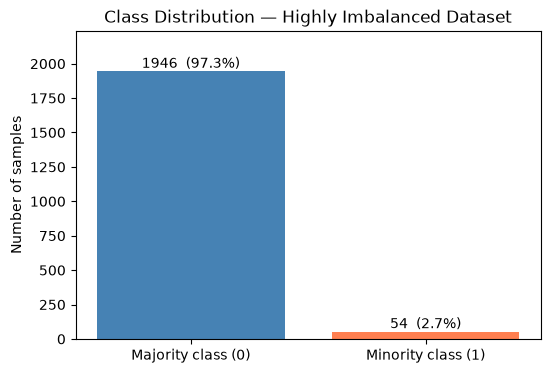

In [23]:
# --- Class distribution chart ---
counts = pd.Series(y).value_counts().sort_index()
plt.figure(figsize=(6, 4))
bars = plt.bar(["Majority class (0)", "Minority class (1)"], counts.values,
               color=["steelblue", "coral"])
for bar, v in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, v, f"{v}  ({v / len(y):.1%})",
             ha="center", va="bottom")
plt.title("Class Distribution — Highly Imbalanced Dataset")
plt.ylabel("Number of samples")
plt.ylim(0, counts.max() * 1.15)
plt.show()

**What did we learn from this output?**

The dummy model scores ~98% accuracy — yet catches **zero** frauds. The Random Forest has
lower accuracy but actually finds some frauds. If you compared these models on accuracy
alone, you would pick the *worse* one. This is the accuracy trap in action.

**What would this mean in a real-world application?**

For fraud, disease, or intrusion detection, the meaningful question is not "how often is
the model right overall?" but "how many of the rare, expensive events does it catch, and
at what cost in false alarms?" Those are precision/recall/PR questions.

### The key question — which model is better?

Consider two models for an imbalanced problem:

| Model | Accuracy | Precision | Recall |
|---|---|---|---|
| **A** | 98% | 95% | 15% |
| **B** | 95% | 60% | 80% |

**Which model is better?** Model A is "more accurate"; Model B finds far more positives.

**There is no answer without knowing the cost of FP and FN.**

- If a missed positive costs €10,000 and a false alarm costs €5 → **Model B** (find them
  all; the false alarms are cheap).
- If a false alarm costs €1,000 and a missed positive costs €10 → **Model A** (only act on
  high-confidence signals).
- If costs are unknown → compute F1 for each and use that as a starting balance — but
  remember F1 itself assumes symmetric costs.

This single idea — *the better model depends on error costs* — is the heart of this
notebook. The next sections (case studies, Sections 21–22) will make it concrete.

---

#### Beginner Perspective

*Imbalance breaks accuracy. Use precision, recall, F1, and PR curves. Always compare your
model against a "predict the majority class" baseline.*

#### Expert Perspective

*Experts do not just pick a metric — they estimate the actual costs of each error, choose
a threshold that minimizes expected cost, and evaluate with cross-validation (Section 17)
to make sure the imbalance and the metric behave stably across folds. They may also use
class weights or resampling, but they judge *those* techniques by the same cost-based
metrics, never by accuracy.*

---

[⬅ Previous](#sec14) · [🏠 Table of Contents](#toc) · [Next ➡](#sec16)

📗 **Back to basics:** see **Section 11: Imbalanced Datasets** in
`ML_Model_Evaluation_Simple.ipynb` — the 99% / 1% example and why accuracy is useless
there.


<a id="sec16"></a>
## 16. Multiclass Evaluation

Everything so far was **binary** (two classes). Real problems often have three or more
classes — digits 0–9, disease types A/B/C, sentiment positive/neutral/negative. The
confusion matrix generalizes naturally: it becomes a **C × C** table where the diagonal is
"correct" and everything off-diagonal is some kind of confusion between classes.

### Per-class metrics

For each class, we can define a **one-vs-rest** view: treat that class as "positive" and
everything else as "negative". Then precision, recall, and F1 can be computed for
*each* class:

- **Precision for class k** = correct predictions of class k / all predictions of class k
- **Recall for class k** = correct predictions of class k / all actual members of class k

### Averaging strategies

| Average | How it works | Effect |
|---|---|---|
| **Macro** | Average each class's score **equally** | Small classes count as much as big ones — fair, but can be dragged down by a rare hard class |
| **Micro** | Pool all predictions into one big confusion matrix, then compute | For multiclass, **equals accuracy**; dominated by the biggest class |
| **Weighted** | Average each class's score, **weighted by support** | Bigger classes dominate — closer to "how it will feel on average" |

### Why per-class business priorities matter

Averaging hides class-specific stakes. In a medical diagnostic system, "confusing a
benign tumor with a malignant one" and "confusing two benign subtypes" are both errors in
the same cell count — but one is life-threatening and the other is harmless. **Always
inspect the per-class rows for the classes whose errors are expensive**, and never let a
good-looking average hide a dangerous class.


Confusion matrix (rows = actual, columns = predicted):
[[77  5  8]
 [ 2 88  0]
 [ 2  0 88]]


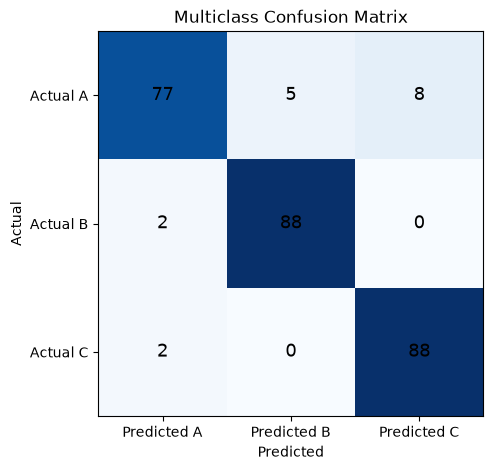

              precision    recall  f1-score   support

     Class A       0.95      0.86      0.90        90
     Class B       0.95      0.98      0.96        90
     Class C       0.92      0.98      0.95        90

    accuracy                           0.94       270
   macro avg       0.94      0.94      0.94       270
weighted avg       0.94      0.94      0.94       270



In [24]:
# --- Multiclass evaluation: 3 classes ---
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

# Synthetic 3-class problem (Classes A, B, C)
X, y = make_classification(n_samples=900, n_features=10, n_informative=8, n_redundant=0,
                           n_classes=3, n_clusters_per_class=1, random_state=15)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=15, stratify=y)

clf = RandomForestClassifier(n_estimators=100, random_state=15).fit(X_train, y_train)
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (rows = actual, columns = predicted):")
print(cm)

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["Predicted A", "Predicted B", "Predicted C"])
ax.set_yticks([0, 1, 2]); ax.set_yticklabels(["Actual A", "Actual B", "Actual C"])
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=13)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Multiclass Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred, target_names=["Class A", "Class B", "Class C"]))

In [25]:
# --- Macro, micro, and weighted averages computed by hand ---
cm = confusion_matrix(y_test, y_pred)

# Per-class precision and recall from the matrix
per_class_precision = cm.diagonal() / cm.sum(axis=0)   # correct / all predicted as k
per_class_recall    = cm.diagonal() / cm.sum(axis=1)   # correct / all actual k
per_class_f1 = 2 * per_class_precision * per_class_recall / (per_class_precision + per_class_recall)

print("Per-class metrics:")
for i, name in enumerate(["Class A", "Class B", "Class C"]):
    print(f"  {name}: precision = {per_class_precision[i]:.3f}, "
          f"recall = {per_class_recall[i]:.3f}, f1 = {per_class_f1[i]:.3f}")

macro_f1 = per_class_f1.mean()
print(f"\nMacro F1 (unweighted mean of per-class F1): {macro_f1:.3f}")

supports = cm.sum(axis=1)
weighted_f1 = (per_class_f1 * supports).sum() / supports.sum()
print(f"Weighted F1 (weighted by support): {weighted_f1:.3f}")

# Micro F1 for multiclass == accuracy (pool everything into one table)
print(f"Micro F1 (pooled) == accuracy: {accuracy_score(y_test, y_pred):.3f}")

# Compare with scikit-learn's values
from sklearn.metrics import f1_score
print(f"sklearn macro F1    = {f1_score(y_test, y_pred, average='macro'):.3f}")
print(f"sklearn weighted F1 = {f1_score(y_test, y_pred, average='weighted'):.3f}")
print(f"sklearn micro F1    = {f1_score(y_test, y_pred, average='micro'):.3f}")

Per-class metrics:
  Class A: precision = 0.951, recall = 0.856, f1 = 0.901
  Class B: precision = 0.946, recall = 0.978, f1 = 0.962
  Class C: precision = 0.917, recall = 0.978, f1 = 0.946

Macro F1 (unweighted mean of per-class F1): 0.936
Weighted F1 (weighted by support): 0.936
Micro F1 (pooled) == accuracy: 0.937
sklearn macro F1    = 0.936
sklearn weighted F1 = 0.936
sklearn micro F1    = 0.937


**What did we learn from this output?**

The confusion matrix shows exactly which classes get confused with which. The per-class
metrics reveal that some classes are handled better than others, and the three averaging
strategies give three different summaries: macro treats every class equally, weighted
favors larger classes, micro equals accuracy.

**What would this mean in a real-world application?**

If Class C were a dangerous disease and Class A a harmless condition, an excellent
overall F1 would be irrelevant if the recall for Class C were low — patients with the
dangerous disease would be misclassified. **Business priorities are per-class.** Adjust
the model, the threshold (per class, if the model outputs per-class probabilities), or
the cost matrix so the expensive confusions are minimized — even if the macro average
suffers slightly.

---

#### Beginner Perspective

*For multiclass: check the diagonal of the confusion matrix, read per-class precision /
recall / F1, and know the difference between macro (classes equal) and weighted (classes
weighted by size) averages.*

#### Expert Perspective

*Experts define a *cost matrix* C[i][j] = cost of predicting class j when the truth is
class i, minimize expected cost rather than error rate, and for ordinal or hierarchical
problems choose confusion-aware metrics (e.g., they might penalize "far" confusions more
than "near" ones). They also verify per-class support is large enough for stable
estimates.*

---

[⬅ Previous](#sec15) · [🏠 Table of Contents](#toc) · [Next ➡](#sec17)

📗 **Back to basics:** only here in depth — the nearest basic material is
**Section 10: The Classification Report** in `ML_Model_Evaluation_Simple.ipynb`, which
shows the per-class rows that multiclass evaluation builds on.


<a id="sec17"></a>
## 17. Cross-Validation

### Why is one train/test split not enough?

A single split is a **single roll of the dice**. The test set may happen to be easy or
hard by chance; a model selected on one lucky split can be much worse on the next one.
The numbers you compute are estimates with noise, and you should know how much noise.

### K-Fold Cross-Validation

The data is split into **K equal parts (folds)**. The model is trained K times — each
time on K−1 folds and evaluated on the remaining fold. Every sample is used for testing
exactly once. The final score is the **mean over the K folds**, and the spread (standard
deviation) tells you how stable the model is.

### Stratified K-Fold

Plain K-Fold can accidentally produce folds with very different class proportions — a
disaster for imbalanced data. **Stratified** K-Fold shuffles so that **each fold keeps
the same class proportions as the full dataset**. For classification, always prefer the
stratified version.

### Why this matters for model selection

- Cross-validation gives you a **distribution of performance**, not one number.
- Model A: mean 0.90 ± 0.01. Model B: mean 0.89 ± 0.03. A single lucky split might pick
  B; the honest comparison picks A as both better and more stable.
- You can also see overfitting risk: if training-fold scores are far above
  validation-fold scores, the model is memorizing.


In [26]:
# --- K-Fold vs Stratified K-Fold ---
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression

# Imbalanced data (10% positive) — the right kind of problem to show the difference
X, y = make_classification(n_samples=1000, n_features=10, n_informative=6,
                           weights=[0.9, 0.1], random_state=11)

model = LogisticRegression(max_iter=1000, random_state=11)

# Plain K-Fold: folds may end up with very different class proportions
kf = KFold(n_splits=5, shuffle=True, random_state=11)
acc_plain = cross_val_score(model, X, y, cv=kf, scoring="accuracy")

# Stratified K-Fold: each fold preserves the 90/10 split
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
acc_strat = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
f1_strat = cross_val_score(model, X, y, cv=skf, scoring="f1")

print("KFold accuracy:         ", np.round(acc_plain, 3), " mean =", round(acc_plain.mean(), 3))
print("StratifiedKFold acc:    ", np.round(acc_strat, 3), " mean =", round(acc_strat.mean(), 3))
print("StratifiedKFold F1:     ", np.round(f1_strat, 3),  " mean =", round(f1_strat.mean(), 3))
print()
print("Report the score as mean ± std, e.g.  F1 = "
      f"{f1_strat.mean():.3f} ± {f1_strat.std():.3f}")

KFold accuracy:          [0.925 0.92  0.915 0.925 0.93 ]  mean = 0.923
StratifiedKFold acc:     [0.955 0.91  0.905 0.925 0.92 ]  mean = 0.923
StratifiedKFold F1:      [0.743 0.438 0.387 0.571 0.579]  mean = 0.544

Report the score as mean ± std, e.g.  F1 = 0.544 ± 0.124


In [27]:
# --- How noisy is a single train/test split? ---
# Train the SAME model on 20 different random splits and look at the spread.
accs = []
for seed in range(20):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    m = LogisticRegression(max_iter=1000).fit(X_train, y_train)
    accs.append(accuracy_score(y_test, m.predict(X_test)))

print(f"20 random splits of the same model:")
print(f"  min  = {min(accs):.3f}")
print(f"  mean = {np.mean(accs):.3f}")
print(f"  max  = {max(accs):.3f}")
print(f"  std  = {np.std(accs):.3f}")
print()
print("A single split could report 0.90 or 0.95 for the SAME model —")
print("which is why one split is not enough to trust.")

20 random splits of the same model:
  min  = 0.897
  mean = 0.924
  max  = 0.953
  std  = 0.011

A single split could report 0.90 or 0.95 for the SAME model —
which is why one split is not enough to trust.


**What did we learn from this output?**

Cross-validation gives a mean **and** a spread: here the model's F1 ranges from about
0.39 to 0.74 across the five folds (0.54 ± 0.12). The 20-split experiment shows a single
train/test split of the *same* model can swing by several points — selecting a model on
one lucky split is gambling.

**What would this mean in a real-world application?**

Before approving a model for deployment, a bank should see not just "F1 = 0.54" but
"F1 = 0.54 ± 0.12 over stratified folds" — and should worry when the spread is this
wide. A model whose score varies wildly across folds is fragile: it may perform far worse
on next month's real data. Also note we scored with
**F1** here — on this imbalanced problem, accuracy across folds hides what we care about.
The metric *inside* cross-validation must be the business-relevant metric.

---

#### Beginner Perspective

*One split can lie. K-fold cross-validation averages performance over K train/test
repetitions and shows stability. For classification, use StratifiedKFold.*

#### Expert Perspective

*Experts choose the CV scheme to match the data structure (grouped data needs GroupKFold;
time series needs forward-chaining ([Section 19](#sec19)); rare positives need
stratification) and choose the
scoring function inside CV to match the business objective. They also watch for
preprocessing leakage *inside* the folds — scaling and feature selection must be fitted on
the training fold only (Section 18).*

---

[⬅ Previous](#sec16) · [🏠 Table of Contents](#toc) · [Next ➡](#sec18)

📗 **Back to basics:** see **Section 12: Cross-Validation** in
`ML_Model_Evaluation_Simple.ipynb` — why one split is not enough, with a Stratified
K-Fold demo.


<a id="sec18"></a>
## 18. Data Leakage — When Your Model Cheats

### What is data leakage?

**Data leakage** happens when information that would NOT be available at prediction time
sneaks into the training process — most dangerously, information from the **test set** or
from the **future**. The model then "cheats": it looks brilliant during evaluation because
the answers were in the room the whole time.

This is the deepest kind of evaluation mistake, because **every metric lies at once** —
accuracy, precision, recall, AUC, everything. A leaked model can score 99% and still be
completely useless in production.

> A leaked model is a genius in the lab and a fraud in the field.

### Two classic flavors of leakage

**1. Target-derived features.** A feature is built from the thing you are trying to
predict. Example: predicting loan default using the feature "customer asked for a
repayment extension" when that flag is only recorded *after* the default decision was
made. The feature contains the answer.

**2. Preprocessing before splitting.** A scaler, imputer, or feature selector is fitted on
the **full dataset** — including the rows that will later be used as the test set. The
test set silently "votes" on the model's parameters, so the test score is optimistic.

### The leak detector's checklist

Before trusting any evaluation, ask three questions:

1. **Would this feature exist at prediction time?** If it is only known after the event
   you are predicting, it is leaking.
2. **Was anything fitted on the full dataset?** Scaling, imputation, feature selection,
   target encoding — any fit must happen inside the training folds only.
3. **Does any feature suspiciously encode the answer?** A feature that correlates with the
   target at near-perfect level on a hard problem is usually a leak, not a discovery.

Let us make both flavors concrete with two demonstrations.


In [28]:
# --- Demo 1: a target-derived feature (leakage flavor #1) ---
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

# A realistic imbalanced problem (20% positive class)
X, y = make_classification(n_samples=2000, n_features=8, n_informative=6,
                           weights=[0.8, 0.2], random_state=31)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=31, stratify=y)

# The LEAKY feature: it is derived from the outcome y (only 5% noise added).
# Imagine a feature like "was flagged in a later audit" — it is only known AFTER
# the prediction would have been made, so it can never exist in production.
rng = np.random.RandomState(0)
leak_train = (y_train + rng.binomial(1, 0.05, len(y_train))) > 0
leak_test  = (y_test  + rng.binomial(1, 0.05, len(y_test)))  > 0

clf_leak   = RandomForestClassifier(n_estimators=100, random_state=31)
clf_leak.fit(np.column_stack([X_train, leak_train.astype(float)]), y_train)

clf_honest = RandomForestClassifier(n_estimators=100, random_state=31)
clf_honest.fit(X_train, y_train)

acc_l = accuracy_score(y_test, clf_leak.predict(np.column_stack([X_test, leak_test.astype(float)])))
acc_h = accuracy_score(y_test, clf_honest.predict(X_test))
auc_l = roc_auc_score(y_test, clf_leak.predict_proba(np.column_stack([X_test, leak_test.astype(float)]))[:, 1])
auc_h = roc_auc_score(y_test, clf_honest.predict_proba(X_test)[:, 1])

print("LEAKY  model (with the impossible feature):")
print(f"  accuracy = {acc_l:.3f}   ROC-AUC = {auc_l:.3f}")
print("HONEST  model (only features available at prediction time):")
print(f"  accuracy = {acc_h:.3f}   ROC-AUC = {auc_h:.3f}")
print()
print("Same data, same model family, same amount of real signal —")
print("the only difference is one impossible feature.")

LEAKY  model (with the impossible feature):
  accuracy = 0.987   ROC-AUC = 0.999
HONEST  model (only features available at prediction time):
  accuracy = 0.908   ROC-AUC = 0.974

Same data, same model family, same amount of real signal —
the only difference is one impossible feature.


**What did we learn from this output?**

One leaked feature (out of nine) lifts ROC-AUC from **0.974 to 0.999** — near-perfect
"performance" on a genuinely hard problem. The honest model is the same algorithm on the
same data without the cheat; that is the real level of performance.

**What would this mean in a real-world application?**

A bank's evaluation committee would see AUC 0.996, approve the model for deployment, and
then watch it fail on new customers — because in production the impossible feature does
not exist yet. Worse, the failure is invisible in the metrics: the test score was
inflated by the leak, so there was no honest evaluation to catch it. Notice also how
leakage corrupts the FP/FN accounting: the leaked model's confusion matrix claims almost
no errors, but the *real* model (once deployed) will produce far more FP and FN than the
numbers promised — every business decision built on those numbers is built on fantasy.

The single most reliable symptom of leakage is **suspiciously good performance**: on a
hard, noisy problem, ask "why is this model SO much better than everything else?" If the
answer is not a genuine new source of signal, look for the leak.


### Demo 2: preprocessing fitted before the split (leakage flavor #2)

The second flavor is subtler because no single feature looks wrong. Here we use **feature
selection on the whole dataset before cross-validation** — and, to make the cheat
impossible to miss, we use **pure noise**: 40 random Gaussian features and coin-flip
labels. There is no signal at all.

- The **honest pipeline** selects features *inside* each training fold (via `Pipeline`),
  so the test fold never influences the choice of features. Its CV score should hover
  around 0.5 — chance.
- The **leaky pipeline** selects the "best" features on the **full dataset** first, then
  cross-validates. Feature selection gets to peek at every fold, including the ones that
  are later used as test folds.


In [29]:
# --- Demo 2: feature selection before the split (leakage flavor #2) ---
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

# Pure noise: 200 rows x 40 features, random labels. There is NO signal to learn.
rng = np.random.RandomState(7)
X = rng.randn(200, 40)
y = rng.binomial(1, 0.5, 200)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

# LEAKY: SelectKBest is fitted on the FULL dataset (including future test folds).
selector = SelectKBest(f_classif, k=5).fit(X, y)
X_leaky = selector.transform(X)
leak_scores = cross_val_score(LogisticRegression(max_iter=2000), X_leaky, y,
                              cv=cv, scoring="roc_auc")

# HONEST: the same selection happens INSIDE each fold via a Pipeline, so each
# test fold is completely untouched during feature selection.
pipe = Pipeline([("select", SelectKBest(f_classif, k=5)),
                 ("clf", LogisticRegression(max_iter=2000))])
honest_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")

print(f"LEAKY  pipeline (selection on full data):  AUC = {leak_scores.mean():.3f} ± {leak_scores.std():.3f}")
print(f"HONEST pipeline (selection inside folds):  AUC = {honest_scores.mean():.3f} ± {honest_scores.std():.3f}")
print()
print("On pure noise the honest pipeline is at chance (~0.5) — there is nothing to learn.")
print("The leaky pipeline reports a phantom 0.66: the 'signal' is the test set voting")
print("through the feature selector.")

LEAKY  pipeline (selection on full data):  AUC = 0.659 ± 0.050
HONEST pipeline (selection inside folds):  AUC = 0.528 ± 0.052

On pure noise the honest pipeline is at chance (~0.5) — there is nothing to learn.
The leaky pipeline reports a phantom 0.66: the 'signal' is the test set voting
through the feature selector.


**What did we learn from this output?**

The honest pipeline on pure noise sits at chance (**0.528 ± 0.052** — a coin flip, as it
should be). The leaky pipeline reports **0.659 ± 0.050** — a phantom "signal" created
entirely by letting the test folds participate in feature selection. There is literally
nothing to predict, yet the evaluation claims a working model.

**What would this mean in a real-world application?**

This is how teams ship models that "worked in the lab" and fail on real data: a small,
noisy dataset, a few hundred features, feature selection applied to the whole dataset
"to clean the data up" — and the evaluation says 0.66 while reality is 0.5. The fix is
mechanical: **put every preprocessing step inside the cross-validation folds**, which is
exactly what `Pipeline` does. If you fit scalers, imputers, encoders, or selectors
manually, you must re-fit them inside each training fold — never on the combined data.

### The fix: golden rules for leak-free evaluation

1. **Everything that touches the data must be fitted inside the training folds.**
   Scaling, imputation, feature selection, encoding, class balancing — all of it. A
   `Pipeline` makes this automatic and is the safest habit.
2. **Every feature must exist at prediction time.** If you would not know the value when
   making the real-world prediction, it must not be a feature.
3. **No future information.** For time series, never shuffle: use temporal splits where
   training data always ends before validation data begins (we demonstrate this in
   [Section 19](#sec19)).
4. **Beware target encoding done on the full dataset** — a classic way for the label to
   leak into the features.
5. **Watch for duplicated rows** between train and test (or between folds) — identical
   rows in both sets leak the answer directly.
6. **Treat suspiciously high scores as a red flag, not a triumph.** On hard problems,
   ask where the signal could possibly come from.
7. **Sanity-check with an ablation:** remove the suspicious feature and see if the score
   collapses. If it does, you found a leak, not a discovery.

---

#### Beginner Perspective

*Never fit preprocessing on the full dataset. Use `Pipeline` so every step is fitted
inside the folds, and never use a feature that would not exist at prediction time.*

#### Expert Perspective

*Experts design the validation scheme around the data-generating process: temporal
splits for time series, grouped splits when rows share entities, and leak audits where
feature importance and ablations are checked against domain knowledge. They also know
that leakage has a cost dimension: every inflated metric misprices FP and FN — the
deployed model will make far more expensive errors than the evaluation promised, which
is why honest evaluation is a business requirement, not an academic nicety.*

---

[⬅ Previous](#sec17) · [🏠 Table of Contents](#toc) · [Next ➡](#sec19)

📗 **Back to basics:** only here in depth — the seed idea (“judge a model only
on data it has never seen”) is **Section 1: Introduction to Model Evaluation** in
`ML_Model_Evaluation_Simple.ipynb`.


<a id="sec19"></a>
## 19. Time-Series Evaluation — Never Shuffle the Clock

### Why is time special?

Most of this notebook assumes rows are **independent**: one customer, one image, one
transaction. Time series break that assumption — each row's value depends on the rows
before it. Today's sales, temperature, CPU load, or stock price is correlated with
yesterday's.

That one fact changes how evaluation must be done. If you split a time series with a
**random shuffle**, the test set is no longer "the future" — it is a random sample from
the same period as the training data. A test row at time *t* has its previous value
(at *t*−1) sitting inside the training set, so the model can **interpolate** instead of
**forecast**. The evaluation then measures something easy, not something real: it is a
quiet form of the data leakage from [Section 18](#sec18), produced by the split itself.

### The three canonical schemes

1. **Single temporal cut.** Train on the past (e.g., first 80%), test on the future
   (last 20%). Simple, honest, one number — but only one number.
2. **Forward-chaining (expanding window).** Train on an ever-growing past and validate
   on the next block: fold 1 trains on months 1–2, validates on month 3; fold 2 trains
   on months 1–3, validates on month 4; and so on. This is `TimeSeriesSplit` and it
   mimics deployment exactly — at each step you only know the past.
3. **Sliding window.** Same idea, but training uses a fixed-size recent window (e.g.,
   the last 3 months only). The model adapts faster when behavior drifts, at the cost
   of using less data.

The next cell shows what happens when you ignore all of this.


In [30]:
# --- Why shuffling a time series leaks the future into training ---
from sklearn.linear_model import LinearRegression

# A smooth, slowly drifting series (sine + trend + noise): a plausible demand or
# temperature signal where "the future looks like the past".
rng = np.random.RandomState(0)
n = 500
t = np.arange(n)
y = np.sin(t / 12.0) + 0.02 * t + rng.randn(n) * 0.3

# Feature: the previous value. Target: the next value. (A 1-step-ahead forecast.)
X = y[:-1].reshape(-1, 1)
target = y[1:]

# (1) HONEST: train on the past, test on the future
cut = int(0.8 * len(X))
m = LinearRegression().fit(X[:cut], target[:cut])
r2_honest = r2_score(target[cut:], m.predict(X[cut:]))

# (2) SHUFFLED: random split — test rows are interleaved with training rows, so
#     each test point's "previous value" is almost certainly in the training set.
X_tr, X_te, y_tr, y_te = train_test_split(X, target, test_size=0.2, random_state=0)
m2 = LinearRegression().fit(X_tr, y_tr)
r2_shuf = r2_score(y_te, m2.predict(X_te))

print(f"HONEST   (train on past, test on future):  R² = {r2_honest:.3f}")
print(f"SHUFFLED (random split, future leaks in):  R² = {r2_shuf:.3f}")
print()
print("Same model, same data, same number of rows.")
print("Shuffling only changed WHICH rows are test rows — and it let the model")
print("interpolate instead of forecast.")

HONEST   (train on past, test on future):  R² = 0.813
SHUFFLED (random split, future leaks in):  R² = 0.979

Same model, same data, same number of rows.
Shuffling only changed WHICH rows are test rows — and it let the model
interpolate instead of forecast.


**What did we learn from this output?**

The exact same `LinearRegression` scores **R² = 0.979** when the rows are shuffled but
only **R² = 0.813** on a proper temporal split. The shuffle did not add information — it
*moved the test set into the training period*, so every test point's lagged feature had
an almost-identical neighbor in training. The model looks dramatically better than it
will ever be in practice.

**What would this mean in a real-world application?**

Deployment is always a forecast: when the model runs, only the past exists. A demand-
forecasting model evaluated on shuffled data promises accuracy it cannot deliver, so
inventory and staffing budgets built on that number will be wrong. The same leak
inflates classification metrics too — a fraud or churn model scored on shuffled months
overstates precision and recall, and the FP/FN counts the business sees in production
will be worse than the evaluation promised. If the rows have a time axis, the split
must respect it.


TimeSeriesSplit R² per fold: [0.554 0.777 0.788 0.865 0.829]
mean = 0.763 ± 0.109
Note the first fold: it trains on only 84 rows, so it scores worst —
report the per-fold spread, not just the mean.


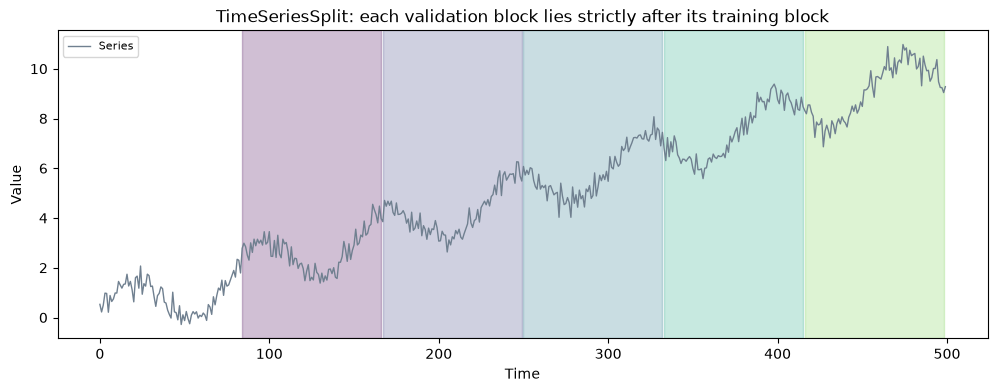

In [31]:
# --- Forward-chaining: TimeSeriesSplit and its fold plot ---
from sklearn.model_selection import TimeSeriesSplit

# TimeSeriesSplit: each fold trains on the PAST and validates on the NEXT block.
# The training window grows with every fold (expanding window / forward-chaining).
tss = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(LinearRegression(), X, target, cv=tss, scoring="r2")

print("TimeSeriesSplit R² per fold:", np.round(scores, 3))
print(f"mean = {scores.mean():.3f} ± {scores.std():.3f}")
print("Note the first fold: it trains on only 84 rows, so it scores worst —")
print("report the per-fold spread, not just the mean.")

# Visualize the folds: every validation block lies strictly AFTER its training block
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, y, lw=1, color="slategray", label="Series")
for k, (tr, te) in enumerate(tss.split(X)):
    ax.axvspan(t[min(te)], t[max(te)], alpha=0.25, color=plt.cm.viridis(k / tss.n_splits))
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_title("TimeSeriesSplit: each validation block lies strictly after its training block")
ax.legend(fontsize=8)
plt.show()

### Try it yourself — the temporal cut-point explorer

Drag the slider to choose where the **temporal cut** falls (how much of the history
trains the model). Watch two numbers at once:

- **Honest R²** — train on the past, test on the future. This is the number the deployed
  model will actually deliver.
- **Shuffled R²** — the same model, same data, random split. It stays almost perfectly
  flat, no matter where you cut.

Experiments to try:

1. Drag from 50% to 80%: the honest R² wobbles while the shuffled one barely moves.
   Which number depends on time? Only the honest one.
2. Push to 90–95%: the honest estimate collapses — the model must forecast far into the
   future and is judged on only 25–50 points. The shuffled line does not care, because
   it never looks at time at all.
3. Ask yourself: if a team reported the shuffled number to the budget committee, which
   line of the plot is the lie?

*This widget needs `ipywidgets`. If it is not installed, the cell below shows a static
snapshot instead of live sliders — install it with `pip install ipywidgets`, restart the
kernel, and re-run the cell.*


In [32]:
# --- Interactive: temporal cut-point explorer ---
# Self-contained: rebuilds the series and both models here, so it works after a restart.
rng = np.random.RandomState(0)
n_ts = 500
t_ts = np.arange(n_ts)
y_ts = np.sin(t_ts / 12.0) + 0.02 * t_ts + rng.randn(n_ts) * 0.3
X_ts = y_ts[:-1].reshape(-1, 1)
target_ts = y_ts[1:]


def honest_r2(cut_frac):
    # Train on the past, test on the future, at the given cut fraction.
    cut = int(cut_frac * len(X_ts))
    m = LinearRegression().fit(X_ts[:cut], target_ts[:cut])
    return r2_score(target_ts[cut:], m.predict(X_ts[cut:])), cut


def shuffled_r2(test_frac, seed=0):
    # Same model, same data, random split of the same size.
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_ts, target_ts, test_size=test_frac, random_state=seed)
    m = LinearRegression().fit(X_tr, y_tr)
    return r2_score(y_te, m.predict(X_te))


try:
    import ipywidgets as widgets
    from IPython.display import display

    def explore(cut_frac):
        r2_h, cut = honest_r2(cut_frac)
        r2_s = shuffled_r2(1 - cut_frac)
        m = LinearRegression().fit(X_ts[:cut], target_ts[:cut])
        y_forecast = m.predict(X_ts[cut:])
        test_t = np.arange(cut, len(X_ts))

        fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

        # Left: the series, the cut, and the honest forecast of the future
        axes[0].plot(t_ts, y_ts, lw=1, color="slategray", label="Series")
        axes[0].axvline(cut, color="crimson", linestyle="--", lw=1.5,
                        label=f"Cut at t = {cut}")
        axes[0].plot(test_t, y_forecast, lw=1.8, color="seagreen", label="Honest forecast")
        axes[0].set_xlabel("Time"); axes[0].set_ylabel("Value")
        axes[0].set_title(f"Train on the past ({cut} rows), forecast the future ({len(X_ts)-cut} rows)")
        axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

        # Right: honest vs shuffled at the current cut
        bars = axes[1].bar(["Honest\n(temporal cut)", "Shuffled\n(random split)"],
                           [r2_h, r2_s], color=["steelblue", "coral"])
        for bar, v in zip(bars, [r2_h, r2_s]):
            axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.3f}",
                         ha="center")
        axes[1].set_ylim(0, 1.08)
        axes[1].set_ylabel("R²")
        axes[1].set_title("Same model, same data — only the split changes")
        axes[1].grid(axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(f"Cut = {cut_frac:.0%} of history for training ({cut} rows)  |  test = {len(X_ts)-cut} future rows")
        print(f"Honest R²   = {r2_h:.3f}   (the number deployment will actually deliver)")
        print(f"Shuffled R² = {r2_s:.3f}   (the number shuffling pretends you have)")
        print("The shuffled estimate is flat across cuts: it never depends on time — and it lies.")

    slider_cut = widgets.FloatSlider(value=0.80, min=0.50, max=0.95, step=0.01,
                                     description="Cut point:")
    out = widgets.interactive_output(explore, {"cut_frac": slider_cut})
    with out:
        explore(0.80)   # start at the section's default 80/20 split
    display(widgets.VBox([slider_cut, out]))
    print("✅ Drag the cut point: honest R² moves with the cut, the shuffled one stays flat.")

except ImportError:
    print("ipywidgets is not installed, so the interactive slider is unavailable.")
    print("Install it with:  pip install ipywidgets   (then restart the kernel and re-run this cell).")
    print("Until then, use the table above: honest R² moves with the cut; shuffled R² stays ~0.98.")

✅ Drag the cut point: honest R² moves with the cut, the shuffled one stays flat.


**What did we learn from this output?**

The folds show the honest spread: R² ranges from **0.55 to 0.87** (mean 0.76), and the
first fold — with the least training data — is the worst. A single number would hide
this. The plot is the key picture: **training always ends before validation begins**,
which is exactly how the model will be used in production.

### How to score a model on temporally ordered data

1. **Never shuffle.** Random splits are the leak.
2. **Use `TimeSeriesSplit` (or a manual temporal cut) and `cross_val_score`.** Each test
   fold is the future of its training fold.
3. **Choose expanding vs sliding window deliberately.** Expanding uses all history and
   suits stable series; sliding windows adapt to drift (e.g., fashion, prices) but use
   less data. Test both and compare the per-fold means.
4. **Keep every preprocessing step inside the folds** — the `Pipeline` habit from
   [Section 18](#sec18) applies to time series exactly as to i.i.d. data.
5. **Report the per-fold spread**, especially the early folds, which show how the model
   behaves when data is scarce.
6. **For grouped time series** (many stores, many sensors, each with its own timeline),
   use a grouped temporal split so a single entity does not appear in both train and
   test folds.

### Case study: sales across 20 stores (why the entity axis matters)

We now have **two axes of leakage**: *time* (the future) and *entity* (the store). A
single-series model only has the time axis, but a **panel** of many stores has both.
Each of the 20 stores below has its own baseline level, a shared seasonal pattern, and a
gentle upward trend — a typical retail sales setup.

The model predicts sales from the day, the season, and a **store indicator** (one column
per store), exactly like a model that "remembers" each store's typical level. Now run
the same model through three validation protocols:

- **A — Plain shuffle:** random 80/20 split. Leaks time *and* store.
- **B — Plain temporal cut** (the `TimeSeriesSplit` idea from above, applied to the
  pooled panel): train on days < 320, test on days ≥ 320. Time is respected, but the
  test stores were **already in training** — the model can recognize them.
- **C — Grouped temporal:** train on 16 stores' full history, test on 4 **brand-new
  stores** the model has never seen. Leaks neither time nor store.

All three test sets have the same size (1,600 rows), so the R² numbers are comparable.


A. Plain shuffle         R² = 0.983   (leaks time + store)
B. Plain temporal cut   R² = 0.977   (leaks store only)
C. Grouped temporal     R² = 0.268   (leaks neither)

A and B both look great. Only C answers the real question:
how well does this model work for stores it has never seen?


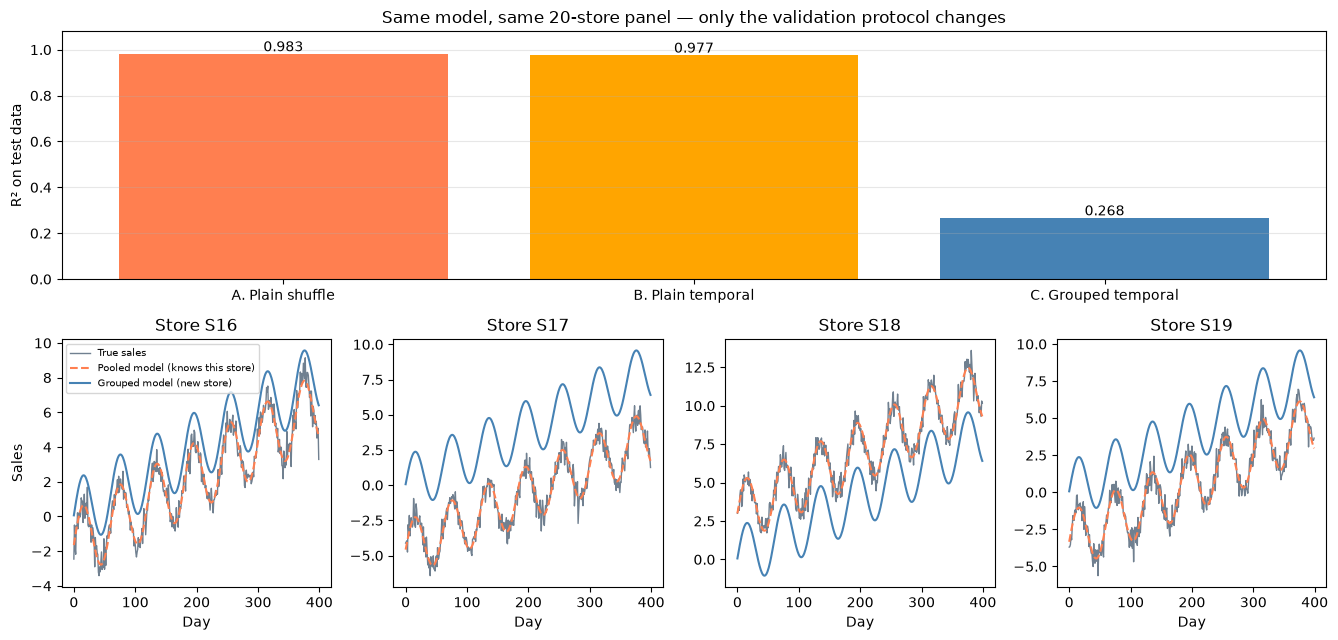

In [33]:
# --- Panel case study: three validation protocols on 20 stores ---
# Each store has its own level, plus shared seasonality and trend.
rng = np.random.RandomState(3)
n_stores, n_days = 20, 400
period = 60
store_effect = rng.normal(0, 3.0, n_stores)
day = np.arange(n_days)

rows = []
for s in range(n_stores):
    sales = (store_effect[s] + 0.02 * day
             + 2.0 * np.sin(2 * np.pi * day / period) + rng.normal(0, 0.5, n_days))
    rows.append(pd.DataFrame({"store": f"S{s:02d}", "day": day,
                              "sin": np.sin(2 * np.pi * day / period),
                              "cos": np.cos(2 * np.pi * day / period),
                              "sales": sales}))
df = pd.concat(rows, ignore_index=True)


def build_features(d, store_cols):
    # One indicator column per store; columns for unseen stores are zeroed.
    dummies = pd.get_dummies(d["store"]).reindex(columns=store_cols, fill_value=0)
    return pd.concat([d[["day", "sin", "cos"]], dummies], axis=1)


all_stores = sorted(df["store"].unique())
train_stores = all_stores[:16]
test_stores = all_stores[16:]

# A. Plain shuffle — leaks time AND store
X = build_features(df, all_stores)
y = df["sales"].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0)
r2_A = r2_score(y_te, LinearRegression().fit(X_tr, y_tr).predict(X_te))

# B. Plain temporal cut — time respected, but the test stores WERE in training
b_tr = df[df["day"] < 320]
b_te = df[df["day"] >= 320]
mB = LinearRegression().fit(build_features(b_tr, all_stores), b_tr["sales"].values)
r2_B = r2_score(b_te["sales"].values, mB.predict(build_features(b_te, all_stores)))

# C. Grouped temporal — test stores are brand new (never seen in training)
c_tr = df[df["store"].isin(train_stores)]
c_te = df[df["store"].isin(test_stores)]
mC = LinearRegression().fit(build_features(c_tr, train_stores), c_tr["sales"].values)
r2_C = r2_score(c_te["sales"].values, mC.predict(build_features(c_te, train_stores)))

print(f"A. Plain shuffle         R² = {r2_A:.3f}   (leaks time + store)")
print(f"B. Plain temporal cut   R² = {r2_B:.3f}   (leaks store only)")
print(f"C. Grouped temporal     R² = {r2_C:.3f}   (leaks neither)")
print()
print("A and B both look great. Only C answers the real question:")
print("how well does this model work for stores it has never seen?")

# The mechanism, in pictures: true sales vs each protocol's predictions, per test store
fig = plt.figure(figsize=(13.5, 6.5))
gs = fig.add_gridspec(2, 4)
ax_bar = fig.add_subplot(gs[0, :])
bars = ax_bar.bar(["A. Plain shuffle", "B. Plain temporal", "C. Grouped temporal"],
                  [r2_A, r2_B, r2_C], color=["coral", "orange", "steelblue"])
for bar, v in zip(bars, [r2_A, r2_B, r2_C]):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center")
ax_bar.set_ylim(0, 1.08)
ax_bar.set_ylabel("R² on test data")
ax_bar.set_title("Same model, same 20-store panel — only the validation protocol changes")
ax_bar.grid(axis="y", alpha=0.3)

for i, s in enumerate(test_stores):
    ax = fig.add_subplot(gs[1, i])
    sub = df[df["store"] == s]
    ax.plot(sub["day"], sub["sales"], lw=1, color="slategray", label="True sales")
    ax.plot(sub["day"], mB.predict(build_features(sub, all_stores)),
            lw=1.5, color="coral", ls="--", label="Pooled model (knows this store)")
    ax.plot(sub["day"], mC.predict(build_features(sub, train_stores)),
            lw=1.5, color="steelblue", label="Grouped model (new store)")
    ax.set_title(f"Store {s}")
    ax.set_xlabel("Day")
    if i == 0:
        ax.set_ylabel("Sales")
        ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

**What did we learn from this output?**

Fixing the time axis alone changes almost nothing: **R² = 0.983 shuffled vs 0.977 on a
plain temporal cut**. The reason is visible in the four store panels — the pooled model
"recognizes" each test store because that store's past was in training, so it snaps to
the store's level. Only the **grouped temporal split (R² = 0.268)** removes the store
from the picture: the grouped model has to predict each new store from the global
pattern alone, which is what deployment to a new store actually requires.

**What would this mean in a real-world application?**

A retail chain evaluating "will this sales model work?" gets two very different answers
depending on the protocol: ~0.98 for stores already known (and already being served by
the model) versus ~0.27 for new locations. Reporting the pooled number to an expansion
committee would promise new-store accuracy the model cannot deliver. The right protocol
must match the deployment question: existing stores, new stores, or both. A bonus
diagnostic: a vanilla pooled `TimeSeriesSplit` on this panel produces wildly unstable
folds (some ≈ 0.9, some ≈ 0.3) because the row-order split randomly lands test blocks
on known or unknown stores — instability across folds is itself a red flag that the
split structure does not match the data structure.

### Try it yourself — which stores are "new"?

Pick which **4 stores are held out** as new, and the grouped R² is recomputed for
exactly your selection. The right-hand histogram shows where your choice falls among
**all 4,845 possible 4-store hold-out sets** (computed analytically, so it is instant).

Experiments to try:

1. The defaults (S16–S19) reproduce the case study: R² ≈ 0.27. Where does that sit in
   the distribution?
2. Find an **easy** hold-out: pick stores whose levels sit near the middle of the left
   chart (e.g., S04, S06, S08, S14) and watch R² climb toward 0.95.
3. Find a **hard** hold-out: pick stores with extreme levels (e.g., S00, S11, S13,
   S18) and watch R² go **negative** — worse than predicting the average.
4. Look at the spread of the histogram. One hold-out set is one draw: the "honest
   number" is really a distribution. And the leaky protocols (A ≈ 0.98, B ≈ 0.98) sit
   entirely outside it — no honest evaluation comes close to them.

*This widget needs `ipywidgets`. If it is not installed, the cell below shows a static
snapshot instead of live dropdowns — install it with `pip install ipywidgets`, restart
the kernel, and re-run the cell.*


In [34]:
# --- Interactive: which 4 stores are "new"? ---
# Self-contained: rebuilds the panel, then enumerates ALL 4,845 possible 4-store
# hold-out sets analytically, so the histogram is exact and instant.
from itertools import combinations

rng = np.random.RandomState(3)
n_stores, n_days = 20, 400
period = 60
store_effect = rng.normal(0, 3.0, n_stores)
day = np.arange(n_days)
rows = []
for s in range(n_stores):
    sales = (store_effect[s] + 0.02 * day
             + 2.0 * np.sin(2 * np.pi * day / period) + rng.normal(0, 0.5, n_days))
    rows.append(pd.DataFrame({"store": f"S{s:02d}", "day": day,
                              "sin": np.sin(2 * np.pi * day / period),
                              "cos": np.cos(2 * np.pi * day / period),
                              "sales": sales}))
df = pd.concat(rows, ignore_index=True)
all_stores = sorted(df["store"].unique())


def build_features(d, store_cols):
    dummies = pd.get_dummies(d["store"]).reindex(columns=store_cols, fill_value=0)
    return pd.concat([d[["day", "sin", "cos"]], dummies], axis=1)


def grouped_r2(held):
    # Exact same code path as the case study above (brute-force fit).
    held = list(dict.fromkeys(held))
    tr = df[~df["store"].isin(held)]
    te = df[df["store"].isin(held)]
    cols = [s for s in all_stores if s not in held]
    m = LinearRegression().fit(build_features(tr, cols), tr["sales"].values)
    return r2_score(te["sales"].values, m.predict(build_features(te, cols)))


# Analytic shortcut for the full enumeration: the day/seasonal coefficients are the
# same for EVERY hold-out set (store effects are independent of the shared pattern),
# so only the store-level intercept changes between combos. Precompute per-store
# residual sums once, then each of the 4,845 combos costs O(20) instead of a model fit.
beta = LinearRegression().fit(
    pd.concat([df[["day", "sin", "cos"]],
               pd.get_dummies(df["store"]).reindex(columns=all_stores, fill_value=0)], axis=1),
    df["sales"].values).coef_[:3]

S1, S2, Sy, Sy2, ns = {}, {}, {}, {}, {}
for s in all_stores:
    sub = df[df["store"] == s]
    e = sub["sales"].values - sub[["day", "sin", "cos"]].to_numpy() @ beta
    S1[s] = e.sum(); S2[s] = (e ** 2).sum()
    Sy[s] = sub["sales"].sum(); Sy2[s] = (sub["sales"] ** 2).sum(); ns[s] = len(sub)


def analytic_r2(combo):
    train = [s for s in all_stores if s not in combo]
    b = sum(S1[s] for s in train) / sum(ns[s] for s in train)      # combo intercept
    rss = sum(S2[s] - 2 * b * S1[s] + ns[s] * b * b for s in combo)
    nt = sum(ns[s] for s in combo)
    mu = sum(Sy[s] for s in combo) / nt
    tss = sum(Sy2[s] for s in combo) - nt * mu * mu
    return 1 - rss / tss


all_r2 = np.array([analytic_r2(c) for c in combinations(all_stores, 4)])
store_means = df.groupby("store")["sales"].mean()
print(f"Enumerated all {len(all_r2)} hold-out sets: grouped R² ranges "
      f"{all_r2.min():.2f} to {all_r2.max():.2f} (median {np.median(all_r2):.2f})")


try:
    import ipywidgets as widgets
    from IPython.display import display

    def explore(s1, s2, s3, s4):
        held = list(dict.fromkeys([s1, s2, s3, s4]))
        r2_cur = grouped_r2(held)
        pct = (all_r2 < r2_cur).mean()

        fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

        # Left: store levels, held-out stores highlighted
        colors = ["coral" if s in held else "steelblue" for s in all_stores]
        axes[0].bar(all_stores, store_means.values, color=colors)
        axes[0].set_xlabel("Store"); axes[0].set_ylabel("Mean sales (level)")
        axes[0].set_title("Store levels — held-out stores in coral")
        axes[0].tick_params(axis="x", rotation=90, labelsize=7)
        axes[0].grid(axis="y", alpha=0.3)

        # Right: the honest R² distribution over ALL hold-out sets
        axes[1].hist(all_r2, bins=40, color="steelblue", alpha=0.65)
        axes[1].axvline(r2_cur, color="coral", lw=2,
                        label=f"Your selection: R² = {r2_cur:.3f}")
        axes[1].set_xlabel("Grouped R² (4 stores held out)")
        axes[1].set_ylabel("Hold-out sets (of 4,845)")
        axes[1].set_title("The honest number is a distribution")
        axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(f"Held-out stores: {held}  ->  grouped R² = {r2_cur:.3f}")
        print(f"This is better than {pct:.0%} of all 4,845 possible hold-out sets.")
        print("Reference: plain shuffle R² = 0.983 and pooled temporal R² = 0.977 —")
        print("both sit far above the entire honest range.")

    dropdowns = [widgets.Dropdown(options=all_stores, value=all_stores[i],
                                  description=f"New store {k}:",
                                  layout=widgets.Layout(width="150px"))
                 for k, i in enumerate([16, 17, 18, 19])]
    out = widgets.interactive_output(explore,
                                     {"s1": dropdowns[0], "s2": dropdowns[1],
                                      "s3": dropdowns[2], "s4": dropdowns[3]})
    with out:
        explore(*[d.value for d in dropdowns])   # initial view = the case study's S16–S19
    display(widgets.VBox([widgets.HBox(dropdowns), out]))
    print("✅ Change which stores are 'new' and watch the honest R² move.")

except ImportError:
    print("ipywidgets is not installed, so the interactive dropdowns are unavailable.")
    print("Install it with:  pip install ipywidgets   (then restart the kernel and re-run this cell).")
    print("Until then: the case study above shows one draw from this distribution (S16–S19 -> R² = 0.27).")

Enumerated all 4845 hold-out sets: grouped R² ranges -2.47 to 0.95 (median 0.36)


✅ Change which stores are 'new' and watch the honest R² move.


### The evaluation protocol decision tree

Everything in Section 19 reduces to two questions:

1. **What is the structure of the rows?** Independent, one timeline, or many entities × time?
2. **What will deployment look like?** New random rows, the next month of the same series,
   or brand-new entities?

```
Start: what do your rows look like?
│
├─ INDEPENDENT rows (no time axis, no shared entity)
│    └→ K-Fold / Stratified K-Fold — shuffling is harmless (Section 17)
│         └ rows share an entity (same patient, same user)?
│              └→ GroupKFold — one entity must not straddle folds
│
├─ ONE time series (a single timeline)
│    └→ TimeSeriesSplit (expanding window) or a sliding window
│         └ NEVER shuffle; training must end before validation begins
│
└─ PANEL (many entities × time)
     ├─ deployment to KNOWN entities (same stores next month)
     │    └→ temporal split — train on the past of the same entities
     │
     └─ deployment to NEW entities (expansion to new stores)
          └→ GROUPED temporal split — hold out whole entities
               └ both axes must be respected: the case study above
```

### The one-line version

| Your data | Your deployment question | Use | Never use |
|---|---|---|---|
| i.i.d. rows | new random rows | K-Fold / Stratified K-Fold | — |
| one time series | the next month(s) | TimeSeriesSplit / sliding window | shuffled splits |
| panel, known entities | same stores next month | temporal cut (pooled) | shuffled splits |
| panel, new entities | expansion to new stores | grouped temporal hold-out | shuffled OR plain `TimeSeriesSplit` |

**The rule that covers all four rows:** choose the split so that the test set contains
exactly what the model will not know at prediction time — new random rows, the future,
new entities, or all three. If a split lets the model see any of them during training,
the evaluation is a lie, no matter which metric you compute on it.


---

#### Beginner Perspective

*Time matters. Train on the past, test on the future, and never shuffle the clock.
`TimeSeriesSplit` does the first two for you.*

#### Expert Perspective

*Experts match the validation scheme to the data-generating process: temporal
forward-chaining for single series, grouped temporal splits for panel data, and
embedding- or date-based splits when leakage can creep through lags and rolling
features. They also treat horizon carefully — a 1-step-ahead and a 30-step-ahead model
need different validation, and every metric must be computed at the same horizon the
business actually forecasts.*

---

[⬅ Previous](#sec18) · [🏠 Table of Contents](#toc) · [Next ➡](#sec20)

📗 **Back to basics:** only here in depth — the essential idea (“never evaluate
on data the model could have seen”) is **Section 1: Introduction to Model Evaluation**
in `ML_Model_Evaluation_Simple.ipynb`.


<a id="sec20"></a>
## 20. Regression Metrics

Regression predictions are numbers, so errors are **differences between predicted and
true values**. Let $y_i$ be the true value of sample $i$ and $\hat{y}_i$ the prediction;
$n$ is the number of samples.

### MAE — Mean Absolute Error

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

- **Measures:** the average absolute error, in the **same units as the target**.
- **Intuition:** "on average, how far off are the predictions, ignoring direction?"
- **When to use:** when every error counts equally and you want an easily explainable
  number.
- **Limitation:** gives no extra penalty to large errors.

### MSE — Mean Squared Error

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

- **Measures:** the average of *squared* errors.
- **Intuition:** large errors are penalized **quadratically** — one big mistake hurts far
  more than many small ones.
- **When to use:** when large errors are disproportionately bad (e.g., one grossly wrong
  price estimate).
- **Limitation:** units are squared, so the number is hard to interpret directly; also
  sensitive to outliers.

### RMSE — Root Mean Squared Error

$$\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

- **Measures:** the same as MSE but back in the **original units**.
- **Intuition:** an "average-size" error with a heavy penalty on large errors — think of
  it as a standard deviation of the errors.
- **When to use:** when you want MSE's big-error penalty *and* interpretable units.
- **Limitation:** still outlier-sensitive; always larger than or equal to MAE (the gap
  grows with the size of the largest errors).

### R² — Coefficient of Determination

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

- **Measures:** the proportion of variance in the target explained by the model, compared
  with a baseline that always predicts the mean $\bar{y}$.
- **Intuition:** R² = 1 is perfect; R² = 0 means "no better than predicting the mean";
  R² can be negative (worse than the mean baseline).
- **When to use:** to communicate "how much of the variation does the model capture?"
- **Limitation:** R² rises mechanically with more features and can look impressive while
  errors are still large in absolute terms.

### Business interpretation — why units matter

If a house-price model has MAE = 50,000, it means: *on average, the predicted price is
about 50,000 currency units away from the true price.* Whether that is good depends on the
application — for a €100,000 house it is terrible; for a €5,000,000 house it might be
fine. **The meaning of an error always depends on the application** — the same reasoning
we used for classification costs applies to regression errors too.


In [35]:
# --- Regression metrics: house price prediction ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Synthetic house-price data
rng = np.random.RandomState(42)
n = 300
area = rng.uniform(800, 3500, n)
bedrooms = rng.randint(1, 6, n).astype(float)
price = 40000 + 140 * area + 8000 * bedrooms + rng.normal(0, 20000, n)

df = pd.DataFrame({"area": area, "bedrooms": bedrooms, "price": price})

Xr = df[["area", "bedrooms"]]
yr = df["price"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.3, random_state=42)
lr = LinearRegression().fit(Xr_train, yr_train)
pred = lr.predict(Xr_test)

mae  = mean_absolute_error(yr_test, pred)
mse  = mean_squared_error(yr_test, pred)
rmse = np.sqrt(mse)
r2   = r2_score(yr_test, pred)

print(f"MAE  = {mae:,.0f}   (average absolute error in currency units)")
print(f"MSE  = {mse:,.0f}   (average squared error — penalizes big errors)")
print(f"RMSE = {rmse:,.0f}   (same as MSE but back in currency units)")
print(f"R²   = {r2:.3f}   (fraction of price variance explained)")

# Compare the error sizes with the scale of the target
print(f"\nTypical house price: ~{yr_test.mean():,.0f}")
print(f"RMSE is about {rmse / yr_test.mean():.1%} of the average price")

MAE  = 15,747   (average absolute error in currency units)
MSE  = 389,867,142   (average squared error — penalizes big errors)
RMSE = 19,745   (same as MSE but back in currency units)
R²   = 0.968   (fraction of price variance explained)

Typical house price: ~362,038
RMSE is about 5.5% of the average price


**What did we learn from this output?**

MAE and RMSE describe the *size* of the errors in currency units; R² describes the
*fraction of variance explained*. Note RMSE > MAE — the big errors are pulling the squared
average up. The last line is the business translation: "the typical prediction error is
about X% of the average house price."

**What would this mean in a real-world application?**

If the model is used to price 1,000 houses a month and MAE = 40,000, the company should
know that its *average* price quote is wrong by 40,000 — before deciding whether that
error is acceptable relative to profit margins and competition. If occasional very wrong
quotes cause lawsuits or lost deals, RMSE (with its big-error penalty) is the metric to
watch rather than MAE.

| Metric | Best for | Main limitation |
|---|---|---|
| MAE | Explainable, unit-level average error | Ignores error size distribution |
| MSE | Penalizing large errors | Hard to interpret (squared units) |
| RMSE | Penalizing large errors + interpretable units | Outlier-sensitive |
| R² | "How much variance is explained?" | Can hide large absolute errors |

---

#### Beginner Perspective

*MAE = average error in original units. RMSE = like MAE but punishes big mistakes.
R² = how much of the variation the model explains.*

#### Expert Perspective

*Experts choose the regression loss to match business asymmetry (a quote 20% too high and
one 20% too low rarely cost the same; use asymmetric or quantile losses), and they prefer
unit-scale metrics (MAE/RMSE) for business reporting while using R² only as a relative
goodness-of-fit measure, never in isolation.*

---

[⬅ Previous](#sec19) · [🏠 Table of Contents](#toc) · [Next ➡](#sec21)

📗 **Back to basics:** see **Section 13: Regression Metrics** in
`ML_Model_Evaluation_Simple.ipynb` — MAE, MSE, RMSE and R² on a small house-price
example.


<a id="sec21"></a>
## 21. End-to-End Case Study: Loan Default Prediction

Everything so far comes together in one complete, realistic workflow. We will:

1. Generate a small synthetic loan dataset
2. Explore it and understand the class distribution
3. Define the **business problem** and the cost of each error
4. Split, train three simple models, and get predictions + probabilities
5. Evaluate with the full toolkit: confusion matrix, accuracy, precision, recall,
   specificity, F1, ROC, AUC, PR curve, classification report
6. Analyze thresholds and compare models
7. Recommend a model **and** a threshold **and** explain the business consequences

### Step 1–2. Create and explore the dataset


In [36]:
# --- Step 1: generate a small synthetic loan dataset ---
rng = np.random.RandomState(2024)
n = 1200

income          = rng.normal(60000, 25000, n).clip(15000, 250000)
credit_score    = rng.normal(680, 60, n).clip(400, 850)
debt_to_income  = rng.uniform(0.05, 0.75, n)
loan_amount     = rng.uniform(5000, 60000, n)
employment_years = rng.uniform(0, 20, n).round(1)

# Default probability: higher with debt-to-income and loan size,
# lower with credit score, income, and employment stability.
# (Features are standardized so the coefficients are comparable in size.)
logit = (-3.4
         - 2.0 * (credit_score - 680) / 60
         + 2.0 * (debt_to_income - 0.4) / 0.2
         + 1.0 * (loan_amount - 32500) / 16000
         - 0.75 * (income - 60000) / 24000
         - 0.5 * (employment_years - 10) / 5)
p_default = 1 / (1 + np.exp(-logit))
default = (rng.rand(n) < p_default).astype(int)

df = pd.DataFrame({
    "income": income.round(0),
    "credit_score": credit_score.round(0),
    "debt_to_income": debt_to_income.round(3),
    "loan_amount": loan_amount.round(0),
    "employment_years": employment_years,
    "default": default,
})

print(df.head())
print("\nClass distribution:")
print(df["default"].value_counts(normalize=True).round(3))
print(f"Default rate: {df['default'].mean():.1%}")

     income  credit_score  debt_to_income  loan_amount  employment_years  \
0  101701.0         566.0           0.103      30327.0              17.4   
1   78434.0         609.0           0.641      27604.0               4.2   
2   54962.0         667.0           0.052      39737.0              17.2   
3   56227.0         771.0           0.713      54036.0               2.0   
4   82901.0         580.0           0.376      13754.0              18.8   

   default  
0        0  
1        1  
2        0  
3        1  
4        0  

Class distribution:
default
0    0.828
1    0.172
Name: proportion, dtype: float64
Default rate: 17.2%


          income  credit_score  debt_to_income  loan_amount  employment_years  \
count    1200.00       1200.00         1200.00      1200.00           1200.00   
mean    60279.47        680.57            0.40     32525.72             10.21   
std     24162.27         61.63            0.20     16178.28              5.74   
min     15000.00        490.00            0.05      5001.00              0.00   
25%     42859.25        639.00            0.23     18245.75              5.30   
50%     59861.50        681.50            0.39     32266.50             10.20   
75%     76998.00        723.00            0.58     46744.25             15.20   
max    149403.00        850.00            0.75     59925.00             19.90   

       default  
count  1200.00  
mean      0.17  
std       0.38  
min       0.00  
25%       0.00  
50%       0.00  
75%       0.00  
max       1.00  


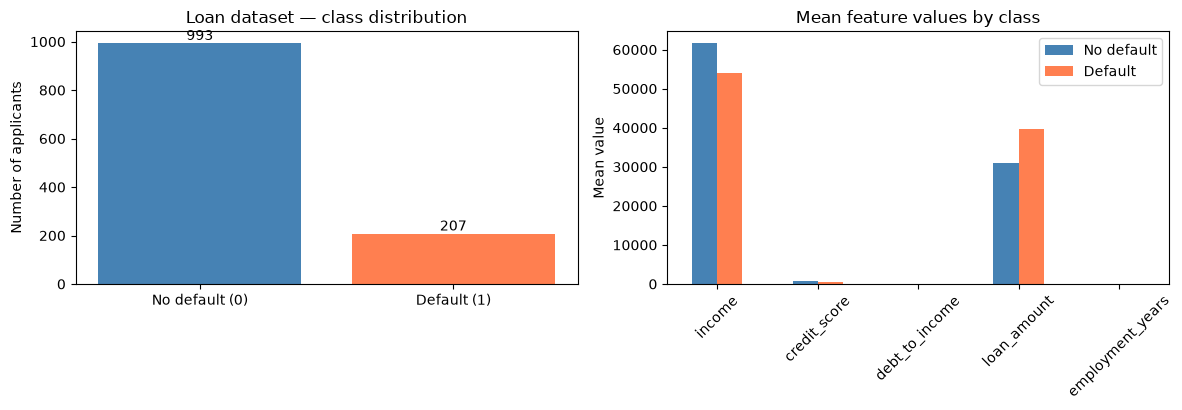

In [37]:
# --- Step 2: explore the data ---
print(df.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Left: class distribution
counts = df["default"].value_counts().sort_index()
bars = axes[0].bar(["No default (0)", "Default (1)"], counts.values,
                   color=["steelblue", "coral"])
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v, str(v), ha="center", va="bottom")
axes[0].set_title("Loan dataset — class distribution")
axes[0].set_ylabel("Number of applicants")

# Right: mean feature values per class
features = ["income", "credit_score", "debt_to_income", "loan_amount", "employment_years"]
means = df.groupby("default")[features].mean().T
means.columns = ["No default", "Default"]
means.plot(kind="bar", ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("Mean feature values by class")
axes[1].set_ylabel("Mean value")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Step 3. The business problem and the cost of errors

A bank must decide, for each loan applicant, whether to **approve** or **reject** the
loan. The model predicts the probability that the applicant **will default** — that is
the "positive" class (1 = will default, 0 = will repay). The two errors are not
symmetric:

| Error | What it means | Business consequence |
|---|---|---|
| **FN** | Model says "no default", but the applicant **defaults** → loan approved | The bank **loses the loaned money** (principal). With loan amounts up to 60,000 and losses possibly much larger, this is the expensive error per incident. |
| **FP** | Model says "will default", but the applicant **would have repaid** → loan rejected | The bank loses the **expected profit** (interest) and the customer may go to a competitor. Also an ethical/customer-experience concern, but the per-incident loss is smaller than a default. |

**Which error is more expensive?** In this case study we will assume a **default costs
about 10× more than a rejected good customer**:

- Cost of FN (an approved loan that defaults) = **10,000** currency units
- Cost of FP (a rejected good customer) = **1,000** currency units

> These numbers are assumptions — in a real project they would come from the bank's
> financial analysis. Changing them changes the whole conclusion, which is exactly the
> point: **the metric and threshold follow the costs, not the other way around.**

### Step 4. Split the data and train the models


In [38]:
# --- Step 4: split and train three simple models ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X = df[features]
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Training set: {len(X_train)} samples | Test set: {len(X_test)} samples")
print(f"Default rate in test set: {y_test.mean():.1%}")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
}

fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    print(f"Trained: {name}")

Training set: 900 samples | Test set: 300 samples
Default rate in test set: 17.3%


Trained: Logistic Regression
Trained: Decision Tree


Trained: Random Forest


In [39]:
# --- Step 5-6: predictions, confusion matrix, and all core metrics at threshold 0.5 ---
rows = []
for name, model in fitted.items():
    y_pred = model.predict(X_test)                    # predictions (labels)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    rows.append({
        "Model": name,
        "Accuracy":   accuracy_score(y_test, y_pred),
        "Precision":  precision_score(y_test, y_pred, zero_division=0),
        "Recall":     recall_score(y_test, y_pred, zero_division=0),
        "Specificity": specificity,
        "F1":         f1_score(y_test, y_pred, zero_division=0),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    })

results = pd.DataFrame(rows).set_index("Model")
results.round(3)

,Accuracy,Precision,Recall,Specificity,F1,TP,FP,FN,TN
Model,,,,,,,,,
Logistic Regression,0.907,0.800,0.615,0.968,0.696,32,8,20,240
Decision Tree,0.860,0.647,0.423,0.952,0.512,22,12,30,236
Random Forest,0.907,0.833,0.577,0.976,0.682,30,6,22,242


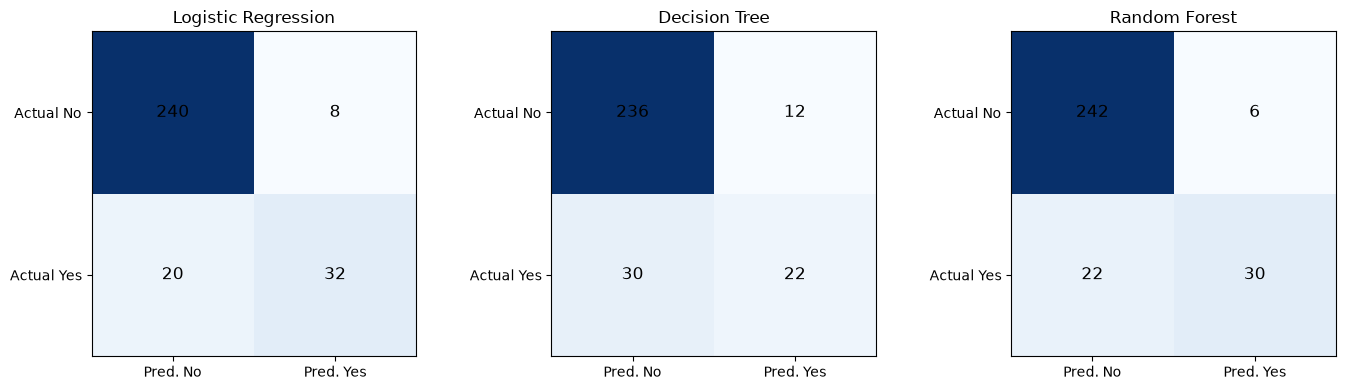

In [40]:
# --- Confusion matrices for all three models ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model) in zip(axes, fitted.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred. No", "Pred. Yes"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual No", "Actual Yes"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)
    ax.set_title(name)
plt.tight_layout()
plt.show()

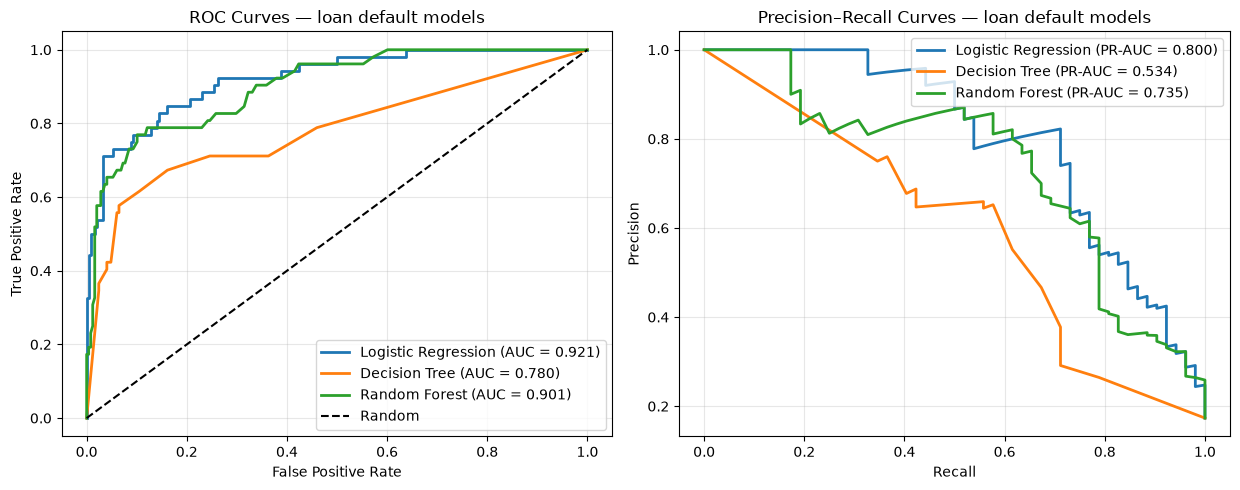

In [41]:
# --- Step 7-8: ROC curves, AUC, PR curves, PR-AUC for all models ---
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))

for name, model in fitted.items():
    probs = model.predict_proba(X_test)[:, 1]          # probabilities of default

    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_val:.3f})")

    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(recall, precision, linewidth=2, label=f"{name} (PR-AUC = {ap:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — loan default models")
axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall Curves — loan default models")
axes[1].legend(loc="upper right"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
# --- Classification report (Logistic Regression as the example) ---
y_pred_lr = fitted["Logistic Regression"].predict(X_test)
print(classification_report(y_test, y_pred_lr, target_names=["No default", "Default"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))

              precision    recall  f1-score   support

  No default       0.92      0.97      0.94       248
     Default       0.80      0.62      0.70        52

    accuracy                           0.91       300
   macro avg       0.86      0.79      0.82       300
weighted avg       0.90      0.91      0.90       300

Confusion matrix:
 [[240   8]
 [ 20  32]]


### Step 9. Threshold analysis — choosing the operating point

At the default 0.5 threshold, all three models look reasonable. But the bank does not have
to use 0.5 — it should choose the threshold that **minimizes total business cost** given
its assumed error costs (FP = 10,000, FN = 1,000). Let's sweep the threshold for each
model and compute the total cost at every point.


In [43]:
# --- Step 10-11: cost-based threshold analysis ---
COST_FP = 1000    # a rejected good customer: lost profit
COST_FN = 10000   # an approved loan that defaults: the bank loses the loaned money

def total_cost(y_true, y_prob, threshold, cost_fp, cost_fn):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp * cost_fp + fn * cost_fn

thresholds = np.arange(0.05, 0.96, 0.05)

rows = []
for name, model in fitted.items():
    probs = model.predict_proba(X_test)[:, 1]
    costs = [total_cost(y_test, probs, t, COST_FP, COST_FN) for t in thresholds]
    best_idx = int(np.argmin(costs))
    rows.append({
        "Model": name,
        "Best threshold": thresholds[best_idx],
        "Min total cost": int(costs[best_idx]),
        "Cost at 0.5": int(total_cost(y_test, probs, 0.5, COST_FP, COST_FN)),
    })

pd.DataFrame(rows).set_index("Model").round(0)

,Best threshold,Min total cost,Cost at 0.5
Model,,,
Logistic Regression,0.0,114000,208000
Decision Tree,0.0,210000,312000
Random Forest,0.0,134000,227000


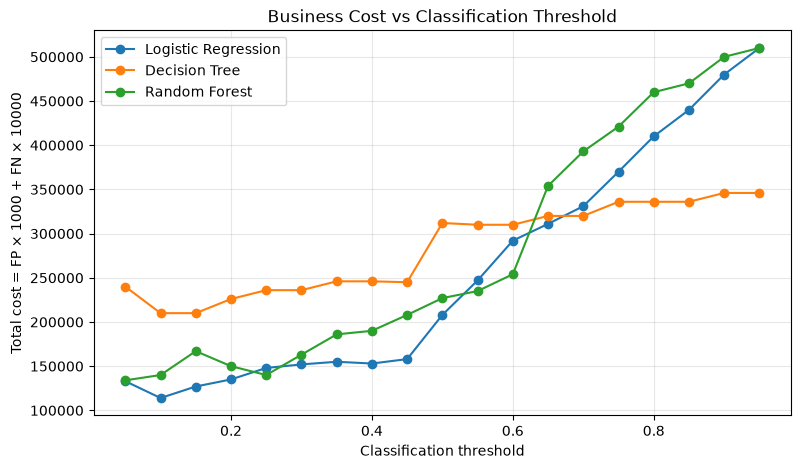

In [44]:
# --- Visualize total cost vs threshold for every model ---
plt.figure(figsize=(9, 5))
for name, model in fitted.items():
    probs = model.predict_proba(X_test)[:, 1]
    costs = [total_cost(y_test, probs, t, COST_FP, COST_FN) for t in thresholds]
    plt.plot(thresholds, costs, "o-", label=name)

plt.xlabel("Classification threshold")
plt.ylabel(f"Total cost = FP × {COST_FP} + FN × {COST_FN}")
plt.title("Business Cost vs Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Step 10b. Interactive threshold explorer — drag the sliders! 🎛️

This is the payoff of everything we just did. **Move the threshold slider** and watch
three things update live:

1. the **confusion matrix** (how many defaults slip through vs good customers rejected),
2. the **total business cost**, and
3. the **cost-optimal threshold** (gray dashed line) — which moves when you change the
   error costs with the two cost sliders.

Try these experiments:

1. Swap the costs: set **Cost FP = 10,000** and **Cost FN = 1,000** (a rejected good
   customer becomes the expensive error). Watch the cost-optimal threshold jump **above**
   0.5 — the bank now approves conservatively.
2. Set **Cost FN = 20,000** and **Cost FP = 0**. The model should now approve almost
   everything — missing a default is ruinous and false alarms are free.
3. Find the threshold that maximizes *accuracy* — then compare its business cost with
   the cost-optimal threshold. Are they the same point? (Almost never!)

> This is the core lesson of the notebook made visible: **the right threshold is the one
> that minimizes business cost — not 0.5, and not the point that maximizes accuracy or
> F1.**

*Technical note:* the sliders need `ipywidgets` (already included in most Jupyter
installations; otherwise `pip install ipywidgets` and restart the kernel). If the sliders
appear but do not respond, re-run this cell with a running kernel. If `ipywidgets` is
missing, the cell prints a clear message instead of failing.


In [45]:
# --- Step 10b: INTERACTIVE threshold explorer (drag the sliders!) ---
# Uses the Logistic Regression model trained in Step 4. If you restart the kernel and
# run only this cell, run Section 21 from Step 1 first so that `fitted` and `y_test` exist.
if "fitted" not in globals() or "y_test" not in globals():
    raise RuntimeError("Run the earlier cells of Section 21 first (Steps 1-4) — this cell needs the loan model.")

# The probability scores of the recommended (Logistic Regression) model
probs = fitted["Logistic Regression"].predict_proba(X_test)[:, 1]
thresholds = np.arange(0.05, 0.96, 0.05)


def total_cost(y_true, y_prob, threshold, cost_fp, cost_fn):
    # Business cost of a threshold given the cost of each error type
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp * cost_fp + fn * cost_fn


try:
    import ipywidgets as widgets
    from IPython.display import display

    def explore(threshold, cost_fp, cost_fn):
        # Redraw the confusion matrix, the cost curve, and the numbers for one threshold
        y_pred = (probs >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        cost = fp * cost_fp + fn * cost_fn

        # Where is the cost-optimal threshold for the CURRENT costs?
        sweep = [total_cost(y_test, probs, t, cost_fp, cost_fn) for t in thresholds]
        best_idx = int(np.argmin(sweep))
        best_t = thresholds[best_idx]

        fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

        # Left: confusion matrix at the current threshold
        cm = np.array([[tn, fp], [fn, tp]])
        axes[0].imshow(cm, cmap="Blues")
        axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Pred. No", "Pred. Yes"])
        axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["Actual No", "Actual Yes"])
        for i in range(2):
            for j in range(2):
                axes[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
        axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
        axes[0].set_title(f"Confusion matrix at threshold {threshold:.2f}")

        # Right: full cost curve + current point + cost-optimal threshold
        axes[1].plot(thresholds, sweep, "o-", color="steelblue", label="Total cost")
        axes[1].axvline(threshold, color="coral", linestyle="--", alpha=0.8)
        axes[1].plot(threshold, cost, "o", color="coral", markersize=9, label="Current point")
        axes[1].axvline(best_t, color="gray", linestyle=":", alpha=0.9)
        axes[1].annotate(f"cost-optimal = {best_t:.2f}", (best_t, sweep[best_idx]),
                         textcoords="offset points", xytext=(8, -12), fontsize=9, color="gray")
        axes[1].set_xlabel("Classification threshold")
        axes[1].set_ylabel(f"Cost = FP×{cost_fp:,} + FN×{cost_fn:,}")
        axes[1].set_title("Total business cost vs threshold")
        axes[1].legend(loc="upper right", fontsize=8)
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Numeric readout
        print(f"threshold = {threshold:.2f}  |  FP = {fp}   FN = {fn}   TP = {tp}   TN = {tn}")
        print(f"Precision = {tp / (tp + fp):.3f}   Recall = {tp / (tp + fn):.3f}")
        print(f"Total cost = {fp:,} × {cost_fp:,} + {fn:,} × {cost_fn:,} = {cost:,.0f} currency units")

    slider_t = widgets.FloatSlider(value=0.10, min=0.0, max=1.0, step=0.01,
                                   description="Threshold:", readout_format=".2f")
    slider_fp = widgets.IntSlider(value=1000, min=0, max=20000, step=500, description="Cost FP:")
    slider_fn = widgets.IntSlider(value=10000, min=0, max=20000, step=500, description="Cost FN:")

    out = widgets.interactive_output(explore,
                                     {"threshold": slider_t, "cost_fp": slider_fp, "cost_fn": slider_fn})
    with out:
        explore(0.10, 1000, 10000)   # embed a static snapshot of the initial view
    display(widgets.VBox([widgets.HBox([slider_t, slider_fp, slider_fn]), out]))
    print("✅ The sliders are live! Drag the threshold (and the costs) and watch everything update.")

except ImportError:
    print("ipywidgets is not installed, so the interactive slider is unavailable.")
    print("Install it with:  pip install ipywidgets   (then restart the kernel and re-run this cell).")
    print("Until then, use the static cost curve above: pick a threshold and read its cost off the curve.")

✅ The sliders are live! Drag the threshold (and the costs) and watch everything update.


In [46]:
# --- Step 12-13: the final recommendation ---
best_model, best_thresh, best_cost = None, None, np.inf
for name, model in fitted.items():
    probs = model.predict_proba(X_test)[:, 1]
    costs = [total_cost(y_test, probs, t, COST_FP, COST_FN) for t in thresholds]
    idx = int(np.argmin(costs))
    if costs[idx] < best_cost:
        best_model, best_thresh, best_cost = name, thresholds[idx], costs[idx]

print(f"Recommended model:    {best_model}")
print(f"Recommended threshold: {best_thresh:.2f}")
print(f"Minimum expected cost: {best_cost:,.0f} currency units (on the test set)")
print()

probs = fitted[best_model].predict_proba(X_test)[:, 1]
y_pred_best = (probs >= best_thresh).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

print(f"Confusion matrix at the recommended threshold ({best_thresh:.2f}):")
print(f"  TP = {tp}  (defaults we caught and rejected)")
print(f"  FN = {fn}  (defaults we approved — each costs {COST_FN:,})")
print(f"  FP = {fp}  (good customers we rejected — each costs {COST_FP:,})")
print(f"  TN = {tn}  (good customers correctly approved)")
print(f"\n  Cost breakdown: {fp} × {COST_FP:,} + {fn} × {COST_FN:,} = {best_cost:,.0f}")

Recommended model:    Logistic Regression
Recommended threshold: 0.10
Minimum expected cost: 114,000 currency units (on the test set)

Confusion matrix at the recommended threshold (0.10):
  TP = 47  (defaults we caught and rejected)
  FN = 5  (defaults we approved — each costs 10,000)
  FP = 64  (good customers we rejected — each costs 1,000)
  TN = 184  (good customers correctly approved)

  Cost breakdown: 64 × 1,000 + 5 × 10,000 = 114,000


### Step 14. Discussion and business consequences

**What did we learn from this workflow?**

1. **Metrics are chosen after the costs, not before.** We defined the cost of each error
   first (FN = approved default = 10,000; FP = rejected good customer = 1,000), and
   *then* picked metrics and a threshold. The chosen threshold (0.10) is well **below**
   the default 0.5 — because an approved default costs 10× more than a rejected good
   customer, the bank approves loans more liberally to avoid missing defaulters. At the
   default 0.5 threshold the cost was about 208,000 — almost double the 114,000 at the
   optimum. **The default threshold is a convention, not a decision.** (The formal
   rule behind this choice is derived in Section 23 — Cost-Sensitive Evaluation.)
2. **Accuracy at 0.5 was not the answer.** The best business threshold is the one that
   minimizes cost, which is a different objective than maximizing accuracy or F1.
3. **The confusion matrix at the recommended threshold is the real deliverable** — it says
   exactly how many defaults slip through (FN) and how many good customers are rejected
   (FP), in business units the bank understands.
4. **Models are compared on the business objective.** Random Forest and Logistic
   Regression came out with different balances; the recommendation is the model +
   threshold pair with the lowest expected cost.
5. **The cost numbers are assumptions.** If the bank decided a rejected good customer
   actually costs 20,000 (e.g., reputational damage), the optimum would move to a
   *higher* threshold with higher precision — fewer good customers rejected, at the cost
   of more approved defaults. **The analysis stays the same; the answer changes.**

**Would this result be good enough for the real world?** That is a question for the bank's
risk committee, informed by this analysis. What we can say confidently: of all the
thresholds and models we tried, this combination minimizes the bank's assumed error cost
on the test data. The final "yes or no" is a business decision built on this technical
foundation — exactly how professional evaluation works.

---

[⬅ Previous](#sec20) · [🏠 Table of Contents](#toc) · [Next ➡](#sec22)

📗 **Back to basics:** see **Section 14: Mini Case Study: Loan Default
Prediction** in `ML_Model_Evaluation_Simple.ipynb` — the same bank story, simplified,
with the cost-of-errors table and threshold sweep.


<a id="sec22"></a>
## 22. Business Decision Case Study

### Two models, two different profiles

Two teams propose models for the same classification problem:

| Metric | Model A | Model B |
|---|---|---|
| Accuracy | 97% | 94% |
| Precision | 95% | 80% |
| Recall | 60% | 90% |

**Which model should we deploy?**

Do not answer yet. The correct answer depends on:

- the business problem,
- the cost of FP,
- the cost of FN,
- risk tolerance,
- operational capacity,
- customer impact.

Model A is "more accurate" and more precise. Model B finds far more positives. Let's
translate both into confusion matrices and then into **money** under two different
business scenarios.


In [47]:
# --- Step 1: translate precision/recall into confusion matrices ---
def implied_cm(precision, recall, n_pos=100, n_neg=900):
    # Approximate confusion matrix (TP, FP, FN, TN) consistent with P and R
    tp = round(recall * n_pos)
    fn = n_pos - tp
    fp = round(tp / precision - tp) if precision > 0 else 0
    tn = n_neg - fp
    return tp, fp, fn, tn

cm_a = implied_cm(0.95, 0.60)     # Model A: high precision, lower recall
cm_b = implied_cm(0.80, 0.90)     # Model B: lower precision, high recall

pd.DataFrame({
    "Model":    ["A", "B"],
    "Precision": [0.95, 0.80],
    "Recall":    [0.60, 0.90],
    "TP":  [cm_a[0], cm_b[0]],
    "FP":  [cm_a[1], cm_b[1]],
    "FN":  [cm_a[2], cm_b[2]],
    "TN":  [cm_a[3], cm_b[3]],
})

print("Model A: TP =", cm_a[0], "| FP =", cm_a[1], "| FN =", cm_a[2], "| TN =", cm_a[3])
print("Model B: TP =", cm_b[0], "| FP =", cm_b[1], "| FN =", cm_b[2], "| TN =", cm_b[3])

Model A: TP = 60 | FP = 3 | FN = 40 | TN = 897
Model B: TP = 90 | FP = 22 | FN = 10 | TN = 878


In [48]:
# --- Step 2: compute the business cost of each model under two scenarios ---
def business_cost(cm, cost_fp, cost_fn):
    tp, fp, fn, tn = cm
    return fp * cost_fp + fn * cost_fn

scenarios = [
    ("A: Fraud detection — missed fraud is expensive (FN)",
     50, 5000),          # cost per FP (blocked customer), cost per FN (missed fraud)
    ("B: Manual investigation — false alarms are expensive (FP)",
     500, 100),          # cost per FP (analyst hours), cost per FN (missed review)
]

print(f"{'Scenario':55s} {'Cost A':>10s} {'Cost B':>10s} {'Cheaper':>8s}")
for name, cost_fp, cost_fn in scenarios:
    ca = business_cost(cm_a, cost_fp, cost_fn)
    cb = business_cost(cm_b, cost_fp, cost_fn)
    winner = "Model B" if cb < ca else "Model A"
    print(f"{name:55s} {ca:>10,.0f} {cb:>10,.0f} {winner:>8s}")

Scenario                                                    Cost A     Cost B  Cheaper
A: Fraud detection — missed fraud is expensive (FN)        200,150     51,100  Model B
B: Manual investigation — false alarms are expensive (FP)      5,500     12,000  Model A


**What did we learn from this output?**

- **Scenario A (fraud detection):** missing fraud (FN) costs 5,000 each, blocking a
  legitimate customer (FP) costs only 50. Model B's extra found frauds save far more than
  its extra false alarms cost → **Model B wins**.
- **Scenario B (manual investigation):** each false alarm costs 500 (analyst hours),
  each missed case only 100. Model A's precision saves the investigation budget → **Model
  A wins**.

**The same two models, the same metrics — different answers, because the costs changed.**

### The lesson

> **"The best model depends on the decision context."**

- A model with **higher accuracy** can be the *worse* business choice.
- A model with **lower accuracy but higher recall** can be the better choice when FN is
  expensive.
- A model with **higher precision** can be the better choice when FP is expensive.
- There is **no universally best model or metric** — only models and metrics that fit
  (or fail to fit) a specific business problem, its costs, and its risk tolerance.

This is why the same evaluation toolkit is used in every serious ML project — and why the
*business conversation* around costs happens before the final model choice, not after.

---


### Interactive: which model wins as the costs change? 🎛️

Model A (high precision) and Model B (high recall) are the two candidates from this
section. The widget below lets you **drag the cost of each error** and watch the winner
flip in real time:

- **Left panel:** the total cost of each model at the current costs — the cheaper model
  is highlighted in green.
- **Right panel:** a **decision map** over the whole cost space. Every point is one
  possible (cost of FP, cost of FN) pair, and the color shows which model wins there.
  The black dashed line is the **tie line** — along it, the two models cost exactly the
  same. The black dot is your current position.

Experiments to try:

1. Start at the **fraud scenario** (cost FP = 50, cost FN = 5,000): Model B wins —
   catching frauds (FN) is what matters.
2. Move to the **manual-investigation scenario** (cost FP = 500, cost FN = 100): watch
   the winner flip to Model A — false alarms are now the expensive error.
3. Slide the dot along the black dashed tie line: the models are tied. Notice the line
   passes through the origin — **only the ratio cost(FN)/cost(FP) matters** (here the
   models tie at cost(FN) ≈ 0.63 × cost(FP)). Doubling both costs changes nothing.

> **The lesson, made visible:** the "best" model is not a property of the models — it is
> a property of the *costs*. Change the costs and the winner changes with them.


In [49]:
# --- Interactive: which model wins as the costs change? ---
# Uses the two candidate models from this section (Model A: high precision,
# Model B: high recall). Recomputes their confusion matrices if run standalone.

def implied_cm(precision, recall, n_pos=100, n_neg=900):
    # Approximate confusion matrix (TP, FP, FN, TN) consistent with P and R
    tp = round(recall * n_pos)
    fn = n_pos - tp
    fp = round(tp / precision - tp) if precision > 0 else 0
    tn = n_neg - fp
    return tp, fp, fn, tn

if "cm_a" not in globals() or "cm_b" not in globals():
    cm_a = implied_cm(0.95, 0.60)     # Model A: high precision, lower recall
    cm_b = implied_cm(0.80, 0.90)     # Model B: lower precision, high recall

fp_a, fn_a = cm_a[1], cm_a[2]         # Model A: 3 FP, 40 FN (per 1,000 applicants)
fp_b, fn_b = cm_b[1], cm_b[2]         # Model B: 22 FP, 10 FN

# Tie condition: fp_a*c_fp + fn_a*c_fn == fp_b*c_fp + fn_b*c_fn
#   =>  cost(FN) = break_even * cost(FP), with break_even = (fp_b - fp_a)/(fn_a - fn_b)
break_even = (fp_b - fp_a) / (fn_a - fn_b)


try:
    import ipywidgets as widgets
    from IPython.display import display

    def compare(cost_fp, cost_fn):
        cost_a = fp_a * cost_fp + fn_a * cost_fn
        cost_b = fp_b * cost_fp + fn_b * cost_fn
        winner = "Model B" if cost_b < cost_a else "Model A"

        fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

        # Left: total cost of each model at the current costs
        bars = axes[0].bar(["Model A\n(high precision)", "Model B\n(high recall)"],
                           [cost_a, cost_b])
        bars[0].set_color("seagreen" if cost_a <= cost_b else "silver")
        bars[1].set_color("seagreen" if cost_b < cost_a else "silver")
        for bar, v in zip(bars, [cost_a, cost_b]):
            axes[0].text(bar.get_x() + bar.get_width() / 2, v, f"{v:,.0f}",
                         ha="center", va="bottom")
        axes[0].set_ylabel("Total cost (currency units)")
        axes[0].set_title(f"Total cost of each model — {winner} wins")
        axes[0].grid(axis="y", alpha=0.3)

        # Right: decision map over the whole (cost FP, cost FN) space
        fp_grid = np.linspace(0, 1000, 200)
        fn_grid = np.linspace(0, 10000, 200)
        FPG, FNG = np.meshgrid(fp_grid, fn_grid)
        winner_map = (fp_a * FPG + fn_a * FNG > fp_b * FPG + fn_b * FNG).astype(int)  # 1 = B wins
        axes[1].imshow(winner_map, origin="lower", aspect="auto",
                       extent=[0, 1000, 0, 10000], cmap="coolwarm", alpha=0.55)
        axes[1].plot(fp_grid, break_even * fp_grid, "k--", linewidth=1.6,
                     label=f"Tie line: cost(FN) = {break_even:.2f} × cost(FP)")
        axes[1].plot(cost_fp, cost_fn, "o", color="black", markersize=10, label="Current costs")
        axes[1].text(180, 8800, "Model B wins\n(FN expensive)", color="darkred", fontsize=10, ha="center")
        axes[1].text(620, 250, "Model A wins\n(FP expensive)", color="darkblue", fontsize=10, ha="center")
        axes[1].set_xlabel("Cost of FP (false alarm)")
        axes[1].set_ylabel("Cost of FN (miss)")
        axes[1].set_title("Which model wins for every (cost FP, cost FN) pair?")
        axes[1].legend(fontsize=8, loc="lower right")

        plt.tight_layout()
        plt.show()

        ratio = cost_fn / cost_fp if cost_fp > 0 else float("inf")
        print(f"Model A cost = {cost_a:,.0f}   |   Model B cost = {cost_b:,.0f}")
        print(f"{winner} is cheaper by {abs(cost_a - cost_b):,.0f} currency units")
        print(f"Current ratio cost(FN)/cost(FP) = {ratio:.2f}   (models tie at {break_even:.2f})")

    slider_fp = widgets.IntSlider(value=50, min=0, max=1000, step=10, description="Cost FP:")
    slider_fn = widgets.IntSlider(value=5000, min=0, max=10000, step=100, description="Cost FN:")

    out = widgets.interactive_output(compare, {"cost_fp": slider_fp, "cost_fn": slider_fn})
    with out:
        compare(50, 5000)   # start at the fraud scenario from this section
    display(widgets.VBox([widgets.HBox([slider_fp, slider_fn]), out]))
    print("✅ Drag the cost sliders and watch the winner flip!")

except ImportError:
    print("ipywidgets is not installed, so the interactive slider is unavailable.")
    print("Install it with:  pip install ipywidgets   (then restart the kernel and re-run this cell).")
    print("Until then, use the scenario table above: Model B wins the fraud scenario, Model A wins the investigation scenario.")

✅ Drag the cost sliders and watch the winner flip!


#### Beginner Perspective

*Never pick a model by accuracy alone. Ask: what does each type of error cost? The model
that minimizes total cost wins — even if it "looks" worse on paper.*

#### Expert Perspective

*Experts estimate a full cost matrix per prediction, sometimes including operational
capacity constraints (an investigation queue that overflows) and customer-impact terms,
then optimize the threshold and model jointly. They also re-estimate costs periodically:
as business conditions change, the "best" model can change with them.*

---

[⬅ Previous](#sec21) · [🏠 Table of Contents](#toc) · [Next ➡](#sec23)

📗 **Back to basics:** see **Section 14: Mini Case Study: Loan Default
Prediction** in `ML_Model_Evaluation_Simple.ipynb` — the business framing (“the
threshold is a decision, not a default”) in one worked example.


<a id="sec23"></a>
## 23. Cost-Sensitive Evaluation: From Cost Matrix to Decision Rule

### Why another section on costs?

We have used costs throughout: the loan case study (Section 21) swept thresholds to
minimize `FP × 1,000 + FN × 10,000`, and the business-decision case study (Section 22)
changed its winner when the costs changed. This section formalizes what we were doing —
**how to turn a cost matrix into the optimal decision rule** — and shows that the loan
case study's chosen threshold of 0.10 was not a judgment call at all: it is the output of
a formula.

### A. The cost matrix

Every outcome of a binary classifier has a price. The usual convention assigns cost 0 to
correct predictions and focuses on the two errors:

|  | Predicted Negative | Predicted Positive |
|---|---|---|
| **Actual Negative** | 0 | **C_FP** |
| **Actual Positive** | **C_FN** | 0 |

- **C_FP** = cost of a false positive (a false alarm)
- **C_FN** = cost of a false negative (a miss)

In the loan case study (Section 21): C_FP = 1,000 (good customer wrongly rejected),
C_FN = 10,000 (loan approved that defaults). In a screening test: C_FP = cost of an
unnecessary follow-up, C_FN = cost of a missed disease.

### B. Expected cost per decision

For any threshold, the expected cost per decision on a dataset is the average:

$$\text{E[cost]} = \frac{C_{FP} \cdot FP + C_{FN} \cdot FN}{n}$$

where n is the number of decisions. This is exactly the quantity the loan case study
minimized — expressed per decision rather than as a total.

### C. The optimal decision rule — the derivation

For a single sample with estimated probability p of being positive:

- If we **predict positive**, we pay C_FP whenever the sample is actually negative:
  expected cost = (1 − p) · C_FP
- If we **predict negative**, we pay C_FN whenever the sample is actually positive:
  expected cost = p · C_FN

The optimal (Bayes) decision predicts positive exactly when its expected cost is lower:

$$(1 - p) \cdot C_{FP} < p \cdot C_{FN}$$

Rearranging:

$$C_{FP} - p \cdot C_{FP} < p \cdot C_{FN} \quad\Longrightarrow\quad C_{FP} < p \cdot (C_{FP} + C_{FN})$$

$$p > \frac{C_{FP}}{C_{FP} + C_{FN}}$$

**The optimal threshold is**

$$\boxed{t^* = \frac{C_{FP}}{C_{FP} + C_{FN}}}$$

This is the single most useful formula in cost-sensitive classification:

| Costs | t* | Business meaning |
|---|---|---|
| C_FP = C_FN | 0.50 | The default 0.5 threshold is optimal **only** when errors cost the same |
| C_FN ≫ C_FP (misses are the disaster) | ≈ 0 | Flag/act on almost everything — avoid misses at any cost |
| C_FP ≫ C_FN (false alarms are the disaster) | ≈ 1 | Act only on near-certainty |


Cost matrix:  C_FP = 200,  C_FN = 2000
Theoretical optimal threshold:  t* = 200 / (200 + 2000) = 0.091
Empirical sweep optimum:            t = 0.090  (expected cost 93.2/decision)
Expected cost at the theoretical t*:      93.0/decision
Default threshold 0.5:              expected cost 111.2/decision
Baseline 'predict negative always':  expected cost 112.2/decision
Baseline 'predict positive always':  expected cost 188.8/decision


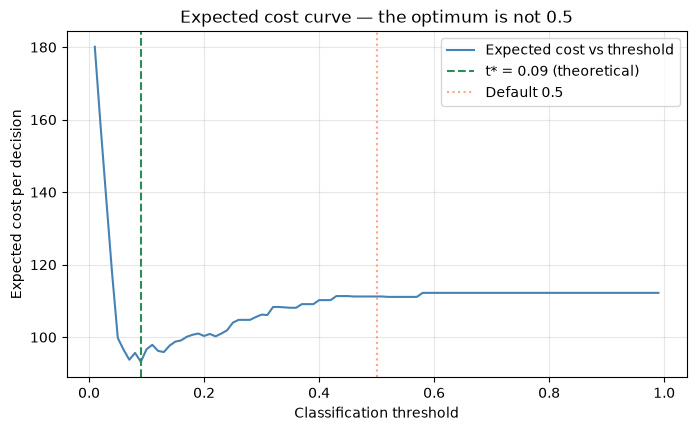

In [50]:
# --- From cost matrix to optimal threshold: the derivation in action ---
# Self-contained synthetic rare-event problem (5% positive class)
X, y = make_classification(n_samples=6000, n_features=6, n_informative=4, n_redundant=0,
                           weights=[0.95, 0.05], random_state=26)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=26, stratify=y)
model = LogisticRegression(max_iter=1000, random_state=26).fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]

C_FP, C_FN = 200, 2000        # a false alarm costs 200; a miss costs 2,000

t_star = C_FP / (C_FP + C_FN)
print(f"Cost matrix:  C_FP = {C_FP},  C_FN = {C_FN}")
print(f"Theoretical optimal threshold:  t* = {C_FP} / ({C_FP} + {C_FN}) = {t_star:.3f}")


def expected_cost(y_true, y_prob, t, c_fp, c_fn):
    # Expected cost per decision at threshold t
    preds = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return (fp * c_fp + fn * c_fn) / len(y_true)


thresholds = np.arange(0.01, 1.00, 0.01)
costs = [expected_cost(y_test, probs, t, C_FP, C_FN) for t in thresholds]
best_t = thresholds[int(np.argmin(costs))]
print(f"Empirical sweep optimum:            t = {best_t:.3f}  (expected cost {min(costs):.1f}/decision)")
print(f"Expected cost at the theoretical t*:      {expected_cost(y_test, probs, t_star, C_FP, C_FN):.1f}/decision")
print(f"Default threshold 0.5:              expected cost {expected_cost(y_test, probs, 0.5, C_FP, C_FN):.1f}/decision")
print(f"Baseline 'predict negative always':  expected cost {expected_cost(y_test, probs, 1.01, C_FP, C_FN):.1f}/decision")
print(f"Baseline 'predict positive always':  expected cost {expected_cost(y_test, probs, -0.01, C_FP, C_FN):.1f}/decision")

plt.figure(figsize=(8, 4.5))
plt.plot(thresholds, costs, color="steelblue", label="Expected cost vs threshold")
plt.axvline(t_star, color="seagreen", linestyle="--", label=f"t* = {t_star:.2f} (theoretical)")
plt.axvline(0.5, color="coral", linestyle=":", alpha=0.7, label="Default 0.5")
plt.xlabel("Classification threshold")
plt.ylabel("Expected cost per decision")
plt.title("Expected cost curve — the optimum is not 0.5")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### D. The loan case study, explained by the formula

The loan case study (Section 21) used C_FP = 1,000 and C_FN = 10,000:

$$t^* = \frac{1000}{1000 + 10000} = \frac{1000}{11000} \approx 0.09$$

Its empirical threshold sweep found the minimum at **0.10** — the nearest grid point to
0.09. The "business judgment" was the formula all along.

### E. Expected business value — does the model pay for itself?

A model is worth deploying only if it reduces expected cost (or raises expected profit)
compared with a sensible baseline:

- **Baseline "do nothing"** (predict negative for everyone): expected cost =
  C_FN × (share of actual positives)
- **Baseline "act on everything"** (predict positive for everyone): expected cost =
  C_FP × (share of actual negatives)
- **The model at t***: expected cost from its confusion matrix

$$\text{Net value of the model} = \text{Cost(baseline)} - \text{Cost(model at } t^*)$$

If the net value is positive, the model pays for itself. If not, the cheaper baseline
beats the model no matter how impressive the AUC is.

### F. Caveats — where the formula needs care

1. **The probabilities must be well calibrated** (Section 13): the rule treats p as a
   true probability. Miscalibrated probabilities make t* wrong, no matter how good the
   ranking.
2. **t* does not depend on prevalence, but the expected cost does.** The same costs give
   the same threshold whether the positive class is 1% or 50%; what changes is how much
   money the model saves.
3. **Costs can differ per group.** If a false alarm costs more for premium customers,
   the optimal threshold differs per segment. One threshold for everyone is a business
   choice, not a mathematical necessity.
4. **Operational constraints can override the formula.** If the fraud team can only
   review 100 alerts a day (Section 22), the pure cost-minimizing threshold may flood the
   queue — capacity becomes part of the cost structure.
5. **The cost matrix generalizes.** Correct predictions can have values too (e.g.,
   profit on a correctly approved loan); the decision rule extends the same way:
   predict positive when its *net expected value* beats the alternative.


In [51]:
# --- The loan case study, explained by the formula ---
# Rebuild the loan model (identical generator and seed to Section 21)
rng = np.random.RandomState(2024)
n = 1200
income = rng.normal(60000, 25000, n).clip(15000, 250000)
credit_score = rng.normal(680, 60, n).clip(400, 850)
debt_to_income = rng.uniform(0.05, 0.75, n)
loan_amount = rng.uniform(5000, 60000, n)
employment_years = rng.uniform(0, 20, n).round(1)

logit = (-3.4 - 2.0 * (credit_score - 680) / 60 + 2.0 * (debt_to_income - 0.4) / 0.2
         + 1.0 * (loan_amount - 32500) / 16000 - 0.75 * (income - 60000) / 24000
         - 0.5 * (employment_years - 10) / 5)
p_default = 1 / (1 + np.exp(-logit))
default = (rng.rand(n) < p_default).astype(int)

df = pd.DataFrame({
    "income": income.round(0), "credit_score": credit_score.round(0),
    "debt_to_income": debt_to_income.round(3), "loan_amount": loan_amount.round(0),
    "employment_years": employment_years, "default": default,
})
features = ["income", "credit_score", "debt_to_income", "loan_amount", "employment_years"]
X, y = df[features], df["default"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
fitted = {"Logistic Regression": LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)}

C_FP_loan, C_FN_loan = 1000, 10000     # rejected good customer vs approved default
t_star_loan = C_FP_loan / (C_FP_loan + C_FN_loan)
print(f"Loan costs: C_FP = {C_FP_loan}, C_FN = {C_FN_loan}")
print(f"Theoretical optimal threshold: t* = {C_FP_loan}/{C_FP_loan + C_FN_loan} = {t_star_loan:.4f}")

probs_loan = fitted["Logistic Regression"].predict_proba(X_test)[:, 1]
costs_loan = [expected_cost(y_test, probs_loan, t, C_FP_loan, C_FN_loan) for t in thresholds]
best_idx = int(np.argmin(costs_loan))
print(f"Empirical sweep optimum (the 0.10 found in Section 21): t = {thresholds[best_idx]:.2f}, "
      f"expected cost {costs_loan[best_idx]:.0f}/decision")
print(f"Expected cost at the default 0.5: "
      f"{expected_cost(y_test, probs_loan, 0.5, C_FP_loan, C_FN_loan):.0f}/decision")

# Net value of the model vs the 'do nothing' baseline (approve every loan)
baseline_cost = y_test.sum() * C_FN_loan / len(y_test)
print(f"\nBaseline 'approve every loan' (no model): {baseline_cost:.0f}/decision")
print(f"Model at t*: {costs_loan[best_idx]:.0f}/decision -> net savings "
      f"{baseline_cost - costs_loan[best_idx]:.0f}/decision") 

Loan costs: C_FP = 1000, C_FN = 10000
Theoretical optimal threshold: t* = 1000/11000 = 0.0909
Empirical sweep optimum (the 0.10 found in Section 21): t = 0.09, expected cost 363/decision
Expected cost at the default 0.5: 693/decision

Baseline 'approve every loan' (no model): 1733/decision
Model at t*: 363/decision -> net savings 1370/decision


### Interactive: set the cost matrix and watch the threshold move 🎛️

Drag the two cost sliders and watch the **optimal threshold** (green line) move to
t* = C_FP/(C_FP + C_FN). The right panel compares the expected cost per decision at t*,
at the default 0.5, and for the "no model" baseline. Notice:

- Setting **C_FN ≫ C_FP** (misses expensive) pushes t* toward 0 — the bank approves
  almost everything to avoid missing a default.
- Setting **C_FP ≫ C_FN** pushes t* toward 1 — the bank acts only on near-certainty.
- The default slider values (1,000 / 10,000) reproduce the loan case study's optimum
  from Section 21.


In [52]:
# --- Interactive: set the cost matrix and watch the optimal threshold move ---
# Uses the loan model rebuilt above (same generator as Section 21).
if "fitted" not in globals() or "y_test" not in globals():
    raise RuntimeError("Run the cells of this section first — the loan model is needed.")

try:
    import ipywidgets as widgets
    from IPython.display import display

    def cost_view(c_fp, c_fn):
        if c_fp + c_fn == 0:
            print("Set at least one cost above 0.")
            return
        t_star = c_fp / (c_fp + c_fn)
        cost_at_star = expected_cost(y_test, probs_loan, t_star, c_fp, c_fn)
        cost_at_05 = expected_cost(y_test, probs_loan, 0.5, c_fp, c_fn)
        baseline = y_test.sum() * c_fn / len(y_test)   # 'do nothing' baseline

        fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

        # Left: expected cost curve with the theoretical optimum marked
        costs_all = [expected_cost(y_test, probs_loan, t, c_fp, c_fn) for t in thresholds]
        axes[0].plot(thresholds, costs_all, color="steelblue", label="Expected cost")
        axes[0].axvline(t_star, color="seagreen", linestyle="--", linewidth=2,
                        label=f"t* = {t_star:.2f}")
        axes[0].axvline(0.5, color="coral", linestyle=":", alpha=0.7, label="Default 0.5")
        axes[0].set_xlabel("Classification threshold")
        axes[0].set_ylabel(f"Expected cost (FP×{c_fp:,} + FN×{c_fn:,})")
        axes[0].set_title("Expected cost per decision vs threshold")
        axes[0].legend(fontsize=8)
        axes[0].grid(alpha=0.3)

        # Right: cost at t* vs default 0.5 vs the no-model baseline
        axes[1].bar(["At t*", "At 0.5", "No model"],
                    [cost_at_star, cost_at_05, baseline],
                    color=["seagreen", "coral", "silver"])
        axes[1].set_ylabel("Expected cost per decision")
        axes[1].set_title("Where to operate?")
        axes[1].grid(axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(f"C_FP = {c_fp:,}, C_FN = {c_fn:,}  ->  t* = {t_star:.3f}")
        print(f"Expected cost at t*: {cost_at_star:,.1f}  |  at 0.5: {cost_at_05:,.1f}  "
              f"|  no model: {baseline:,.1f}  (per decision)")
        print(f"Net savings vs no model: {baseline - cost_at_star:,.1f} per decision")

    slider_fp = widgets.IntSlider(value=1000, min=0, max=5000, step=100, description="Cost FP:")
    slider_fn = widgets.IntSlider(value=10000, min=0, max=20000, step=500, description="Cost FN:")

    out = widgets.interactive_output(cost_view, {"c_fp": slider_fp, "c_fn": slider_fn})
    with out:
        cost_view(1000, 10000)   # reproduce the loan case study's optimum
    display(widgets.VBox([widgets.HBox([slider_fp, slider_fn]), out]))
    print("✅ Drag the cost sliders and watch the optimal threshold move.")

except ImportError:
    print("ipywidgets is not installed, so the interactive slider is unavailable.")
    print("Install it with:  pip install ipywidgets   (then restart the kernel and re-run this cell).")
    print("Until then, the static cost curve above shows the same relationship.")

✅ Drag the cost sliders and watch the optimal threshold move.


**What did we learn from these outputs?**

In the first demo, the theoretical rule t* = 200/(200 + 2000) ≈ 0.09 predicts exactly
where the empirical cost curve bottoms out — while the default 0.5 threshold costs far
more per decision, and both "predict everything negative" and "predict everything
positive" baselines are worse than the model at t*.

In the loan demo, the formula gives t* = 1000/11000 ≈ 0.09 — the neighborhood of the
0.10 threshold the loan case study found empirically, and the reason that threshold
minimized cost. The expected-cost-per-decision view also shows the model's net savings
against the "approve every loan" baseline: the business value of the model, in currency
per decision.

**What would this mean in a real-world application?**

A bank that knows its cost matrix can compute the optimal decision rule in one line —
*before* training anything — and can approve a model for deployment by asking "does it
save more than it costs?" rather than "what is its F1?" The interactive lab above makes
this immediate: move the cost sliders and the formula gives you the new operating point
instantly.

---

#### Beginner Perspective

*Given C_FP (cost of a false alarm) and C_FN (cost of a miss), the best threshold is
t* = C_FP/(C_FP + C_FN) — not 0.5. The threshold is a business formula, not a default.*

#### Expert Perspective

*Experts treat the threshold as the output of expected-cost minimization under a cost
matrix and remember it is only optimal when probabilities are well calibrated (Section
13). They generalize to per-group cost matrices, operational constraints, and full value
matrices with profits on correct decisions — and they evaluate models on net business
value against a no-model baseline, not on isolated metrics.*

---

[⬅ Previous](#sec22) · [🏠 Table of Contents](#toc) · [Next ➡](#sec24)

📗 **Back to basics:** see **Section 14: Mini Case Study: Loan Default
Prediction** in `ML_Model_Evaluation_Simple.ipynb` — the cost table (FN = 10,000 vs
FP = 1,000) and the cost-vs-threshold curve.


<a id="sec24"></a>
## 24. Choosing the Right Metric — A Selection Guide

### The guide

| Scenario | FP means | FN means | More costly error | Emphasized metric | Threshold note |
|---|---|---|---|---|---|
| **Spam detection** | Legitimate email filtered | Spam in the inbox | FP often (missed real mail) | **Precision** | Raise threshold to be more conservative |
| **Disease screening** | Healthy person alarmed | Sick person missed | FN (dangerous) | **Recall / Sensitivity** | Lower threshold to catch more cases |
| **Fraud detection** | Legitimate customer blocked | Fraud not caught | Depends (usually FN at scale; FP if reviews are expensive) | **Recall** or **PR-AUC**; F1 if balanced | Tune by cost of FP vs FN |
| **Intrusion detection** | Normal traffic flagged | Real attack missed | FN (breach) | **Recall** | Lower threshold; accept more alerts |
| **Loan approval** | Loan given, defaults | Good customer rejected | Depends on portfolio; FP (loss of principal) often heavier | **Precision + cost-based threshold** | Raise threshold if defaults are costly |
| **Customer churn** | Offer to loyal customer | Churner gets no offer | FN (lost revenue) | **Recall** | Lower threshold; watch offer budget |
| **Recommendation system** | Bad recommendation shown | Good item never shown | FP (user annoyance) | **Precision** (top-k) | Rank-based evaluation, not threshold |
| **Image classification** | Wrong class label | Wrong class label | Class-dependent | **Per-class metrics**, macro F1 | Per-class thresholds if needed |
| **Imbalanced classification** | False alarm on majority | Missed rare event | Almost always FN | **PR-AUC, Recall, F1** | Never accuracy alone |

### The general decision framework

```
    What are we predicting?
            ↓
      What does FP mean?
            ↓
      What does FN mean?
            ↓
    Which error is more expensive?
            ↓
    Which metric reflects that concern?
            ↓
     What threshold should we use?
            ↓
   Is the model useful in practice?
```

### The three questions, again

For **every** evaluation you will ever do:

1. **Technical:** Which model has the highest metric? *(easiest to answer)*
2. **Data Science:** Which metric matters for this problem? *(harder — requires the next
   question)*
3. **Real-World:** What are the consequences if the model is wrong? *(the question that
   actually decides everything)*

If you can only remember one thing from this notebook, remember that metrics are **not
scores to maximize** — they are **lenses for looking at the consequences of errors**.

---

[⬅ Previous](#sec23) · [🏠 Table of Contents](#toc) · [Next ➡](#sec25)

📗 **Back to basics:** see **Section 15: Cheat Sheet** in
`ML_Model_Evaluation_Simple.ipynb` — the “Best used when” column is the same selection
guide in one table.


<a id="sec25"></a>
## 25. Common Mistakes When Evaluating Machine Learning Models

Every item below is a real, common failure mode in industry. For each one: **why is this
a problem?**

| # | Mistake | Why this is a problem |
|---|---|---|
| 1 | **Using training accuracy as final performance** | Training accuracy measures memorization, not generalization. A model that memorized the data looks perfect during training and fails on new data (Section 1). |
| 2 | **Relying only on accuracy** | Accuracy treats all errors as equal and is trivially inflated on imbalanced data. It hides both the false-alarm burden and the miss rate (Section 4). |
| 3 | **Ignoring class imbalance** | When one class dominates, "high" accuracy is easy to fake. The minority class — often the one that matters — is silently neglected (Section 15). |
| 4 | **Ignoring false positives** | Every FP has a cost: wasted investigations, blocked customers, unnecessary treatment. A model judged only by recall or accuracy can be bankrupting the business with false alarms. |
| 5 | **Ignoring false negatives** | Every FN is a missed case: an undetected fraud, an untreated disease, an unnoticed attack. Models that look "precise" can be missing almost everything that matters. |
| 6 | **Using the test set repeatedly** | The test set exists to be used **once**. If you tune on it, you leak it into your decisions and it stops measuring new data — your reported performance becomes optimistic. |
| 7 | **Data leakage** | Information from the future/test leaks into training (e.g., scaling before splitting, target-derived features). Results look fantastic and collapse in production. Two concrete demonstrations and the fix: [Section 18](#sec18). |
| 8 | **Selecting a model based on one metric only** | One number hides the rest of the story. A model selected by F1 alone may have unacceptable per-class behavior, calibration, or cost performance. |
| 9 | **Ignoring business requirements** | A technically excellent model that does not serve the business objective (or cannot be operated) is not a good model. Evaluation must start from the problem, not from the metric. |
| 10 | **Ignoring the cost of errors** | If FP costs 100× FN, a "balanced" metric like F1 is the wrong objective. Cost structure must drive metric and threshold choice. |
| 11 | **Misinterpreting ROC-AUC** | AUC is a threshold-independent *ranking* summary. It does not pick an operating threshold, and on imbalanced data it can look optimistically high (Section 12). |
| 12 | **Not checking the confusion matrix** | Metrics summarize; the confusion matrix tells the actual story. Without it you cannot see *which* errors happen, in what quantities, for which classes. |
| 13 | **Using inappropriate thresholds** | 0.5 is a default, not a decision. The threshold must be chosen from the costs of FP and FN — the same model can be great at one threshold and terrible at another. |
| 14 | **Assuming higher accuracy always means a better model** | Accuracy is one lens among many. A model with lower accuracy can be far more valuable if it finds the expensive cases (Sections 21–22). |
| 15 | **Assuming F1 is always the best metric** | F1 assumes symmetric error costs. When FP and FN cost different amounts, F1 points you to the wrong model and the wrong threshold. |
| 16 | **Selecting a threshold without considering business consequences** | The threshold decides how many false alarms and misses you *buy*. Choosing it in isolation from operations (queue capacity, customer impact) leads to unmanageable or useless deployments. |

**The common thread:** every one of these mistakes comes from treating evaluation as a
mechanical scoring exercise instead of a decision process anchored in the business
problem.

---

[⬅ Previous](#sec24) · [🏠 Table of Contents](#toc) · [Next ➡](#sec26)

📗 **Back to basics:** only as a formal list here — the nearest basic material is
**Section 15: Cheat Sheet** in `ML_Model_Evaluation_Simple.ipynb`, whose “Best used
when” column encodes the same lessons.


<a id="sec26"></a>
## 26. Beginner vs Expert Summary

| Concept | Beginner Perspective | Expert Perspective |
|---|---|---|
| **Accuracy** | "How often is the model right overall?" | "Only meaningful if classes are balanced and errors cost the same; often replaced by a cost-weighted objective." |
| **Precision** | "Of predicted positives, how many were correct?" | "Must be interpreted at the operating threshold, against prevalence, intervention cost, and FP burden." |
| **Recall** | "Of actual positives, how many did we find?" | "Is the cost of the FN; convert to expected caught cases and missed-case cost for the business." |
| **Specificity** | "How often are actual negatives left alone?" | "Drives operational load (false alarms × cost); equals 1 − FPR, the ROC x-axis." |
| **F1** | "Balances precision and recall." | "Assumes symmetric costs; use Fβ or a real cost function when errors are asymmetric." |
| **ROC-AUC** | "How well the model separates classes." | "A prevalence-invariant ranking summary; does not select a threshold and can mislead on imbalanced data." |
| **PR-AUC** | "Good for rare positives." | "Prevalence-dependent — compare only within datasets; evaluate precision at the operating recall when possible." |
| **Calibration** | "Does 70% mean 70%? Check the reliability diagram." | "Separate calibration from sharpness and discrimination; Brier bundles calibration + sharpness while ECE isolates calibration; check per subgroup." |
| **Classification report** | "Per-class precision/recall/F1 plus averages." | "Read per-class rows for the classes whose errors are expensive; check support; macro-vs-weighted gap reveals imbalance blindness." |
| **Cross-validation** | "K-fold averages performance over splits." | "Choose the CV scheme to match data structure; fit preprocessing inside folds; report mean ± std; score with the business metric." |
| **Threshold** | "Lower = more positives, higher = fewer." | "An operating point chosen to optimize expected cost — for well-calibrated probabilities with costs C_FP and C_FN the optimum is t* = C_FP/(C_FP + C_FN), not a default of 0.5." |
| **The best model** | "The one with the best score." | "The model + threshold pair that best satisfies the objectives and constraints of the real-world problem." |

---

[⬅ Previous](#sec25) · [🏠 Table of Contents](#toc) · [Next ➡](#sec27)

📗 **Back to basics:** the whole `ML_Model_Evaluation_Simple.ipynb` is the
beginner version of this material — start there, then come back here for the expert
perspective.


<a id="sec27"></a>
## 27. Final Cheat Sheet

| Metric | Formula | Measures | Best used when | Main problem | Business question |
|---|---|---|---|---|---|
| **Accuracy** | (TP+TN) / all | Overall correctness | Balanced classes, equal error costs | Misleading on imbalanced data | "How often is the model correct overall?" |
| **Precision** | TP / (TP+FP) | Trust in positive predictions | FP is expensive | Ignores missed positives | "When the model says positive, how often should I trust it?" |
| **Recall / Sensitivity** | TP / (TP+FN) | Fraction of positives found | FN is expensive | Ignores false alarms | "How many actual positives can I find?" |
| **Specificity** | TN / (TN+FP) | Fraction of negatives left alone | False alarms on negatives are costly | Ignores missed positives | "How well can I avoid incorrectly flagging negatives?" |
| **F1** | 2·P·R / (P+R) | Balance of precision & recall | Symmetric error costs | Treats FP and FN as equal | "Can I balance precision and recall?" |
| **ROC-AUC** | Area under ROC | Ranking quality across thresholds | Balanced data, model comparison | Doesn't pick a threshold; optimistic when imbalanced | "How well does the model rank positives above negatives?" |
| **PR-AUC** | Area under PR curve | Usefulness for the rare class | Imbalanced / rare-event problems | Prevalence-dependent; harder to explain | "How useful is the model at finding rare positives?" |
| **Brier score** | mean(p − y)² | Truthfulness of the probabilities themselves | Probabilities drive prices or decisions | Harder to explain to non-experts | "How truthful are the probability numbers?" |
| **MAE** | mean\|y−ŷ\| | Average error (units) | Explainable, symmetric errors | Ignores error-size distribution | "On average, how far off are the predictions?" |
| **MSE** | mean(y−ŷ)² | Squared errors | Large errors are disproportionately bad | Squared units, outlier-sensitive | "How much do large errors hurt?" |
| **RMSE** | √MSE | Error size, big-error penalty | Same as MSE + interpretable units | Outlier-sensitive | "What is a typical error, penalizing big mistakes?" |
| **R²** | 1 − SS_res/SS_tot | Variance explained vs mean baseline | Relative goodness of fit | Can hide large absolute errors | "How much of the variation does the model explain?" |

---

[⬅ Previous](#sec26) · [🏠 Table of Contents](#toc) · [Next ➡](#sec28)

📗 **Back to basics:** see **Section 15: Cheat Sheet** in
`ML_Model_Evaluation_Simple.ipynb` — the essential table with every formula and
business question.


<a id="sec28"></a>
## 28. Practice Exercises

Solve these **before** looking at the solutions at the end of the notebook.
The exercises deliberately ask *why*, not only *what*.

### Beginner

1. A confusion matrix has TN = 85, FP = 15, FN = 25, TP = 75. Identify which cell is
   which and write the matrix in scikit-learn layout.
2. From the same confusion matrix, compute accuracy by hand (show your working).
3. From the same confusion matrix, compute precision by hand and explain in one sentence
   what it means.
4. From the same confusion matrix, compute recall and specificity by hand.
5. A model on a rare-disease dataset (1% positive) predicts "no disease" for everyone.
   Its accuracy is 99%. Is this model useful? Explain with recall.

### Intermediate

6. Two models for the same problem: Model A (accuracy 0.95, precision 0.93, recall 0.45)
   and Model B (accuracy 0.92, precision 0.85, recall 0.88). Which would you choose for
   cancer screening? Justify using error costs.
7. A dataset has 99% negative class. A model scores 98% accuracy and 0.05 recall. Which
   two or three metrics should you report instead of accuracy, and why?
8. Interpret this classification report row: `Class 1  precision 0.62  recall 0.18
   f1-score 0.28  support 231`. What does each number mean, and what should the team do?
9. A logistic regression outputs probabilities. At threshold 0.5 it flags 40 cases; at
   0.7 it flags 12. Without seeing the data, what happened to precision, recall, FP and
   FN, and which way does the business cost move if FN is the expensive error?
10. Compute F1 for a model with precision 0.9 and recall 0.2, and for one with precision
    0.5 and recall 0.6. Which has the higher F1? Does that make it the better model?

### Advanced / Expert

11. A bank must approve loans. A default costs €8,000; a rejected good customer costs
    €500. Design the evaluation: which metrics, which threshold strategy, and how you
    would decide between two models with different precision/recall profiles.
12. On a fraud dataset with 0.5% positives, Model X has ROC-AUC 0.97 and PR-AUC 0.10;
    Model Y has ROC-AUC 0.93 and PR-AUC 0.45. Which do you trust for deployment and why?
13. Using the threshold table below (from a model's test set), find the threshold that
    minimizes cost if FP = €200 and FN = €1,000. Show your cost calculation per row.

    | Threshold | FP | FN |
    |---|---|---|
    | 0.10 | 400 | 5 |
    | 0.30 | 120 | 20 |
    | 0.50 | 40 | 45 |
    | 0.70 | 10 | 80 |
    | 0.90 | 2 | 140 |

14. Two models are compared with a single 80/20 train/test split: Model A scores 0.92,
    Model B 0.90. Explain why this comparison is unreliable, and design a better
    comparison for an imbalanced dataset.
15. You discover your feature engineering used the *full* dataset's statistics (e.g.,
    `StandardScaler().fit(X_all)` before splitting). What is this problem called, why is
    it serious, and what is the correct procedure?

[Jump to Exercise Solutions ⬇](#exercise-solutions)

---

[⬅ Previous](#sec27) · [🏠 Table of Contents](#toc) · [Next ➡](#exercise-solutions)

📗 **Back to basics:** see **Section 16: Practice Exercises** in
`ML_Model_Evaluation_Simple.ipynb` — nine graded exercises with solutions, if the full
set feels like a lot.


<a id="exercise-solutions"></a>
## Exercise Solutions

### Beginner

1. scikit-learn layout (rows = actual, columns = predicted):
   `[[TN=85, FP=15], [FN=25, TP=75]]` — i.e., top-left TN, top-right FP, bottom-left FN,
   bottom-right TP.
2. Accuracy = (TP + TN) / (TP + TN + FP + FN) = (75 + 85) / (75 + 85 + 15 + 25) = 160/200 = **0.80**.
3. Precision = TP / (TP + FP) = 75 / (75 + 15) = 75/90 ≈ **0.833**. Meaning: of everything
   the model predicted positive, about 83% were actually positive.
4. Recall = TP / (TP + FN) = 75 / (75 + 25) = **0.75**. Specificity = TN / (TN + FP) =
   85 / (85 + 15) = **0.85**.
5. **No.** Recall = TP / (TP + FN) = 0 / (0 + 100) = **0** — the model finds zero sick
   patients. The 99% accuracy is just the majority class being easy. In disease screening,
   this model is worse than useless.

### Intermediate

6. For **cancer screening**, FN is the dangerous error (a missed patient). Model B has far
   higher recall (0.88 vs 0.45), so it finds roughly twice as many real cases. Choose
   **Model B** despite its lower accuracy and precision, and tune the threshold to the
   acceptable false-alarm load.
7. Report **recall, precision, and PR-AUC** (plus F1 for balance). Accuracy hides the fact
   that the model finds almost none of the 1% positives; the PR curve shows how useful the
   model is for the rare class directly.
8. `support 231` = there are 231 actual Class-1 samples; precision 0.62 = 62% of
   predictions of Class 1 were correct; recall 0.18 = only 18% of actual Class-1 samples
   were found; F1 = 0.28 balances these. The team should investigate why so many Class-1
   cases are missed (class imbalance, threshold, features, or data quality) before
   trusting the model.
9. Raising the threshold to 0.7 flags fewer cases: precision usually **rises**, recall
   **falls**, FP **falls**, FN **rises**. If FN is the expensive error, total business
   cost likely **rises** — the more permissive threshold (0.5, or lower) was better.
10. F1 for (0.9, 0.2): 2·0.9·0.2/(0.9+0.2) = 0.36/1.1 ≈ **0.327**. F1 for (0.5, 0.6):
    2·0.5·0.6/(0.5+0.6) = 0.6/1.1 ≈ **0.545**. The second has higher F1 — but "better"
    depends on which error costs more. If a missed positive is catastrophic (low recall
    unacceptable), the first model's profile may still be the right choice.

### Advanced / Expert

11. Design: (a) define the costs — FP (default) €8,000, FN (rejected good customer) €500;
    (b) since FP ≈ 16× FN, emphasize **precision** and choose a **high threshold**;
    (c) sweep thresholds to minimize total cost = FP×8000 + FN×500; (d) compare candidate
    models on this cost, plus ROC/PR curves and cross-validation stability; (e) present
    the confusion matrix at the optimal threshold with the cost breakdown to the risk
    committee.
12. Trust **Model Y**. On 0.5% positives, ROC-AUC is inflated and insensitive to the
    false-alarm burden, while PR-AUC directly reflects how useful the model is at finding
    frauds. Y's PR-AUC (0.45) is 4.5× X's (0.10) — X would flood operations with false
    positives despite its impressive ROC-AUC.
13. Cost per row = FP×200 + FN×1000:
    - 0.10: 400·200 + 5·1000 = 80,000 + 5,000 = 85,000
    - 0.30: 120·200 + 20·1000 = 24,000 + 20,000 = 44,000
    - 0.50: 40·200 + 45·1000 = 8,000 + 45,000 = **53,000**
    - 0.70: 10·200 + 80·1000 = 2,000 + 80,000 = 82,000
    - 0.90: 2·200 + 140·1000 = 400 + 140,000 = 140,400
    → Minimum at **0.30** (44,000).
14. A single split can be lucky or unlucky; the 0.02 gap may be noise. Use **stratified
    K-fold cross-validation** (5–10 folds), report mean ± std for a business-relevant
    metric (e.g., F1 or PR-AUC), and check that Model A is better *and* more stable.
15. This is **data leakage**: the scaler saw test-set statistics, so test scores are
    optimistically biased and the model's real-world performance will be worse. Correct
    procedure: split **first**, then fit the scaler **only on the training split** and
    transform the test split with it (inside each CV fold as well).

---

[⬅ Previous](#sec28) · [🏠 Table of Contents](#toc) · [Next ➡](#sec29)

<a id="sec29"></a>
## 29. Final Quiz

### Section A — Multiple choice

1. Which statement about accuracy is **true**?
   a) Accuracy is always the most important metric.
   b) Accuracy treats FP and FN as equally bad.
   c) Accuracy is reliable on imbalanced datasets.
   d) Accuracy ignores TN.

2. Precision is the metric to emphasize when…
   a) missed positives are catastrophic
   b) false positives are expensive
   c) classes are perfectly balanced
   d) you never look at the confusion matrix

3. On an imbalanced dataset, which pair is most informative?
   a) Accuracy and specificity
   b) Precision–Recall curve and PR-AUC
   c) MSE and RMSE
   d) Training and validation accuracy

4. ROC-AUC = 0.5 means…
   a) the model is perfect
   b) the model ranks no better than random
   c) the model is overfitting
   d) the model has 50% accuracy

5. Specificity is defined as…
   a) TP / (TP + FN)
   b) TP / (TP + FP)
   c) TN / (TN + FP)
   d) TN / (TN + FN)

### Section B — True / False

6. True or False: A model can have 99% accuracy and still be useless for fraud detection.
7. True or False: The default classification threshold of 0.5 is always the best threshold
   for deployment.
8. True or False: Higher F1 always means a better business solution.
9. True or False: Using the test set multiple times to tune a model invalidates the test
   set as a measure of generalization.
10. True or False: On imbalanced data, ROC-AUC can look optimistically high while PR-AUC
    reveals poor performance on the minority class.

### Section C — Short conceptual questions

11. In one sentence each: what does FP mean and what does FN mean in **fraud detection**?
12. Give one example where **precision** matters more than recall, and one where
    **recall** matters more than precision.
13. Why can a 99% accurate classifier still be useless? (Use the words: minority class,
    majority class, recall.)
14. What is the difference between macro and weighted averaging in a classification
    report?
15. What is data leakage, and why does it make evaluation results meaningless?

### Section D — Numerical questions

16. TP = 40, TN = 300, FP = 10, FN = 50. Compute accuracy, precision, recall, and
    specificity.
17. A model outputs these probabilities for 5 samples: [0.9, 0.7, 0.55, 0.4, 0.2] with
    true labels [1, 1, 0, 1, 0]. At threshold 0.5, build the confusion matrix. What
    happens to the predictions if the threshold is raised to 0.6?
18. Compute F1 for precision 0.8 and recall 0.6.
19. A house-price model has MAE = 12,000 and RMSE = 25,000. What does each number mean,
    and which would you report to a CEO and why?
20. R² = 0.90 for a pricing model. Does this guarantee the model is good for the
    business? Explain.

### Section E — Scenario / business decision questions

21. Model A has higher accuracy but significantly lower recall than Model B. Which would
    you choose for disease screening, and why?
22. Why might a fraud detection system prefer recall over accuracy?
23. A bank's manual-investigation team can handle only 100 alerts per day. Precision is
    currently 0.30. What happens if they deploy a model with recall 0.95 and precision
    0.10? What trade-off should they make?
24. You must evaluate a model that will decide whether to send expensive retention offers
    to customers predicted to churn. FP costs €20 per offer; FN costs €500 in lost
    revenue. Which metric should drive the threshold, and should the threshold be higher
    or lower than 0.5?
25. A team reports only ROC-AUC (0.96) for a rare-event model. What three questions
    should you ask before approving deployment?

[Jump to Quiz Answers ⬇](#quiz-answers)

---

[⬅ Previous](#exercise-solutions) · [🏠 Table of Contents](#toc) · [Next ➡](#quiz-answers)

📗 **Back to basics:** see **Section 17: Final Quiz** in
`ML_Model_Evaluation_Simple.ipynb` — a 15-question check before you attempt the full
quiz.


<a id="quiz-answers"></a>
## Quiz Answers

### Section A — Multiple choice

1. **b** — accuracy counts FP and FN both as one wrong prediction, giving them equal
   weight.
2. **b** — precision is the direct measure of the false-alarm burden among positive
   predictions.
3. **b** — the PR curve and PR-AUC focus on the rare positive class, where accuracy and
   even ROC-AUC mislead.
4. **b** — AUC 0.5 means a random positive is scored above a random negative only half the
   time: no better than chance.
5. **c** — Specificity = TN / (TN + FP): of all actual negatives, how many are correctly
   left alone.

### Section B — True / False

6. **True.** 99% accuracy is achievable by predicting the majority class and finding zero
   frauds (recall = 0).
7. **False.** 0.5 is a default; the right threshold minimizes the business's cost of FP
   and FN.
8. **False.** F1 assumes symmetric error costs; when one error is much more expensive, the
   highest-F1 model may be the wrong choice.
9. **True.** Each use of the test set leaks information into model selection; eventually
   you are fitting to the test set and it no longer measures generalization.
10. **True.** The huge negative class inflates ROC-AUC; PR-AUC directly reflects the
    false-positive burden on the rare class.

### Section C — Short conceptual questions

11. **FP** = a legitimate transaction is flagged as fraudulent (customer blocked,
    investigation). **FN** = a fraudulent transaction is not flagged (money lost).
12. **Precision example:** spam filtering or expensive manual review — a false alarm costs
    real money or trust. **Recall example:** disease screening or intrusion detection —
    a miss can be catastrophic.
13. If the minority class (e.g., frauds) is 1% of the data, a model predicting the
    majority class for everything gets 99% accuracy but recall = 0: it finds none of the
    cases the business actually cares about.
14. Macro averages each class equally regardless of size; weighted averages each class by
    its support (number of samples). A big gap between them means the small class is
    handled much worse than the large one.
15. Data leakage is when information unavailable at prediction time (e.g., test-set
    statistics or future data) reaches the training process. It makes scores unrealistically
    good, so the evaluation no longer estimates real-world performance. See the two
    demonstrations in [Section 18](#sec18).

### Section D — Numerical questions

16. Accuracy = (40+300)/(40+300+10+50) = 340/400 = **0.85**.
    Precision = 40/(40+10) = **0.80**. Recall = 40/(40+50) = **0.444**.
    Specificity = 300/(300+10) ≈ **0.968**.
17. At 0.5: predictions [1,1,1,0,0], truth [1,1,0,1,0] → TP=2 (samples 1,2), FP=1 (sample
    3), FN=1 (sample 4), TN=1 (sample 5). At 0.6: sample 3 (0.55) becomes 0 and sample 4
    (0.4) stays 0 → TP=2, FP=0, FN=2, TN=1. Higher threshold: fewer FP, more FN.
18. F1 = 2·(0.8·0.6)/(0.8+0.6) = 0.96/1.4 ≈ **0.686**.
19. MAE = 12,000: the average prediction is off by €12,000. RMSE = 25,000: the
    big-error-penalized typical error is €25,000. Report **MAE to the CEO** (interpretable
    in business units); keep RMSE internally to watch large errors.
20. **No.** R² says the model explains 90% of price *variation*, but errors can still be
    large in absolute terms (e.g., MAE 40,000) or concentrated on the most profitable
    customers. Evaluate absolute error, cost of errors, and stability before deployment.

### Section E — Scenario / business decision questions

21. **Model B** for disease screening. FN is the dangerous error: a missed patient. Higher
    recall means fewer sick people sent home, even if accuracy and precision are lower.
    The false alarms (FP) are the acceptable price of catching the disease.
22. Because the cost of a missed fraud (FN) — stolen money — is far larger than the cost
    of a false alert, and because accuracy is dominated by the huge number of legitimate
    transactions and hides the miss rate entirely.
23. With precision 0.10, only 1 in 10 alerts is real fraud; if the team can handle 100
    alerts/day, they only investigate ~10 real cases — the model's high recall is useless
    operationally. They should raise the threshold to improve precision (fewer, more
    accurate alerts) until the daily alert volume fits the team's capacity, accepting
    lower recall.
24. FN (€500) costs 25× FP (€20), so **recall** should drive the threshold, and the
    threshold should be **lower than 0.5** to catch more churners — the offers are cheap
    compared to the lost revenue. (But still bound the total offer budget.)
25. Ask: (1) What is PR-AUC and what does the PR curve look like — is the model actually
    useful for the rare class? (2) At what threshold will we operate, and what are FP/FN
    counts and costs there? (3) Was evaluation done with proper splits/cross-validation
    without leakage, on data matching the deployment population?

---

[⬅ Previous](#sec29) · [🏠 Table of Contents](#toc) · [Next ➡](#framework)

<a id="framework"></a>
## How Should I Evaluate a Machine Learning Model? — The Final Workflow

Use this checklist on every project, in this order.

### Step 1 — Understand the business/problem objective
What decision will this model support? Approve a loan? Block a transaction? Diagnose a
patient? The decision defines everything that follows.

### Step 2 — Understand the data distribution
Class balance? Prevalence? Which class is rare, and which class matters?

### Step 3 — Identify what FP means
What actually happens when the model cries wolf? Who is affected, and what does it cost?

### Step 4 — Identify what FN means
What actually happens when the model misses a positive? What does that cost?

### Step 5 — Determine which error is more costly
Compare cost(FP) and cost(FN) in real units — not "which feels worse" but "which loses
more money / harms more people".

### Step 6 — Select appropriate evaluation metrics
Pick the metrics that reflect the expensive error: precision if FP dominates, recall if FN
dominates, F1 or cost-weighted objectives for balance, PR-AUC for rare events.

### Step 7 — Evaluate multiple metrics rather than relying on one number
One number hides the story. Report the metric set that answers the business questions.

### Step 8 — Examine the confusion matrix
Look at the actual counts: how many FP and FN, for which classes. Metrics summarize; the
matrix shows what really happens.

### Step 9 — Evaluate different classification thresholds
Sweep thresholds; watch precision, recall, FP, FN, and cost at each point.

### Step 10 — Consider ROC-AUC and/or PR-AUC where appropriate
ROC-AUC for overall ranking (balanced data); PR curves/PR-AUC for rare-event problems.

### Step 11 — Consider cross-validation and model stability
Report mean ± std over stratified folds; make sure the choice is not a lucky split.

### Step 12 — Evaluate the model from both technical and business perspectives
Is it technically sound (stable, no leakage, correct metrics) **and** operationally
feasible (fits capacity, acceptable error profile, explainable)?

### Step 13 — Choose an appropriate operating threshold
Optimize the threshold on the business cost function, not on a default of 0.5.

### Step 14 — Only then decide whether the model is suitable for deployment
The decision is the conclusion of the whole chain — never a number taken in isolation.

---

> ### The key message
>
> **Model evaluation is not about finding the model with the highest score.**
> It is about finding the model and decision threshold that best satisfy the objectives
> and constraints of the real-world problem.

---

[⬅ Previous](#quiz-answers) · [🏠 Table of Contents](#toc)

<a id="final-message"></a>
## Congratulations — you have finished the notebook! 🎉

**What you can now do:**

- Compute every core evaluation metric by hand and with scikit-learn
- Read a confusion matrix and a classification report properly
- Explain why accuracy fails on imbalanced data
- Choose between precision, recall, F1, ROC-AUC, and PR-AUC for a given problem
- Evaluate models with cross-validation and spot data leakage
- Turn FP/FN costs into a threshold and a deployment decision

**The three questions to carry into every project:**

1. *Technical:* Which model has the highest metric?
2. *Data Science:* Which metric matters for this problem?
3. *Real-World:* What are the consequences if the model is wrong?

**Suggested next steps**

- Re-run Section 21's case study with *different* values for `COST_FP` and `COST_FN`
  and watch the recommended threshold change — that is the whole lesson made visible.
- Repeat the exercises on your own datasets: for every metric you compute, write down the
  FP and FN counts, the cost of each, and the threshold you would deploy.
- Read scikit-learn's documentation for the functions used here
  (`sklearn.metrics`, `sklearn.model_selection`) to deepen your command of the tools.

Thank you for working through this notebook. Evaluate well, and always ask *what the
errors cost*. 🚀

---

[⬅ Previous](#framework) · [🏠 Table of Contents](#toc)